# LeafletFA Splicing Analysis - Mouse Foundation Model
 
### This notebook analyzes the relationship between splicing factors (LeafletFA) and gene expression factors (scVI, NMF, PCA) for age prediction across different cell types.


## 1. Setup and Imports

In [1]:
# %%
import warnings
warnings.filterwarnings('ignore')

# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import anndata as ad
from pathlib import Path
import os
import sys
from collections import defaultdict

# Statistical libraries
from scipy.stats import spearmanr, pearsonr
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy import stats
import scipy.sparse as sp
from statsmodels.stats.multitest import multipletests

# Machine learning
from sklearn.linear_model import LinearRegression, LogisticRegression, RidgeCV
from sklearn.model_selection import cross_val_score, KFold, StratifiedKFold
from sklearn.metrics import r2_score, accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Specialized libraries
import scanpy as sc
from adjustText import adjust_text
from tqdm import tqdm

# Read in the anndata object
import anndata as ad
from pathlib import Path
import numpy as np
import sys
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os
from scipy.stats import spearmanr, pearsonr
import scipy.sparse as sp
from scipy.cluster.hierarchy import linkage, dendrogram
from matplotlib.ticker import ScalarFormatter
import scanpy as sc
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import cross_val_score, KFold, StratifiedKFold
from sklearn.metrics import r2_score, accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder, StandardScaler
from collections import defaultdict
import warnings
from adjustText import adjust_text
import torch 
warnings.filterwarnings('ignore')

from scipy import stats
from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.utils import resample
import warnings
warnings.filterwarnings('ignore')

# Import LeafletFA differential splicing code
# Define module paths
src_path = "/gpfs/commons/home/kisaev/Leaflet-private/src/"

# Add to sys.path if not already present
if src_path not in sys.path:
    sys.path.append(src_path)

# Import custom modules
# import BetaDirichletFactor.differential_splicing as ds

# Import utility functions - simple direct import
sys.path.append('/gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_Submission2025/Multi_Species_Splicing_Foundation/shared_utils/')
from utils import *
from figure_plotting import *
# Import all functions from /gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/shared_utils/atse_viz.py
from atse_viz import *
import gffutils

#db_file_mouse = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/Mouse_Splicing_Foundation/ATSE_mapper/genomes/lr_GRCm38.db"
#db_mouse = gffutils.FeatureDB(db_file_mouse, keep_order=True)

Added /gpfs/commons/home/kisaev/LeafletFA-utils to sys.path
Visualization imports successful!


## 2. Configuration and Path Setup

In [2]:
# =============================================================================
# CONFIGURATION - EDIT THESE VALUES ONLY
# =============================================================================

# Base directories
BASE_DIR = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/MOUSE_SPLICING_FOUNDATION"
RESULTS_BASE_DIR = "/gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_Submission2025/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results"
GE_ANNDATA_scVI_PATH = "/gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_Submission2025/Mouse_Splicing_Foundation/Figures/ge_adata_for_figures_mouse_foundation.h5ad" #from /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/Figures/FIGURE3/MOUSE_FIGURE_PLOTS.ipynb

# Reference files
AGING_GENES_PATH = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaSenis/27857814"
RBP_FILE_PATH = "/gpfs/commons/groups/knowles_lab/Karin/VanNostrand_2020_supptable1_41586_2020_2077_MOESM3_ESM.xlsx"

ATSE_FILE_PATH = (
    f"{BASE_DIR}/ATSE_mapper/ATSE_files/MOUSE_FOUNDATION_ATSE_FILE_unanno_also_2025-10-01_21-36-40.txt.gz"
)

# Load ATSE file
atse_df = pd.read_csv(ATSE_FILE_PATH, sep="\t")
atse_df["junction_annotation"] = "Novel_SS" 
atse_df.loc[atse_df["perfect_match_5_prime"].notna(), "junction_annotation"] = "5_prime_annotated"
atse_df.loc[atse_df["perfect_match_3_prime"].notna(), "junction_annotation"] = "3_prime_annotated"
atse_df.loc[atse_df["perfect_match_5_prime"].notna() & atse_df["perfect_match_3_prime"].notna(), "junction_annotation"] = "Both_SS_annotated"

# Load splicing data
ge_adata = ad.read_h5ad(GE_ANNDATA_scVI_PATH)
print(f"Done reading the ge_adata with scVI...")

# If ge_adata.var["gene_name"] is not in ge_adata.var_names, then add it
if "gene_name" not in ge_adata.var.columns:
    ge_adata.var["gene_name"] = ge_adata.var_names

# If ge_adata.obs doesn't have cell_id make it from cell_id_clean
if "cell_id" not in ge_adata.obs.columns:
    ge_adata.obs["cell_id"] = ge_adata.obs["cell_id_clean"]

# Load aging gene lists
aging_genes_mouse, aging_genes_human = load_aging_genes(AGING_GENES_PATH)
    
# Load RBP genes
rbps = load_rbp_genes(RBP_FILE_PATH)
rbps["mouse_gene_name"] = rbps["mouse_gene_name"].str.upper()
aging_genes_mouse = [g.upper() for g in aging_genes_mouse]

rbps = rbps["mouse_gene_name"]

Done reading the ge_adata with scVI...
Loaded 330 aging-related genes (mouse)
Loaded 330 aging-related genes (human)
Loaded 356 RNA binding proteins


In [3]:
# Main parameters to change
MODEL_TRAIN_DATE = "2025-11-19"
MODEL_ANALYSIS_DATE = "2025-11-22"
PARAM_ID = 11

# =============================================================================
# AUTO-GENERATED PATHS - DON'T EDIT BELOW THIS LINE
# =============================================================================

# Core result directories
PARAM_RESULTS_DIR = f"{RESULTS_BASE_DIR}/{MODEL_TRAIN_DATE}/{MODEL_ANALYSIS_DATE}/param_id_{PARAM_ID}"
DATA_DIR = f"{PARAM_RESULTS_DIR}/data"

# Model outputs
MODEL_OUTPUTS_DIR = f"{BASE_DIR}/Leaflet/leafletFAmodel/{MODEL_TRAIN_DATE}"
MODEL_PATH = f"{MODEL_OUTPUTS_DIR}/run_{PARAM_ID}/leafletfa_model.pkl.gz"

# Main data files from downstream analysis of model 
PI_VALUES_PATH = f"{DATA_DIR}/PI_values.npy"
DIFF_SPL_PATH = f"{DATA_DIR}/differential_splicing_results.csv"

# Output directory for current analysis
OUTPUT_DIR = f"{PARAM_RESULTS_DIR}/analysis_outputs"

In [4]:
# =============================================================================
# LOAD DATA USING CONFIGURED PATHS
# =============================================================================

print(f"Loading data for param_id {PARAM_ID} from {MODEL_TRAIN_DATE}")
print(f"Data directory: {DATA_DIR}")

# Load main datasets
SPLICE_ADATA_PATH = "/gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_Submission2025/Mouse_Splicing_Foundation/Figures/splice_adata_for_figures_mouse_foundation.h5ad" # saved after processing Figure 2... 
splice_adata = ad.read_h5ad(SPLICE_ADATA_PATH)

assert np.all(ge_adata.obs["cell_id"].values == splice_adata.obs["cell_id"].values), "Cell IDs in ge_adata and splice_adata do not match or are not in the same order."

Loading data for param_id 11 from 2025-11-19
Data directory: /gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_Submission2025/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-11-19/2025-11-22/param_id_11/data


In [5]:
splice_adata

AnnData object with n_obs × n_vars = 142315 × 70102
    obs: 'cell_id_index', 'age', 'donor_id', 'sex', 'subtissue', 'cell_name', 'cell_id', 'cell_clean', 'specific_cell_type', 'medium_cell_type', 'seqtech', 'library_size', 'total_junction_reads', 'annotated_junction_reads', 'unannotated_junction_reads', 'n_detected_annotated_junctions', 'n_detected_unannotated_junctions', 'age_numeric', 'age_group', 'cell_ontology_class', 'broad_cell_type', 'tissue', 'tissue_celltype', 'dataset', 'total_counts', 'GAG_score', 'SP_1', 'SP_2', 'SP_3', 'SP_4', 'SP_5', 'SP_6', 'SP_7', 'SP_8', 'SP_9', 'SP_10', 'SP_11', 'SP_12', 'SP_13', 'SP_14', 'SP_15', 'SP_16', 'SP_17', 'SP_18', 'SP_19', 'SP_20', 'perplexity'
    var: 'index', 'junction_id', 'event_id', 'splice_motif', 'annotation_status', 'gene_name', 'gene_id', 'num_junctions', 'position_off_5_prime', 'position_off_3_prime', 'CountJuncs', 'junction_id_index', 'n_cells_detected', 'confidence', 'aging_gene', 'aging_lifespan_effect', 'aging_longevity_influ

In [6]:
pi = np.load(PI_VALUES_PATH)
leaflet_model = load_model(MODEL_PATH)

Loading model to device: cpu


In [7]:
# Number of factors (K)
K = splice_adata.obsm["X_PHI"].shape[1]

# Get new factor order (indices sorted by decreasing PI)
new_order = np.argsort(-pi)  # minus for descending sort

# Print sorted pi with original indices
print("Sorted pi values with original factor indices:")
for rank, idx in enumerate(new_order):
    print(f"Rank {rank + 1}: Factor {idx} → PI = {pi[idx]:.4f}")

old_to_new_factor_idx = {old: new for new, old in enumerate(new_order)}
print(old_to_new_factor_idx)

# Generate column names: SP_1, SP_2, ..., SP_K
phi_colnames = [f"SP_{i+1}" for i in range(K)]

# Create a DataFrame from X_PHI
phi_df = pd.DataFrame(
    splice_adata.obsm["X_PHI"], 
    index=splice_adata.obs_names,
    columns=phi_colnames
)

Sorted pi values with original factor indices:
Rank 1: Factor 2 → PI = 0.1555
Rank 2: Factor 1 → PI = 0.1364
Rank 3: Factor 14 → PI = 0.0888
Rank 4: Factor 9 → PI = 0.0880
Rank 5: Factor 18 → PI = 0.0671
Rank 6: Factor 17 → PI = 0.0451
Rank 7: Factor 16 → PI = 0.0346
Rank 8: Factor 13 → PI = 0.0346
Rank 9: Factor 0 → PI = 0.0336
Rank 10: Factor 10 → PI = 0.0327
Rank 11: Factor 8 → PI = 0.0306
Rank 12: Factor 11 → PI = 0.0289
Rank 13: Factor 4 → PI = 0.0288
Rank 14: Factor 7 → PI = 0.0287
Rank 15: Factor 3 → PI = 0.0286
Rank 16: Factor 6 → PI = 0.0283
Rank 17: Factor 19 → PI = 0.0280
Rank 18: Factor 5 → PI = 0.0278
Rank 19: Factor 12 → PI = 0.0275
Rank 20: Factor 15 → PI = 0.0264
{2: 0, 1: 1, 14: 2, 9: 3, 18: 4, 17: 5, 16: 6, 13: 7, 0: 8, 10: 9, 8: 10, 11: 11, 4: 12, 7: 13, 3: 14, 6: 15, 19: 16, 5: 17, 12: 18, 15: 19}


In [8]:
print(f"Reading from {DIFF_SPL_PATH}")
diff_spl = pd.read_csv(DIFF_SPL_PATH)
# Step 2: Rename and map
diff_spl = diff_spl.rename(columns={"factor_idx": "old_factor_idx"})
diff_spl["factor_idx"] = diff_spl["old_factor_idx"].map(old_to_new_factor_idx)

Reading from /gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_Submission2025/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-11-19/2025-11-22/param_id_11/data/differential_splicing_results.csv


## 5. Data Processing Functions

In [9]:
print(f"Original number of tissue-celltypes: {len(splice_adata.obs['tissue_celltype'].unique())}")

Original number of tissue-celltypes: 159


In [10]:
# filter to cells with age > 2
# splice_adata = splice_adata[splice_adata.obs["age_numeric"] > 2].copy()
counts = splice_adata.obs.groupby(["tissue_celltype", "age_group"]).size().unstack(fill_value=0)
eligible_ct = counts.index[(counts["young"] >= 50) & (counts["old"] >= 50)]
eligible_ct

CategoricalIndex(['Aorta_Fibroblast', 'Aorta_VascEndo', 'BAT_B_Cell',
                  'BAT_Endothelial', 'BAT_MSC', 'BAT_Myeloid', 'BAT_T_Cell',
                  'Bladder_Urothelial', 'Brain_Astrocyte', 'Brain_Endothelial',
                  'Brain_GliaProg', 'Brain_In-General', 'Brain_Microglia',
                  'Brain_Neuron', 'Brain_Oligo', 'Brain_Pericyte',
                  'Diaphragm_Endothelial', 'Diaphragm_MSC',
                  'Diaphragm_Satellite', 'GAT_Endothelial', 'GAT_MSC',
                  'GAT_Myeloid', 'Heart_Endothelial', 'Heart_Fibroblast',
                  'Heart_Muscle', 'Heart_Myeloid', 'Heart_VascEndo',
                  'Kidney_RenalEpi', 'Kidney_VascEndo', 'LI_EpiProg',
                  'LI_IntEpi', 'LI_Secretory', 'Liver_Hepatocyte',
                  'Liver_SinEndo', 'Lung_APC', 'Lung_B_Cell',
                  'Lung_Fibroblast', 'Lung_Myeloid', 'Lung_Pneumocyte',
                  'Lung_SmoothMus', 'Lung_Vascular', 'MAT_APC', 'MAT_B_Cell',
        

In [11]:
# Apply filter
splice_adata = splice_adata[splice_adata.obs["tissue_celltype"].isin(eligible_ct)].copy()
print(f"Number of cell types after filtering: {len(splice_adata.obs['tissue_celltype'].unique())}")
print(f"Number of cells after filtering: {splice_adata.n_obs}")

ge_adata_full = ge_adata.copy()
ge_adata = ge_adata[splice_adata.obs_names].copy()
assert np.all(ge_adata.obs_names == splice_adata.obs_names)

Number of cell types after filtering: 76
Number of cells after filtering: 80557


## 7. Exploratory Data Analysis

In [12]:
def create_age_celltype_heatmap(splice_adata, output_dir):
    """Create heatmap of cell counts by age and cell type."""
    print("Creating age vs cell type heatmap...")
    
    heatmap_data = pd.crosstab(
        splice_adata.obs['tissue_celltype'], 
        splice_adata.obs['age_numeric']
    ).fillna(0)
    
    plt.figure(figsize=(12, 8))
    sns.heatmap(heatmap_data, 
                annot=True, 
                fmt='g', 
                cmap='Blues',
                cbar_kws={'label': 'Cell Count'})
    plt.title('Cell Counts by Age and Tissue Cell Type')
    plt.xlabel('Age (months)')
    plt.ylabel('Tissue Cell Type')
    plt.xticks(rotation=45)
    plt.tight_layout()
    
    plt.savefig(f"{output_dir}/age_vs_celltype_heatmap.pdf", bbox_inches='tight')
    plt.show()

def create_factor_boxplots(splice_adata, ge_adata, output_dir):
    """Create boxplots for different factor types."""
    features = {
        'Splicing Factors': splice_adata.obsm["X_PHI"],
        'scVI Factors': ge_adata.obsm["X_scVI_linear"]
    }
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    axes = axes.flatten()
    
    for i, (name, data) in enumerate(features.items()):
        sns.boxplot(data=data, ax=axes[i])
        axes[i].set_title(f'Distribution of {name}')
        axes[i].set_xlabel('Factor')
        axes[i].set_ylabel('Value')
    
    plt.tight_layout()
    plt.savefig(f"{output_dir}/factor_distributions.pdf", bbox_inches='tight')
    plt.show()

In [13]:
output_dir="/gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_Submission2025/Mouse_Splicing_Foundation/Figures/FIGURE4/figures"

Creating age vs cell type heatmap...


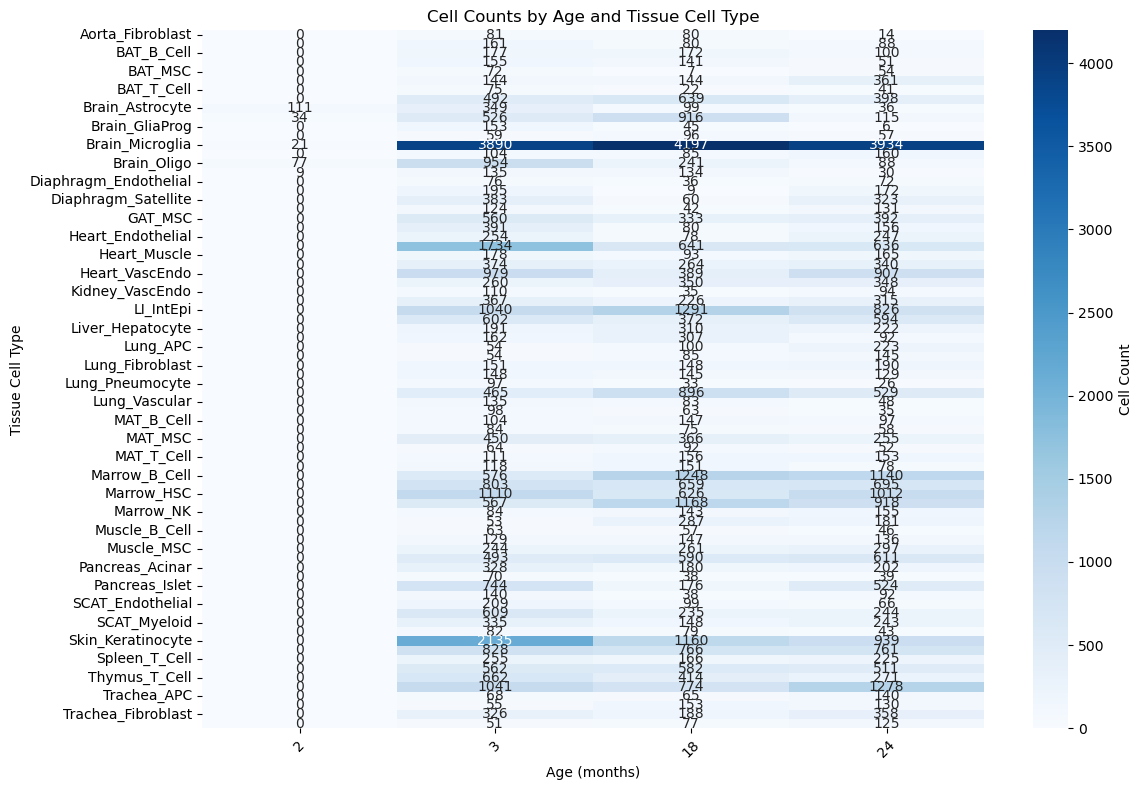

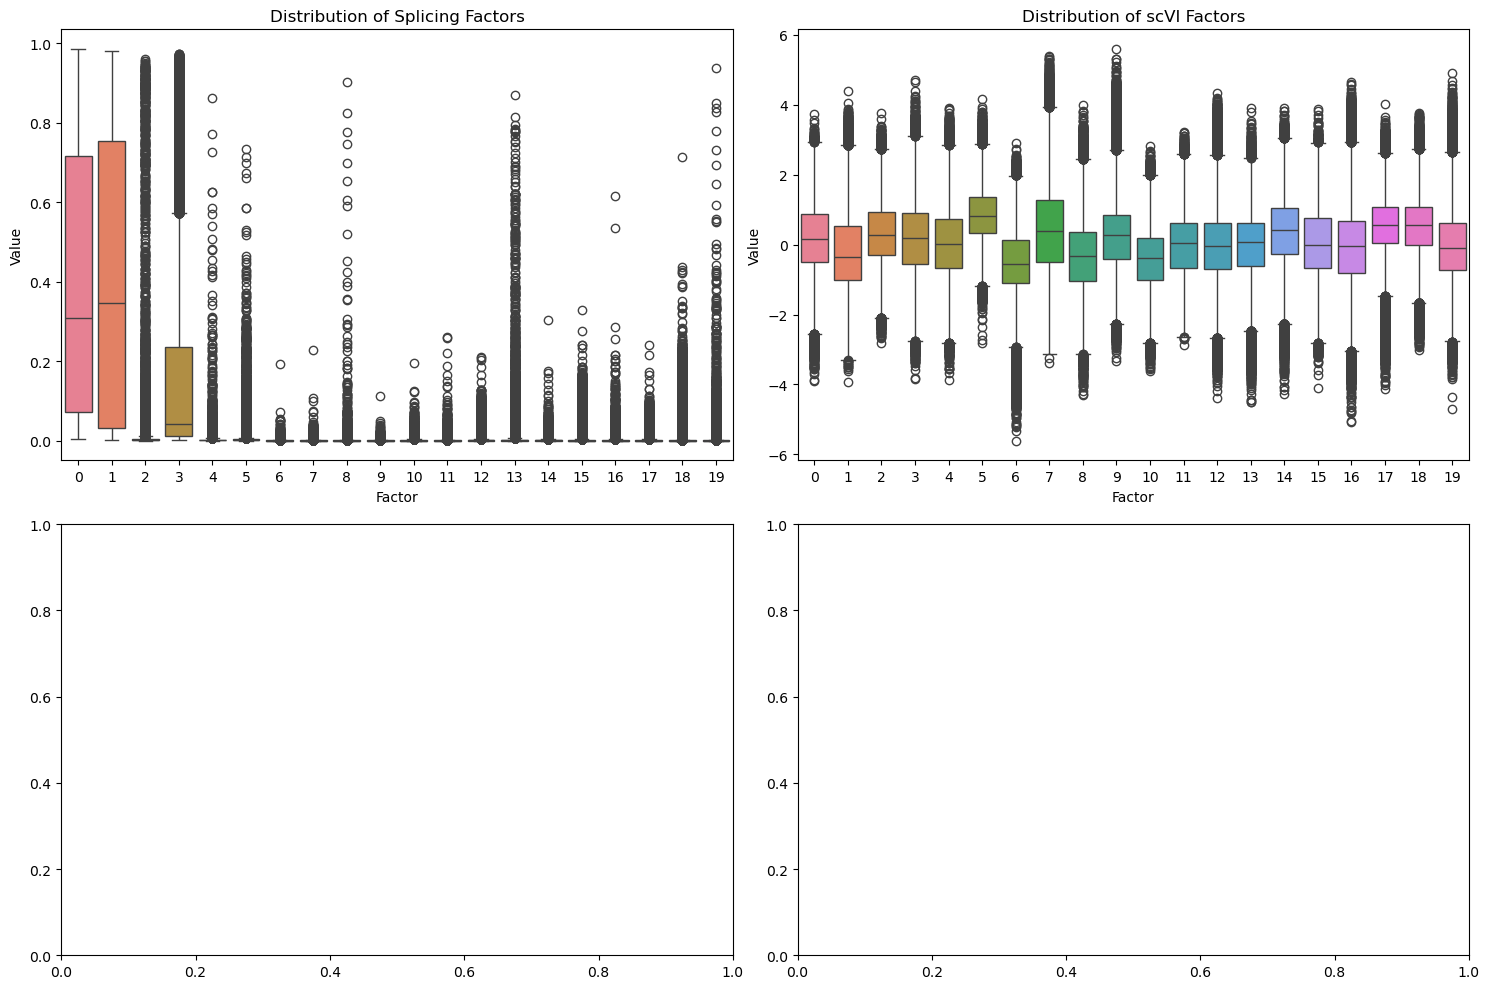

In [14]:
# Run EDA
create_age_celltype_heatmap(splice_adata, output_dir)
create_factor_boxplots(splice_adata, ge_adata, output_dir)

## 9. Ridge Regression Analysis

In [15]:
splice_adata.obs["age_numeric"].value_counts()

age_numeric
3     30262
18    25078
24    24965
2       252
Name: count, dtype: int64

In [16]:
def run_tissue_ridge_analysis(splice_adata, ge_adata, covariate="tissue_celltype", 
                             alphas=np.logspace(-2, 3, 20)):
    """
    Run ridge regression analysis by tissue/cell type.
    """
    print(f"Running ridge regression analysis by {covariate}...")
    
    # Extract features
    assert all(splice_adata.obs_names == ge_adata.obs_names)
    
    dirichlet_data = splice_adata.obsm["X_PHI"]
    scvi_data = ge_adata.obsm["X_scVI_linear"]
    age = splice_adata.obs['age_numeric'].values
    
    results = {}
    feature_importance_data = []
    
    n_splice_factors = dirichlet_data.shape[1]
    n_scvi_factors = scvi_data.shape[1]
    
    splice_factor_names = [f"SP_{i+1}" for i in range(n_splice_factors)]
    scvi_factor_names = [f"Z_{i+1}" for i in range(n_scvi_factors)]
    
    for tissue in tqdm(splice_adata.obs[covariate].unique()):
        mask = (splice_adata.obs[covariate] == tissue).values
        if mask.sum() < 100 or len(np.unique(age[mask])) == 1:
            continue
            
        # Get tissue-specific data
        X_sp = StandardScaler().fit_transform(dirichlet_data[mask])
        X_sc = StandardScaler().fit_transform(scvi_data[mask])
        X_comb = np.hstack([X_sp, X_sc])
        y = age[mask]
        
        # Fit models
        ridge_sp = RidgeCV(alphas=alphas, cv=5).fit(X_sp, y)
        ridge_sc = RidgeCV(alphas=alphas, cv=5).fit(X_sc, y)
        ridge_comb = RidgeCV(alphas=alphas, cv=5).fit(X_comb, y)
        
        # Get R² scores
        r2_sp = ridge_sp.score(X_sp, y)
        r2_sc = ridge_sc.score(X_sc, y)
        r2_comb = ridge_comb.score(X_comb, y)
        
        # Statistical tests
        n = len(y)
        rss_sp = np.sum((y - ridge_sp.predict(X_sp))**2)
        rss_sc = np.sum((y - ridge_sc.predict(X_sc))**2)
        rss_comb = np.sum((y - ridge_comb.predict(X_comb))**2)
        
        # F-tests
        f_vs_sp = ((rss_sp - rss_comb) / n_scvi_factors) / (rss_comb / (n - n_splice_factors - n_scvi_factors - 1))
        p_vs_sp = 1 - stats.f.cdf(f_vs_sp, n_scvi_factors, n - n_splice_factors - n_scvi_factors - 1)
        
        f_vs_sc = ((rss_sc - rss_comb) / n_splice_factors) / (rss_comb / (n - n_splice_factors - n_scvi_factors - 1))
        p_vs_sc = 1 - stats.f.cdf(f_vs_sc, n_splice_factors, n - n_splice_factors - n_scvi_factors - 1)
        
        results[tissue] = {
            'n_cells': mask.sum(),
            'splice_r2': r2_sp,
            'scvi_r2': r2_sc,
            'combined_r2': r2_comb,
            'p_combined_vs_splice': p_vs_sp,
            'p_combined_vs_scvi': p_vs_sc
        }
        
        # Feature importance
        combined_coefs = ridge_comb.coef_
        splice_coefs = combined_coefs[:n_splice_factors]
        scvi_coefs = combined_coefs[n_splice_factors:]
        
        for i, coef in enumerate(splice_coefs):
            feature_importance_data.append({
                'cell_type': tissue,
                'factor_type': 'Splicing',
                'factor_name': splice_factor_names[i],
                'coefficient': coef,
                'abs_coefficient': abs(coef),
                'combined_r2': r2_comb,
                'p_vs_scvi': p_vs_sc
            })
        
        for i, coef in enumerate(scvi_coefs):
            feature_importance_data.append({
                'cell_type': tissue,
                'factor_type': 'Gene_Expression',
                'factor_name': scvi_factor_names[i],
                'coefficient': coef,
                'abs_coefficient': abs(coef),
                'combined_r2': r2_comb,
                'p_vs_scvi': p_vs_sc
            })
    
    return results, pd.DataFrame(feature_importance_data)

def bootstrap_ridge_coefficients(X, y, alphas=np.logspace(-2, 3, 20), n_bootstrap=100):
    """
    Bootstrap Ridge regression to get coefficient confidence intervals.
    """
    n_features = X.shape[1]
    bootstrap_coefs = []
    
    # Fit original model to get best alpha
    ridge = RidgeCV(alphas=alphas, cv=5).fit(X, y)
    best_alpha = ridge.alpha_
    
    # Bootstrap sampling
    for i in range(n_bootstrap):
        # Resample with replacement
        X_boot, y_boot = resample(X, y, random_state=i)
        
        # Fit ridge with best alpha
        ridge_boot = RidgeCV(alphas=[best_alpha], cv=3).fit(X_boot, y_boot)
        bootstrap_coefs.append(ridge_boot.coef_)
    
    bootstrap_coefs = np.array(bootstrap_coefs)
    
    # Calculate confidence intervals (2.5% and 97.5% percentiles)
    ci_lower = np.percentile(bootstrap_coefs, 2.5, axis=0)
    ci_upper = np.percentile(bootstrap_coefs, 97.5, axis=0)
    
    return ridge.coef_, ci_lower, ci_upper, ridge.score(X, y)


def run_tissue_ridge_analysis_with_ci(splice_adata, ge_adata, covariate="tissue_celltype",
                                     alphas=np.logspace(-2, 3, 20), n_bootstrap=50):
    """
    Enhanced ridge regression analysis with confidence intervals.
    """
    print(f"Running ridge regression analysis with CI by {covariate}...")
    
    # Extract features
    assert all(splice_adata.obs_names == ge_adata.obs_names)
    
    dirichlet_data = splice_adata.obsm["X_PHI"]
    scvi_data = ge_adata.obsm["X_scVI_linear"]
    age = splice_adata.obs['age_numeric'].values
    
    results = {}
    feature_importance_data = []
    
    n_splice_factors = dirichlet_data.shape[1]
    n_scvi_factors = scvi_data.shape[1]
    
    splice_factor_names = [f"SP_{i+1}" for i in range(n_splice_factors)]
    scvi_factor_names = [f"Z_{i+1}" for i in range(n_scvi_factors)]
    
    for tissue in splice_adata.obs[covariate].unique():
        mask = (splice_adata.obs[covariate] == tissue).values
        if mask.sum() < 100 or len(np.unique(age[mask])) == 1:
            continue
        
        print(f"  Processing {tissue} ({mask.sum()} cells)...")
        
        # Get tissue-specific data
        X_sp = StandardScaler().fit_transform(dirichlet_data[mask])
        X_sc = StandardScaler().fit_transform(scvi_data[mask])
        X_comb = np.hstack([X_sp, X_sc])
        y = age[mask]
        
        # Fit models with confidence intervals
        sp_coef, sp_ci_low, sp_ci_high, r2_sp = bootstrap_ridge_coefficients(X_sp, y, alphas, n_bootstrap)
        sc_coef, sc_ci_low, sc_ci_high, r2_sc = bootstrap_ridge_coefficients(X_sc, y, alphas, n_bootstrap)
        comb_coef, comb_ci_low, comb_ci_high, r2_comb = bootstrap_ridge_coefficients(X_comb, y, alphas, n_bootstrap)
        
        # Statistical tests (same as before)
        ridge_sp = RidgeCV(alphas=alphas, cv=5).fit(X_sp, y)
        ridge_sc = RidgeCV(alphas=alphas, cv=5).fit(X_sc, y)
        ridge_comb = RidgeCV(alphas=alphas, cv=5).fit(X_comb, y)
        
        n = len(y)
        rss_sp = np.sum((y - ridge_sp.predict(X_sp))**2)
        rss_sc = np.sum((y - ridge_sc.predict(X_sc))**2)
        rss_comb = np.sum((y - ridge_comb.predict(X_comb))**2)
        
        f_vs_sp = ((rss_sp - rss_comb) / n_scvi_factors) / (rss_comb / (n - n_splice_factors - n_scvi_factors - 1))
        p_vs_sp = 1 - stats.f.cdf(f_vs_sp, n_scvi_factors, n - n_splice_factors - n_scvi_factors - 1)
        
        f_vs_sc = ((rss_sc - rss_comb) / n_splice_factors) / (rss_comb / (n - n_splice_factors - n_scvi_factors - 1))
        p_vs_sc = 1 - stats.f.cdf(f_vs_sc, n_splice_factors, n - n_splice_factors - n_scvi_factors - 1)
        
        results[tissue] = {
            'n_cells': mask.sum(),
            'splice_r2': r2_sp,
            'scvi_r2': r2_sc,
            'combined_r2': r2_comb,
            'p_combined_vs_splice': p_vs_sp,
            'p_combined_vs_scvi': p_vs_sc
        }
        
        # Store coefficients with confidence intervals
        # Combined model coefficients
        splice_coefs_comb = comb_coef[:n_splice_factors]
        scvi_coefs_comb = comb_coef[n_splice_factors:]
        splice_ci_low_comb = comb_ci_low[:n_splice_factors]
        splice_ci_high_comb = comb_ci_high[:n_splice_factors]
        scvi_ci_low_comb = comb_ci_low[n_splice_factors:]
        scvi_ci_high_comb = comb_ci_high[n_splice_factors:]
        
        for i, (coef, ci_low, ci_high) in enumerate(zip(splice_coefs_comb, splice_ci_low_comb, splice_ci_high_comb)):
            feature_importance_data.append({
                'cell_type': tissue,
                'factor_type': 'Splicing',
                'factor_name': splice_factor_names[i],
                'coefficient': coef,
                'ci_lower': ci_low,
                'ci_upper': ci_high,
                'abs_coefficient': abs(coef),
                'combined_r2': r2_comb,
                'p_vs_scvi': p_vs_sc,
                'significant': ci_low * ci_high > 0  # CI doesn't cross zero
            })
        
        for i, (coef, ci_low, ci_high) in enumerate(zip(scvi_coefs_comb, scvi_ci_low_comb, scvi_ci_high_comb)):
            feature_importance_data.append({
                'cell_type': tissue,
                'factor_type': 'Gene_Expression',
                'factor_name': scvi_factor_names[i],
                'coefficient': coef,
                'ci_lower': ci_low,
                'ci_upper': ci_high,
                'abs_coefficient': abs(coef),
                'combined_r2': r2_comb,
                'p_vs_scvi': p_vs_sc,
                'significant': ci_low * ci_high > 0
            })
    
    return results, pd.DataFrame(feature_importance_data)

def run_global_ridge_analysis(splice_adata, ge_adata, alphas=np.logspace(-2, 3, 20), n_bootstrap=50):
    """
    Run ridge regression analysis on the entire dataset combined.
    """
    print("Running global ridge regression analysis...")
    
    # 1. Feature Extraction & Alignment
    assert all(splice_adata.obs_names == ge_adata.obs_names), "Cell names do not match!"
    
    dirichlet_data = splice_adata.obsm["X_PHI"]
    scvi_data = ge_adata.obsm["X_scVI_linear"]
    y = splice_adata.obs['age_numeric'].values
    
    n_splice_factors = dirichlet_data.shape[1]
    n_scvi_factors = scvi_data.shape[1]
    n_cells = len(y)
    
    # 2. Preprocessing
    X_sp = StandardScaler().fit_transform(dirichlet_data)
    X_sc = StandardScaler().fit_transform(scvi_data)
    X_comb = np.hstack([X_sp, X_sc])
    
    # 3. Model Fitting with Bootstrap (Confidence Intervals)
    print("  Fitting models and calculating bootstrap CIs...")
    sp_coef, sp_low, sp_high, r2_sp = bootstrap_ridge_coefficients(X_sp, y, alphas, n_bootstrap)
    sc_coef, sc_low, sc_high, r2_sc = bootstrap_ridge_coefficients(X_sc, y, alphas, n_bootstrap)
    comb_coef, comb_low, comb_high, r2_comb = bootstrap_ridge_coefficients(X_comb, y, alphas, n_bootstrap)
    
    # 4. Nested Model F-Tests
    # Calculate Residual Sum of Squares (RSS)
    rss_sp = np.sum((y - (X_sp @ sp_coef))**2) # Using bootstrap-fitted coefs for consistency
    rss_sc = np.sum((y - (X_sc @ sc_coef))**2)
    rss_comb = np.sum((y - (X_comb @ comb_coef))**2)
    
    # F-test: Does adding gene expression help splicing?
    f_vs_sp = ((rss_sp - rss_comb) / n_scvi_factors) / (rss_comb / (n_cells - n_splice_factors - n_scvi_factors - 1))
    p_vs_sp = 1 - stats.f.cdf(f_vs_sp, n_scvi_factors, n_cells - n_splice_factors - n_scvi_factors - 1)
    
    # F-test: Does adding splicing help gene expression?
    f_vs_sc = ((rss_sc - rss_comb) / n_splice_factors) / (rss_comb / (n_cells - n_splice_factors - n_scvi_factors - 1))
    p_vs_sc = 1 - stats.f.cdf(f_vs_sc, n_splice_factors, n_cells - n_splice_factors - n_scvi_factors - 1)
    
    # 5. Compile Results Table
    summary_stats = {
        'Global': {
            'n_cells': n_cells,
            'splice_r2': r2_sp,
            'scvi_r2': r2_sc,
            'combined_r2': r2_comb,
            'p_combined_vs_splice': p_vs_sp,
            'p_combined_vs_scvi': p_vs_sc
        }
    }
    
    # 6. Compile Feature Importance DataFrame
    feature_importance_data = []
    names = [f"SP_{i+1}" for i in range(n_splice_factors)] + [f"Z_{i+1}" for i in range(n_scvi_factors)]
    types = ['Splicing'] * n_splice_factors + ['Gene_Expression'] * n_scvi_factors
    
    for i in range(len(names)):
        feature_importance_data.append({
            'cell_type': 'Global',
            'factor_type': types[i],
            'factor_name': names[i],
            'coefficient': comb_coef[i],
            'ci_lower': comb_low[i],
            'ci_upper': comb_high[i],
            'abs_coefficient': abs(comb_coef[i]),
            'significant': comb_low[i] * comb_high[i] > 0
        })
        
    return summary_stats, pd.DataFrame(feature_importance_data)

In [17]:
assert all(splice_adata.obs_names == ge_adata.obs_names)
ge_adata.obs["age_numeric"] = splice_adata.obs["age_numeric"]

In [18]:
# remove 2months old cells from splice_adata.obs["age_numeric"]
# splicing_aging = splice_adata[splice_adata.obs["age_numeric"] != 2].copy()
# ge_adata_aging = ge_adata[ge_adata.obs["age_numeric"] != 2].copy()
splicing_aging = splice_adata.copy()
ge_adata_aging = ge_adata.copy()
assert all(splicing_aging.obs_names == ge_adata_aging.obs_names)

In [19]:
# Run global ridge first 
global_results, global_feature_importance_df = run_global_ridge_analysis(splicing_aging, ge_adata_aging)

Running global ridge regression analysis...
  Fitting models and calculating bootstrap CIs...


In [20]:
print(global_results)
print(global_feature_importance_df)

{'Global': {'n_cells': 80557, 'splice_r2': 0.0728979543212771, 'scvi_r2': 0.4501647353172302, 'combined_r2': 0.4693959321942963, 'p_combined_vs_splice': 1.1102230246251565e-16, 'p_combined_vs_scvi': 1.1102230246251565e-16}}
   cell_type      factor_type factor_name  coefficient  ci_lower  ci_upper  \
0     Global         Splicing        SP_1     0.014217 -0.041015  0.057287   
1     Global         Splicing        SP_2     0.402380  0.351828  0.468226   
2     Global         Splicing        SP_3     0.164600  0.103142  0.209920   
3     Global         Splicing        SP_4    -0.629759 -0.715208 -0.559829   
4     Global         Splicing        SP_5     0.159247  0.084311  0.290505   
5     Global         Splicing        SP_6    -0.063749 -0.118112  0.000931   
6     Global         Splicing        SP_7     0.035245 -0.054686  0.063762   
7     Global         Splicing        SP_8     0.118427  0.056747  0.201933   
8     Global         Splicing        SP_9     0.215187  0.169328  0.286440

In [21]:
# Run ridge regression analysis
results, feature_importance_df = run_tissue_ridge_analysis(splicing_aging, ge_adata_aging)

Running ridge regression analysis by tissue_celltype...


100%|██████████| 76/76 [01:09<00:00,  1.10it/s]


In [22]:
# Run analysis with confidence intervals
results_ci, feature_df_ci = run_tissue_ridge_analysis_with_ci(splicing_aging, ge_adata_aging, n_bootstrap=50)

Running ridge regression analysis with CI by tissue_celltype...
  Processing Trachea_Epithelial (338 cells)...
  Processing Skin_Keratinocyte (4234 cells)...
  Processing SCAT_Myeloid (726 cells)...
  Processing Heart_VascEndo (2275 cells)...
  Processing Heart_Muscle (436 cells)...
  Processing Brain_Endothelial (1591 cells)...
  Processing Lung_SmoothMus (1890 cells)...
  Processing LI_IntEpi (3157 cells)...
  Processing LI_EpiProg (908 cells)...
  Processing Lung_Fibroblast (489 cells)...
  Processing SCAT_B_Cell (270 cells)...
  Processing Marrow_Myeloid (2653 cells)...
  Processing GAT_Myeloid (627 cells)...
  Processing MAT_T_Cell (420 cells)...
  Processing Marrow_BloodProg (2157 cells)...
  Processing MAT_Myeloid (208 cells)...
  Processing BAT_B_Cell (449 cells)...
  Processing Heart_Endothelial (579 cells)...
  Processing BAT_Myeloid (649 cells)...
  Processing Bladder_Urothelial (1529 cells)...
  Processing Pancreas_Islet (1444 cells)...
  Processing SCAT_T_Cell (204 cells).

## 10. Results Visualization

In [23]:
def create_performance_plot(results, output_dir):
    """Create performance comparison plot."""
    # Create summary DataFrame
    summary_data = []
    for tissue, res in results.items():
        summary_data.append({
            'tissue': tissue,
            'n_cells': res['n_cells'],
            'LeafletFA_r2': res['splice_r2'],
            'scVI_r2': res['scvi_r2'],
            'LeafletFA_scVI_r2': res['combined_r2'],
            'p_combined_vs_LeafletFA': res['p_combined_vs_splice'],
            'p_combined_vs_scVI': res['p_combined_vs_scvi']
        })
    
    summary_df = pd.DataFrame(summary_data)
    
    # FDR correction
    summary_df["p_combined_vs_scVI_fdr"] = multipletests(
        summary_df["p_combined_vs_scVI"], method="fdr_bh"
    )[1]
    
    # Sort and reshape for plotting
    summary_df_sorted = summary_df.sort_values('LeafletFA_r2', ascending=False)
    
    plot_data = []
    for _, row in summary_df_sorted.iterrows():
        for model in ['LeafletFA', 'scVI', 'LeafletFA_scVI']:
            plot_data.append({
                'tissue': row['tissue'],
                'model': model,
                'r2': row[f'{model}_r2']
            })
    
    plot_df = pd.DataFrame(plot_data)
    
    # Create plot
    fig, ax = plt.subplots(figsize=(14, 6))
    
    sns.barplot(data=plot_df, x='tissue', y='r2', hue='model', ax=ax, alpha=0.8)
    
    # Add significance markers
    for i, (_, row) in enumerate(summary_df_sorted.iterrows()):
        p_val = row['p_combined_vs_scVI_fdr']
        sig_text = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else ""
        
        if sig_text:
            combined_r2 = row['LeafletFA_scVI_r2']
            ax.text(i, combined_r2 + 0.02, sig_text, ha='center', va='bottom', 
                   fontweight='bold', fontsize=8)
    
    ax.set_xlabel('Cell Type', fontsize=14)
    ax.set_ylabel('Age Prediction Ridge Regression R²', fontsize=14)
    plt.xticks(rotation=45, ha='right', fontsize=10)
    plt.yticks(fontsize=11)
    ax.legend(fontsize=11)
    ax.grid(True, axis='y', alpha=0.3)
    plt.tight_layout()
    
    plt.savefig(f'{output_dir}/age_prediction_performance.pdf', dpi=300, bbox_inches='tight')
    print(f"Saved plot to {output_dir}/age_prediction_performance.pdf")
    plt.show()
    
    return summary_df

In [24]:
from statsmodels.stats.multitest import multipletests

def create_performance_plot(results, output_dir):
    """Create performance comparison plot with specific labels highlighted."""
    # Create summary DataFrame
    summary_data = []
    for tissue, res in results.items():
        summary_data.append({
            'tissue': tissue,
            'n_cells': res['n_cells'],
            'LeafletFA_r2': res['splice_r2'],
            'scVI_r2': res['scvi_r2'],
            'LeafletFA_scVI_r2': res['combined_r2'],
            'p_combined_vs_LeafletFA': res['p_combined_vs_splice'],
            'p_combined_vs_scVI': res['p_combined_vs_scvi']
        })
    
    summary_df = pd.DataFrame(summary_data)
    
    # FDR correction
    summary_df["p_combined_vs_scVI_fdr"] = multipletests(
        summary_df["p_combined_vs_scVI"], method="fdr_bh"
    )[1]
    
    # Sort and reshape for plotting
    summary_df_sorted = summary_df.sort_values('LeafletFA_r2', ascending=False)
    
    plot_data = []
    for _, row in summary_df_sorted.iterrows():
        for model in ['LeafletFA', 'scVI', 'LeafletFA_scVI']:
            plot_data.append({
                'tissue': row['tissue'],
                'model': model,
                'r2': row[f'{model}_r2']
            })
    
    plot_df = pd.DataFrame(plot_data)
    
    # Create plot
    fig, ax = plt.subplots(figsize=(14, 6))
    sns.barplot(data=plot_df, x='tissue', y='r2', hue='model', ax=ax, alpha=0.8)
    
    # Add significance markers
    for i, (_, row) in enumerate(summary_df_sorted.iterrows()):
        p_val = row['p_combined_vs_scVI_fdr']
        sig_text = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else ""
        
        if sig_text:
            combined_r2 = row['LeafletFA_scVI_r2']
            ax.text(i, combined_r2 + 0.02, sig_text, ha='center', va='bottom', 
                   fontweight='bold', fontsize=8)
    
    # --- Highlight specific labels ---
    highlight_tissues = {'Bladder_Urothelial', 'Heart_Muscle'}
    
    # Standard formatting first
    ax.set_xlabel('Cell Type', fontsize=14)
    ax.set_ylabel('Age Prediction Ridge Regression R²', fontsize=14)
    plt.xticks(rotation=45, ha='right', fontsize=10)
    
    # Apply red color to specific labels
    for label in ax.get_xticklabels():
        if label.get_text() in highlight_tissues:
            label.set_color('red')
            label.set_fontweight('bold') # Optional: make them bold too
    
    plt.yticks(fontsize=11)
    ax.legend(fontsize=11)
    ax.grid(True, axis='y', alpha=0.3)
    plt.tight_layout()
    
    plt.savefig(f'{output_dir}/age_prediction_performance.pdf', dpi=300, bbox_inches='tight')
    print(f"Saved plot to {output_dir}/age_prediction_performance.pdf")
    plt.show()
    
    return summary_df

Saved plot to /gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_Submission2025/Mouse_Splicing_Foundation/Figures/FIGURE4/figures/age_prediction_performance.pdf


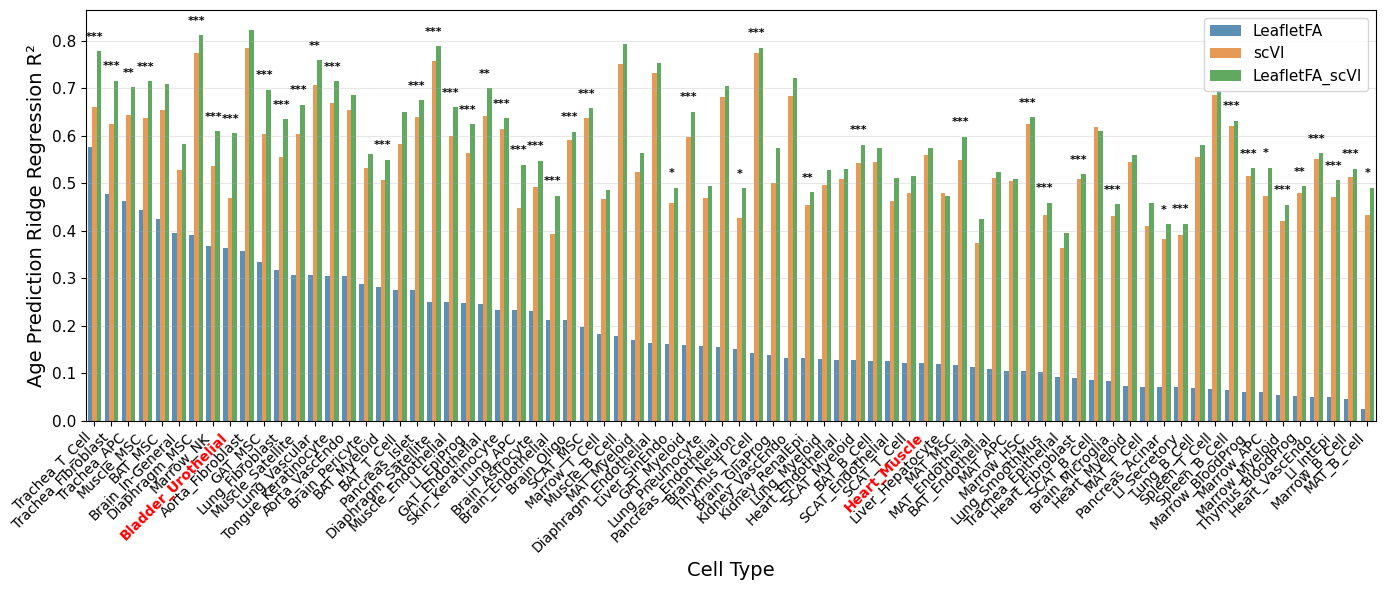

In [25]:
# Run visualizations
summary_df = create_performance_plot(results, output_dir)

In [26]:
print(f"The number of tissue-celltypes in the results for which combined model is better than scVI: {summary_df[summary_df['p_combined_vs_scVI_fdr'] < 0.05]['tissue'].nunique()}")

The number of tissue-celltypes in the results for which combined model is better than scVI: 46


In [27]:
46/76

0.6052631578947368

In [28]:
# save summary_df as csv in output_dir
summary_df.to_csv(f"{output_dir}/summary_df.csv", index=False)
print(f"Saved summary_df to {output_dir}/summary_df.csv")

Saved summary_df to /gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_Submission2025/Mouse_Splicing_Foundation/Figures/FIGURE4/figures/summary_df.csv


In [29]:
print(f"The number of tissue-celltypes in the results: {summary_df['tissue'].nunique()}")

The number of tissue-celltypes in the results: 76


In [30]:
def create_correlation_analysis_with_gene_loadings(splice_adata, ge_adata, output_dir):
    """Create correlation analysis between scVI and LeafletFA factors with top gene loadings."""
    print("Computing factor correlations with gene loading annotations...")
    
    X_PHI = splice_adata.obsm["X_PHI"]
    X_scVI = ge_adata.obsm["X_scVI_linear"]
    scvi_gene_loadings = ge_adata.varm["scVI_linear_gene_loadings"]
    gene_names = ge_adata.var["gene_name"].values
    
    n_scvi_factors = X_scVI.shape[1]
    n_splicing_factors = X_PHI.shape[1]
    
    # Compute correlations
    corr_matrix = np.zeros((n_scvi_factors, n_splicing_factors))
    pval_matrix = np.zeros((n_scvi_factors, n_splicing_factors))
    
    for i in range(n_scvi_factors):
        for j in range(n_splicing_factors):
            rho, pval = spearmanr(X_scVI[:, i], X_PHI[:, j])
            corr_matrix[i, j] = rho
            pval_matrix[i, j] = pval
    
    # FDR correction
    _, pvals_fdr_flat, _, _ = multipletests(pval_matrix.flatten(), method='fdr_bh')
    fdr_matrix = pvals_fdr_flat.reshape(pval_matrix.shape)
    
    # Create significance annotations
    fdr_thresh = 0.05
    rho_thresh = 0.2
    annot_matrix = np.where(
        (fdr_matrix < fdr_thresh) & (np.abs(corr_matrix) > rho_thresh),
        "*", ""
    )
    
    # Create scVI factor labels with top 5 genes
    scvi_factor_names = [f"Z_{i+1}" for i in range(n_scvi_factors)]
    scvi_labels_with_genes = []
    gene_loading_summary = []
    
    for i, factor_name in enumerate(scvi_factor_names):
        # Get top 5 genes by absolute loading values
        factor_loadings = scvi_gene_loadings.iloc[:, i].values
        top_gene_indices = np.argsort(-np.abs(factor_loadings))[:5]  # Top 5 genes
        top_genes = gene_names[top_gene_indices]
        top_loadings = factor_loadings[top_gene_indices]
        
        # Create label with top 3 genes for display (to keep labels readable)
        gene_label = f"{factor_name}: {', '.join(top_genes[:5])}"
        scvi_labels_with_genes.append(gene_label)
        
        # Store detailed info for all top 5 genes
        gene_loading_summary.append({
            'Factor': factor_name,
            'Top_Gene_1': top_genes[0],
            'Loading_1': top_loadings[0],
            'Top_Gene_2': top_genes[1],
            'Loading_2': top_loadings[1],
            'Top_Gene_3': top_genes[2],
            'Loading_3': top_loadings[2],
            'Top_Gene_4': top_genes[3],
            'Loading_4': top_loadings[3],
            'Top_Gene_5': top_genes[4],
            'Loading_5': top_loadings[4],
            'Top_3_Display': ', '.join(top_genes[:3]),
            'Top_5_All': ', '.join(top_genes)
        })
    
    splicing_factor_names = [f"SP_{i+1}" for i in range(n_splicing_factors)]
    
    # Create correlation DataFrame
    corr_df = pd.DataFrame(
        corr_matrix,
        index=scvi_labels_with_genes,
        columns=splicing_factor_names
    )
    
    # Create clustermap with PRGn colormap
    plt.figure(figsize=(9,5))  # Increased size for gene labels
    
    g = sns.clustermap(
        corr_df,
        cmap="PRGn",
        center=0,
        linewidths=0.3,
        linecolor="white",
        xticklabels=True,
        yticklabels=True,
        annot=annot_matrix,
        fmt='',
        annot_kws={'size': 8, 'color': 'black', 'weight': 'bold'},
        figsize=(9,5),
        cbar_kws={'label': 'Spearman Correlation', 'shrink': 0.8},
        col_cluster=False,  # Don't cluster columns (keep SP order)
        row_cluster=True   # Cluster rows (scVI factors)
    )
    
    g.ax_heatmap.set_xlabel("LeafletFA Splicing Programs", fontsize=14, fontweight='bold')
    g.ax_heatmap.set_ylabel("scVI Latent Factors (Top Genes)", fontsize=14, fontweight='bold')
    
    # Adjust label formatting
    plt.setp(g.ax_heatmap.get_xticklabels(), rotation=90, fontsize=10)
    plt.setp(g.ax_heatmap.get_yticklabels(), rotation=0, fontsize=9)
    
    # Add significance legend
    legend_text = f"* Significant: FDR < {fdr_thresh}, |ρ| > {rho_thresh}"
    g.fig.text(0.02, 0.98, legend_text, fontsize=11, style='italic',
               verticalalignment='top', bbox=dict(boxstyle="round,pad=0.3", 
               facecolor="lightgray", alpha=0.7))
    
    # Save the plot
    output_path = f"{output_dir}/scVI_leafletFA_correlation_with_gene_loadings.pdf"
    g.savefig(output_path, dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()
    
    # Save correlation matrix with gene annotations
    corr_df.to_csv(f"{output_dir}/scVI_leafletFA_correlations_with_gene_loadings.csv")
    
    # Save detailed gene loading summary
    gene_loading_df = pd.DataFrame(gene_loading_summary)
    gene_loading_df.to_csv(f"{output_dir}/scVI_top5_gene_loadings_summary.csv", index=False)
    
    print(f"Saved correlation analysis with gene loadings to: {output_path}")
    print(f"Saved detailed gene loading summary to: {output_dir}/scVI_top5_gene_loadings_summary.csv")
    
    # Print summary of top genes
    print("\nTop 5 gene loadings for each scVI factor:")
    for i, summary in enumerate(gene_loading_summary):
        print(f"  {summary['Factor']}: {summary['Top_5_All']}")
        if i >= 9:  # Show first 10 factors
            remaining = len(gene_loading_summary) - 10
            if remaining > 0:
                print(f"  ... and {remaining} more factors (see CSV for complete list)")
            break
    
    return corr_df, gene_loading_df

In [31]:
ge_adata_aging, splicing_aging

(AnnData object with n_obs × n_vars = 80557 × 10572
     obs: 'cell_id', 'age', 'cell_ontology_class', 'mouse.id', 'sex', 'tissue', 'dataset', 'batch', 'subtissue_clean', 'broad_cell_type', 'cell_id_index', 'specific_cell_type', 'medium_cell_type', 'cell_name', 'library_size', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'total_counts_is_rRNA', 'log1p_total_counts_is_rRNA', 'pct_counts_is_rRNA', '_scvi_batch', '_scvi_labels', 'leiden_scVI', 'GAG_score', 'tissue_celltype', 'age_numeric'
     var: 'index', 'gene_name', 'gene_id', 'mean_transcript_length', 'mean_intron_length', 'num_transcripts', 'gene_biotype', 'is_rRNA', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'RBP_gene', 'Aging_gene', 'is_hvg', 'is_rbp', 'is_aging'
     uns: '_scvi_manager_uuid', '_scvi_uuid', 'gene_selection', 'leiden_scVI', 'leiden_scVI_colors', 'leiden_scVI_params', 'neighbors', 'scvi_linear', 'um

Computing factor correlations with gene loading annotations...


<Figure size 900x500 with 0 Axes>

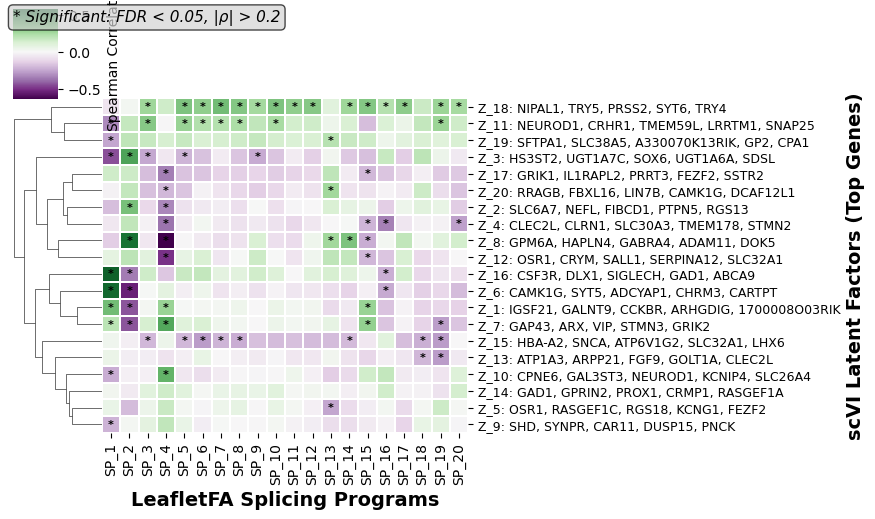

Saved correlation analysis with gene loadings to: /gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_Submission2025/Mouse_Splicing_Foundation/Figures/FIGURE4/figures/scVI_leafletFA_correlation_with_gene_loadings.pdf
Saved detailed gene loading summary to: /gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_Submission2025/Mouse_Splicing_Foundation/Figures/FIGURE4/figures/scVI_top5_gene_loadings_summary.csv

Top 5 gene loadings for each scVI factor:
  Z_1: IGSF21, GALNT9, CCKBR, ARHGDIG, 1700008O03RIK
  Z_2: SLC6A7, NEFL, FIBCD1, PTPN5, RGS13
  Z_3: HS3ST2, UGT1A7C, SOX6, UGT1A6A, SDSL
  Z_4: CLEC2L, CLRN1, SLC30A3, TMEM178, STMN2
  Z_5: OSR1, RASGEF1C, RGS18, KCNG1, FEZF2
  Z_6: CAMK1G, SYT5, ADCYAP1, CHRM3, CARTPT
  Z_7: GAP43, ARX, VIP, STMN3, GRIK2
  Z_8: GPM6A, HAPLN4, GABRA4, ADAM11, DOK5
  Z_9: SHD, SYNPR, CAR11, DUSP15, PNCK
  Z_10: CPNE6, GAL3ST3, NEUROD1, KCNIP4, SLC26A4
  ... and 10 more factors (see CSV for complete list)


In [32]:
# Replace your correlation analysis call with:
corr_df, gene_loading_df = create_correlation_analysis_with_gene_loadings(
    splicing_aging, ge_adata_aging, output_dir)

In [33]:
def create_ridge_coefficients_clustermap(feature_importance_df, splice_adata, output_dir):
    """Create clustermap of ridge coefficients by cell type and factor."""
    print("Creating ridge coefficients clustermap...")
    
    # Pivot the data to create coefficient matrix
    coef_matrix = feature_importance_df.pivot_table(
        index='cell_type',
        columns='factor_name', 
        values='coefficient',
        fill_value=0
    )
    
    # Create mapping from cell_type to broad_cell_type
    cell_type_mapping = splice_adata.obs[['tissue_celltype', 'broad_cell_type']].drop_duplicates()
    cell_type_mapping = cell_type_mapping.set_index('tissue_celltype')['broad_cell_type'].to_dict()
    
    # Get cell counts for each medium cell type
    cell_counts = splice_adata.obs['tissue_celltype'].value_counts().to_dict()
    
    # Create consistent color palette for broad cell types
    unique_broad = splice_adata.obs["broad_cell_type"].unique()
    palette = sns.color_palette("tab20", len(unique_broad))
    palette_dict = dict(zip(unique_broad, palette))
    
    # Create row colors based on broad_cell_type
    broad_cell_types = [cell_type_mapping.get(ct, 'Unknown') for ct in coef_matrix.index]
    row_colors = pd.Series([palette_dict.get(bct, (0.5, 0.5, 0.5)) for bct in broad_cell_types], 
                          index=coef_matrix.index, name='Broad Cell Type')
    
    # Update row labels to include cell counts
    new_row_labels = []
    for ct in coef_matrix.index:
        count = cell_counts.get(ct, 0)
        new_row_labels.append(f"{ct} ({count})")
    
    # Create a copy of the matrix with updated row labels
    coef_matrix_with_counts = coef_matrix.copy()
    coef_matrix_with_counts.index = new_row_labels
    
    # Update row_colors index to match
    row_colors.index = new_row_labels
    
    # Get factor names and separate SP and Z factors
    all_factors = coef_matrix_with_counts.columns.tolist()
    sp_factors = sorted([f for f in all_factors if f.startswith('SP_')], 
                       key=lambda x: int(x.split('_')[1]))
    z_factors = sorted([f for f in all_factors if f.startswith('Z_')], 
                      key=lambda x: int(x.split('_')[1]))
    
    # Create ordered factor list: SP_1, SP_2, ..., Z_1, Z_2, ...
    ordered_factors = sp_factors + z_factors
    
    # Reorder columns according to our desired order
    coef_matrix_ordered = coef_matrix_with_counts[ordered_factors]
    
    # Create figure
    plt.figure(figsize=(16, 10))
    
    # Create clustermap
    g = sns.clustermap(
        coef_matrix_ordered,
        cmap="PRGn",
        center=0,
        linewidths=0.5,
        linecolor="white",
        xticklabels=True,
        yticklabels=True,
        figsize=(18, 12),  # Increased width for color bar
        cbar_kws={'label': 'Ridge Coefficient', 'shrink': 0.8},
        col_cluster=False,  # Don't cluster columns (keep factor order)
        row_cluster=True,   # Cluster rows (cell types)
        row_colors=row_colors,  # Add broad cell type colors
        dendrogram_ratio=0.1,  # Make dendrograms smaller
        colors_ratio=0.03  # Width of the color bar
    )
    
    # Customize the plot
    g.ax_heatmap.set_xlabel("Factors (SP: Splicing Programs, Z: scVI Latent Factors)", 
                           fontsize=14, fontweight='bold')
    g.ax_heatmap.set_ylabel("Cell Types", fontsize=14, fontweight='bold')
    
    # Rotate and adjust tick labels
    plt.setp(g.ax_heatmap.get_xticklabels(), rotation=90, fontsize=10)
    plt.setp(g.ax_heatmap.get_yticklabels(), rotation=0, fontsize=10)
    
    # Add vertical line to separate SP and Z factors
    n_sp_factors = len(sp_factors)
    g.ax_heatmap.axvline(x=n_sp_factors-0.5, color='black', linewidth=2, alpha=0.8)
    
    # Add text annotations to distinguish factor types
    g.ax_heatmap.text(n_sp_factors/2 - 0.5, -1.5, 'Splicing Programs', 
                     ha='center', va='top', fontsize=12, fontweight='bold')
    g.ax_heatmap.text(n_sp_factors + len(z_factors)/2 - 0.5, -1.5, 'Gene Expression', 
                     ha='center', va='top', fontsize=12, fontweight='bold')
    
    # Create custom legend for broad cell types (only show types that appear in the clustermap)
    from matplotlib.patches import Patch
    broad_types_in_plot = list(set(broad_cell_types))
    legend_elements = [Patch(facecolor=palette_dict.get(bct, (0.5, 0.5, 0.5)), label=bct) 
                      for bct in sorted(broad_types_in_plot)]
    
    # Add legend for broad cell types
    g.ax_heatmap.legend(handles=legend_elements, 
                       title='Broad Cell Type',
                       bbox_to_anchor=(1.05, 1), 
                       loc='upper left',
                       frameon=True,
                       fancybox=True,
                       shadow=True)
    
    # Adjust layout to prevent label cutoff
    plt.tight_layout()
    
    # Save the plot
    output_path = f"{output_dir}/ridge_coefficients_clustermap.pdf"
    g.savefig(output_path, dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()
    
    # Save the coefficient matrix
    coef_matrix_ordered.to_csv(f"{output_dir}/ridge_coefficients_matrix.csv")
    
    # Save additional info about broad cell types
    broad_cell_type_info = pd.DataFrame({
        'medium_cell_type': coef_matrix.index,  # Original names without counts
        'medium_cell_type_with_counts': new_row_labels,
        'broad_cell_type': broad_cell_types,
        'cell_count': [cell_counts.get(ct, 0) for ct in coef_matrix.index],
        'color': [palette_dict.get(bct, (0.5, 0.5, 0.5)) for bct in broad_cell_types]
    })
    broad_cell_type_info.to_csv(f"{output_dir}/broad_cell_type_colors.csv", index=False)
    
    print(f"Saved ridge coefficients clustermap to: {output_path}")
    print(f"Saved coefficient matrix to: {output_dir}/ridge_coefficients_matrix.csv")
    print(f"Saved broad cell type colors to: {output_dir}/broad_cell_type_colors.csv")
    
    # Print summary statistics
    print(f"\nClustermap Summary:")
    print(f"  Cell types: {len(coef_matrix_ordered.index)}")
    print(f"  Broad cell types in plot: {len(set(broad_cell_types))}")
    print(f"  Total broad cell types available: {len(unique_broad)}")
    print(f"  Splicing factors (SP): {len(sp_factors)}")
    print(f"  Gene expression factors (Z): {len(z_factors)}")
    print(f"  Total factors: {len(ordered_factors)}")
    print(f"  Coefficient range: {coef_matrix_ordered.min().min():.3f} to {coef_matrix_ordered.max().max():.3f}")
    
    # Print broad cell type distribution
    print(f"\nBroad cell type distribution in clustermap:")
    broad_type_counts = pd.Series(broad_cell_types).value_counts()
    for bct, count in broad_type_counts.items():
        total_cells = sum([cell_counts.get(ct, 0) for ct, bct_mapped in cell_type_mapping.items() if bct_mapped == bct and ct in coef_matrix.index])
        print(f"  {bct}: {count} medium cell types, {total_cells} total cells")
    
    # Show top positive and negative coefficients
    coef_flat = coef_matrix_ordered.stack().reset_index()
    coef_flat.columns = ['cell_type', 'factor', 'coefficient']
    
    print(f"\nTop 5 positive coefficients:")
    top_pos = coef_flat.nlargest(5, 'coefficient')
    for _, row in top_pos.iterrows():
        print(f"  {row['cell_type']} - {row['factor']}: {row['coefficient']:.3f}")
    
    print(f"\nTop 5 negative coefficients:")
    top_neg = coef_flat.nsmallest(5, 'coefficient')
    for _, row in top_neg.iterrows():
        print(f"  {row['cell_type']} - {row['factor']}: {row['coefficient']:.3f}")
    
    return coef_matrix_ordered, g

Creating ridge coefficients clustermap...


<Figure size 1600x1000 with 0 Axes>

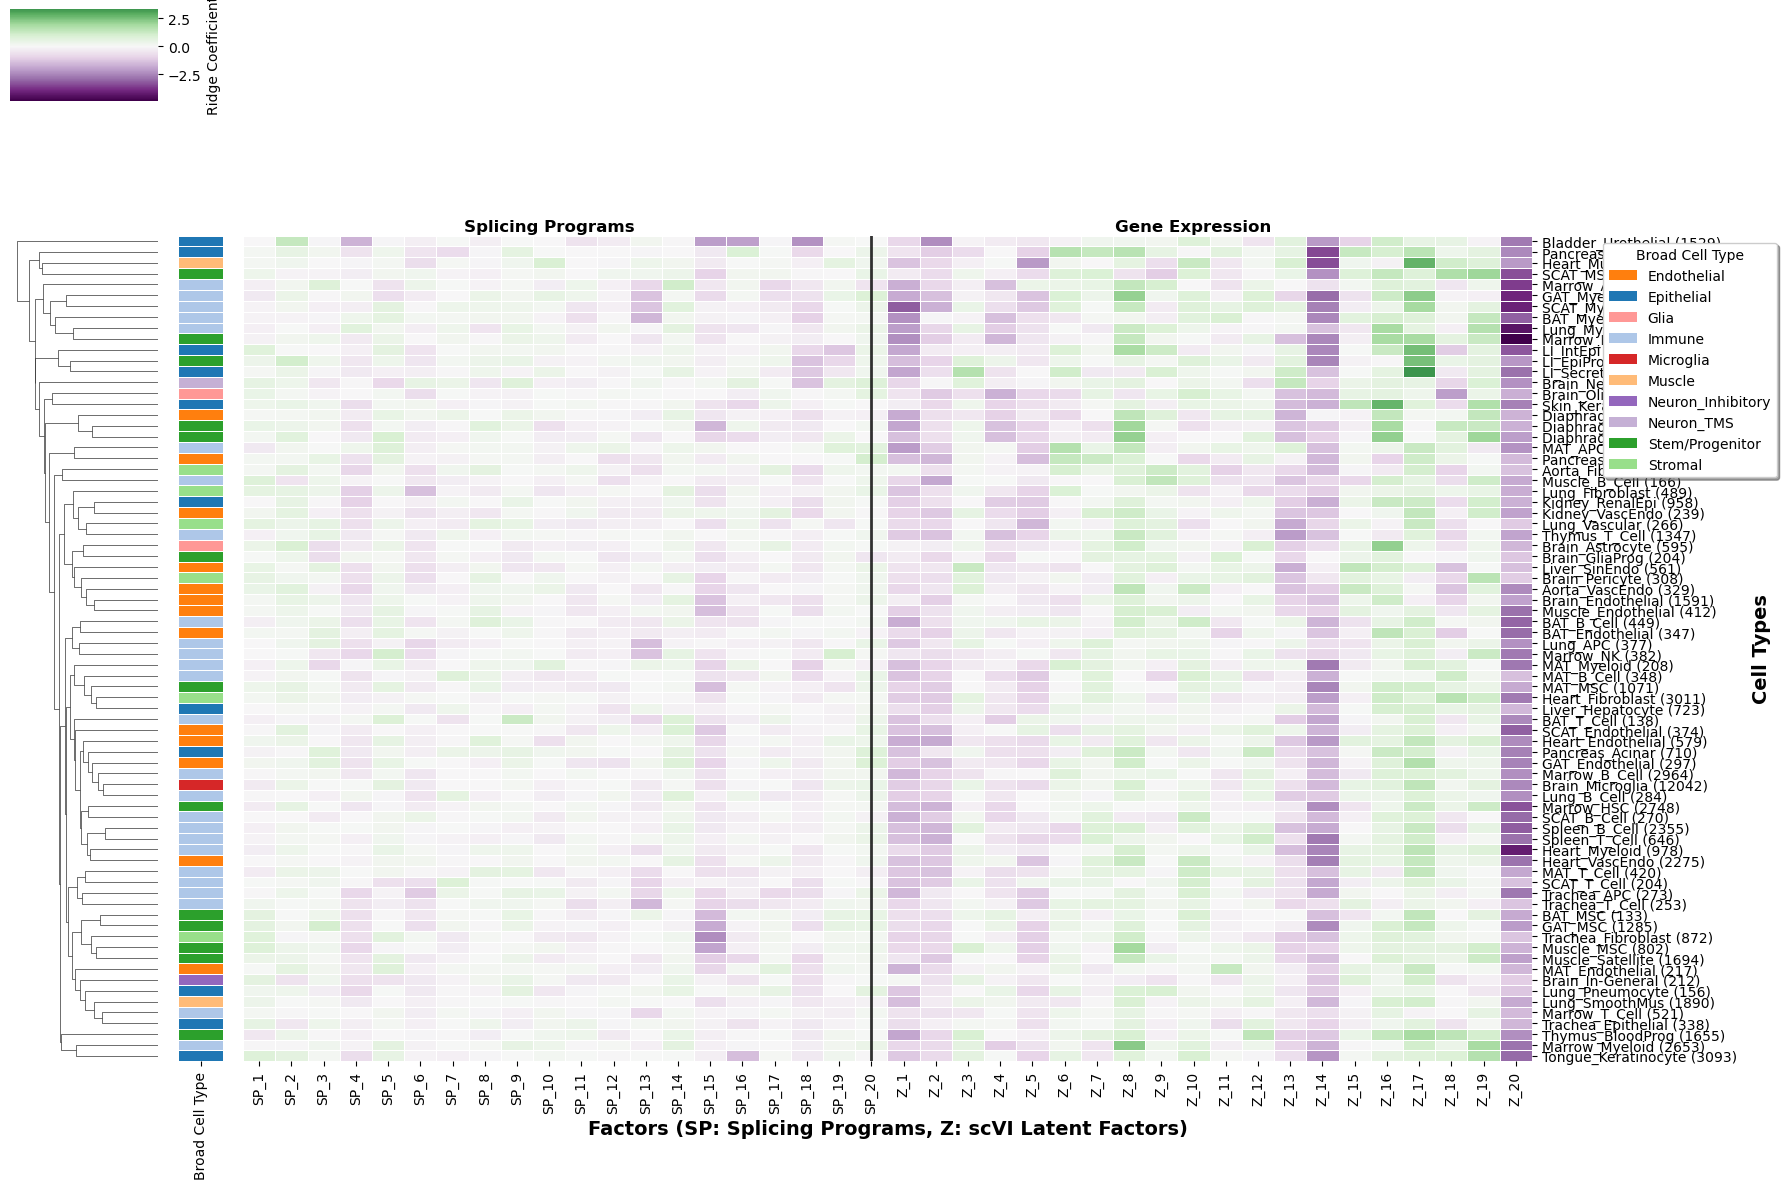

Saved ridge coefficients clustermap to: /gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_Submission2025/Mouse_Splicing_Foundation/Figures/FIGURE4/figures/ridge_coefficients_clustermap.pdf
Saved coefficient matrix to: /gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_Submission2025/Mouse_Splicing_Foundation/Figures/FIGURE4/figures/ridge_coefficients_matrix.csv
Saved broad cell type colors to: /gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_Submission2025/Mouse_Splicing_Foundation/Figures/FIGURE4/figures/broad_cell_type_colors.csv

Clustermap Summary:
  Cell types: 76
  Broad cell types in plot: 10
  Total broad cell types available: 10
  Splicing factors (SP): 20
  Gene expression factors (Z): 20
  Total factors: 40
  Coefficient range: -4.845 to 3.335

Broad cell type distribution in clustermap:
  Immune: 26 medium cell types, 18203 total cells
  Endothelial: 13 medium cell types, 7552 total cells
  Stem/Progenitor: 13 medium cell types, 14887 total cells
  Epithelial: 11 m

In [34]:
coef_matrix, clustermap_obj = create_ridge_coefficients_clustermap(
    feature_importance_df, splice_adata, output_dir)

In [35]:
# rename columns ge_adata.varm["scVI_linear_gene_loadings"] to be Z_1 to Z_20 
ge_adata.varm["scVI_linear_gene_loadings"].columns = [f"Z_{i}" for i in range(1, 21)]

##  Visualize Factor Activity in a Given Cell Type

In [36]:
def plot_factor_activity_by_age(
    adata,
    factor_matrix_key,
    factor_prefix,
    factor_index,
    cell_type_name,
    obs_col="tissue_celltype",
    age_col="age_numeric"
):
    """
    Plot a specific factor's activity across ages within a selected cell type.
    Adds cell counts to x-axis labels and adjusts color if factor is gene expression.
    """
    # Filter to the target cell type
    mask = adata.obs[obs_col] == cell_type_name
    if mask.sum() == 0:
        print(f"No cells found for cell type: {cell_type_name}")
        return

    # Get data
    factor_values = adata.obsm[factor_matrix_key][mask, factor_index]
    ages = adata.obs.loc[mask, age_col]

    # Build DataFrame
    factor_label = f"{factor_prefix}_{factor_index + 1}"
    df = pd.DataFrame({
        factor_label: factor_values,
        "age": ages
    })

    # Compute counts and relabel x-axis
    age_counts = df["age"].value_counts().sort_index()
    age_labels = [f"{int(age)} (n={count})" for age, count in age_counts.items()]
    age_order = age_counts.index.tolist()

    # Choose color palette
    if factor_prefix.upper().startswith("Z"):
        violin_color = "#4C72B0"  # blue for gene expression
    else:
        violin_color = "#55A868"  # green for splicing

    # Plot
    plt.figure(figsize=(6, 4))
    sns.violinplot(
        data=df, x="age", y=factor_label,
        order=age_order,
        inner="box", linewidth=1, color=violin_color
    )
    sns.stripplot(
        data=df, x="age", y=factor_label,
        order=age_order,
        color="black", alpha=0.3, jitter=0.2, size=2
    )

    # Set custom x-tick labels
    plt.xticks(ticks=range(len(age_labels)), labels=age_labels, rotation=0)
    plt.title(f"{factor_label} Activity in {cell_type_name} by Age", fontsize=13)
    plt.xlabel("Age (with cell counts)")
    plt.ylabel("Factor Activity")
    plt.tight_layout()
    plt.show()

In [37]:
splicing_aging, ge_adata_aging

(AnnData object with n_obs × n_vars = 80557 × 70102
     obs: 'cell_id_index', 'age', 'donor_id', 'sex', 'subtissue', 'cell_name', 'cell_id', 'cell_clean', 'specific_cell_type', 'medium_cell_type', 'seqtech', 'library_size', 'total_junction_reads', 'annotated_junction_reads', 'unannotated_junction_reads', 'n_detected_annotated_junctions', 'n_detected_unannotated_junctions', 'age_numeric', 'age_group', 'cell_ontology_class', 'broad_cell_type', 'tissue', 'tissue_celltype', 'dataset', 'total_counts', 'GAG_score', 'SP_1', 'SP_2', 'SP_3', 'SP_4', 'SP_5', 'SP_6', 'SP_7', 'SP_8', 'SP_9', 'SP_10', 'SP_11', 'SP_12', 'SP_13', 'SP_14', 'SP_15', 'SP_16', 'SP_17', 'SP_18', 'SP_19', 'SP_20', 'perplexity'
     var: 'index', 'junction_id', 'event_id', 'splice_motif', 'annotation_status', 'gene_name', 'gene_id', 'num_junctions', 'position_off_5_prime', 'position_off_3_prime', 'CountJuncs', 'junction_id_index', 'n_cells_detected', 'confidence', 'aging_gene', 'aging_lifespan_effect', 'aging_longevity_inf

In [38]:
ge_adata_aging.obs["tissue_celltype"] = splicing_aging.obs["tissue_celltype"]

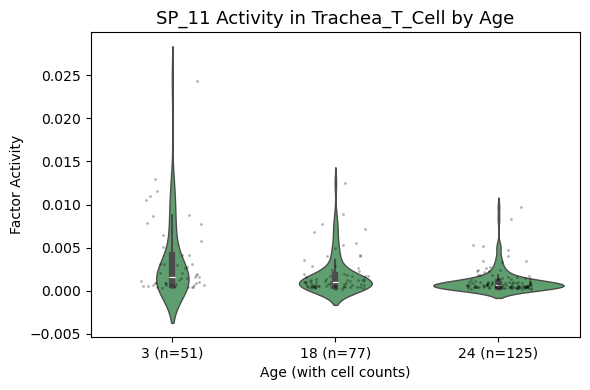

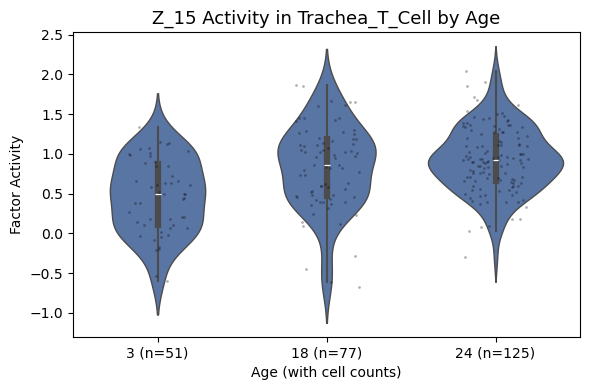

In [39]:
plot_factor_activity_by_age(splicing_aging, "X_PHI", "SP", factor_index=10, cell_type_name="Trachea_T_Cell")
plot_factor_activity_by_age(ge_adata_aging, "X_scVI_linear", "Z", factor_index=14, cell_type_name="Trachea_T_Cell")

## Correlation Between SP and Z Factors in a Given Cell Type

In [40]:
def plot_sp_z_correlation(splice_adata, ge_adata, sp_index, z_index, cell_type_name, obs_col="tissue_celltype"):
    """
    Scatter plot of SP and Z factor activity for a specific cell type.
    """
    # Add option to plot all cells 
    # Make hexbin version to group points into high density regions
    mask = splice_adata.obs[obs_col] == cell_type_name
    sp_val = splice_adata.obsm["X_PHI"][mask, sp_index]
    z_val = ge_adata.obsm["X_scVI_linear"][mask, z_index]
    
    df = pd.DataFrame({
        f"SP_{sp_index+1}": sp_val,
        f"Z_{z_index+1}": z_val
    })

    corr = np.corrcoef(sp_val, z_val)[0, 1]
    
    plt.figure(figsize=(5, 4))
    sns.scatterplot(x=f"SP_{sp_index+1}", y=f"Z_{z_index+1}", data=df, s=20, alpha=0.7, edgecolor='black')
    plt.title(f"{cell_type_name}: SP_{sp_index+1} vs Z_{z_index+1}\nPearson r = {corr:.2f}")
    plt.tight_layout()
    plt.show()

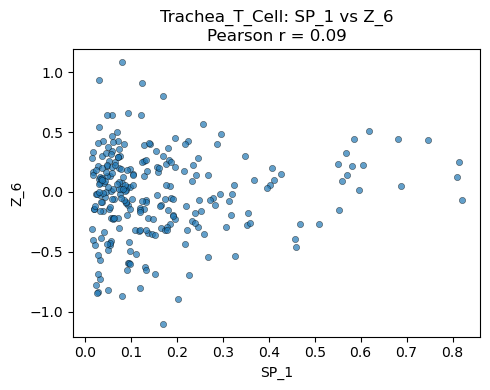

In [41]:
plot_sp_z_correlation(splice_adata, ge_adata, sp_index=0, z_index=5, cell_type_name="Trachea_T_Cell")

In [42]:
feature_importance_df.sort_values(by="combined_r2", ascending=False)

,cell_type,factor_type,factor_name,coefficient,abs_coefficient,combined_r2,p_vs_scvi
1909,Aorta_Fibroblast,Gene_Expression,Z_10,0.662620,0.662620,0.823804,0.088558
1900,Aorta_Fibroblast,Gene_Expression,Z_1,0.145284,0.145284,0.823804,0.088558
1898,Aorta_Fibroblast,Splicing,SP_19,0.289037,0.289037,0.823804,0.088558
1897,Aorta_Fibroblast,Splicing,SP_18,-0.767839,0.767839,0.823804,0.088558
1896,Aorta_Fibroblast,Splicing,SP_17,0.645465,0.645465,0.823804,0.088558
...,...,...,...,...,...,...,...
26,Trachea_Epithelial,Gene_Expression,Z_7,0.065930,0.065930,0.396454,0.694834
25,Trachea_Epithelial,Gene_Expression,Z_6,0.158704,0.158704,0.396454,0.694834
24,Trachea_Epithelial,Gene_Expression,Z_5,-0.643360,0.643360,0.396454,0.694834
23,Trachea_Epithelial,Gene_Expression,Z_4,0.088925,0.088925,0.396454,0.694834


In [43]:
import matplotlib.pyplot as plt
import pandas as pd

def create_factor_boxplot_summary(feature_importance_df, output_dir):
    """
    Simplified publication-ready boxplot showing coefficient distributions.
    Percentage bubbles removed.
    """
    print("🔍 Creating simplified factor summary boxplot...")
    
    # Pivot to wide format for coefficients by cell type and factor
    coef_matrix = feature_importance_df.pivot_table(
        index='cell_type',
        columns='factor_name',
        values='coefficient',
        fill_value=0
    )

    # Separate SP and Z factors
    all_factors = list(coef_matrix.columns)
    sp_factors = sorted([f for f in all_factors if f.startswith("SP_")], key=lambda x: int(x.split("_")[1]))
    z_factors = sorted([f for f in all_factors if f.startswith("Z_")], key=lambda x: int(x.split("_")[1]))
    
    # Create subplot
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 11), sharex=False, gridspec_kw={'hspace':0.32})
    
    boxprops_sp = dict(facecolor='#B8D7F7', color='#1f77b4', linewidth=1.5)
    medianprops_sp = dict(color='#1f77b4', linewidth=2.5)
    boxprops_z = dict(facecolor='#FFE6C3', color='#ff7f0e', linewidth=1.5)
    medianprops_z = dict(color='#ff7f0e', linewidth=2.5)

    # --- SP Boxplot (LeafletFA) ---
    sp_data = [coef_matrix[f] for f in sp_factors]
    ax1.boxplot(
        sp_data, 
        patch_artist=True,
        boxprops=boxprops_sp,
        medianprops=medianprops_sp,
        whiskerprops={'color':'#1f77b4'}, 
        capprops={'color':'#1f77b4'},
        flierprops={'marker':'o', 'color':'#1f77b4', 'markersize':4, 'alpha':0.5}
    )
    ax1.set_xticks(range(1, len(sp_factors)+1))
    ax1.set_xticklabels([f.replace('SP_', '') for f in sp_factors], fontsize=14)
    ax1.set_ylabel('Coefficient Across Cell Types', fontweight='bold', fontsize=16)
    ax1.set_title('LeafletFA Splicing Programs - Aging Association', fontweight='bold', fontsize=18)
    ax1.axhline(0, color='black', linestyle='-', alpha=0.5, linewidth=1.5)
    ax1.grid(True, alpha=0.3)
    ax1.tick_params(axis='both', which='major', labelsize=14)
    
    # --- Z Boxplot (scVI) ---
    z_data = [coef_matrix[f] for f in z_factors]
    ax2.boxplot(
        z_data,
        patch_artist=True,
        boxprops=boxprops_z,
        medianprops=medianprops_z,
        whiskerprops={'color':'#ff7f0e'}, 
        capprops={'color':'#ff7f0e'},
        flierprops={'marker':'o', 'color':'#ff7f0e', 'markersize':4, 'alpha':0.5}
    )
    ax2.set_xticks(range(1, len(z_factors)+1))
    ax2.set_xticklabels([f.replace('Z_', '') for f in z_factors], fontsize=14)
    ax2.set_xlabel('Factor Number', fontweight='bold', fontsize=16)
    ax2.set_ylabel('Coefficient Across Cell Types', fontweight='bold', fontsize=16)
    ax2.set_title('scVI Gene Expression Factors - Aging Association', fontweight='bold', fontsize=18)
    ax2.axhline(0, color='black', linestyle='-', alpha=0.5, linewidth=1.5)
    ax2.grid(True, alpha=0.3)
    ax2.tick_params(axis='both', which='major', labelsize=14)
    
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.08)
    
    # Save
    output_path = f"{output_dir}/factor_aging_boxplot_summary_clean.pdf"
    print(f"📁 Saving to: {output_path}")
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    plt.show()

In [44]:
def create_factor_violin_summary(feature_importance_df, output_dir):
    """
    Publication-ready violin plot showing coefficient distributions.
    """
    print("🔍 Creating simplified factor summary violin plot...")
    
    # Pivot to wide format
    coef_matrix = feature_importance_df.pivot_table(
        index='cell_type',
        columns='factor_name',
        values='coefficient',
        fill_value=0
    )

    # Separate SP and Z factors
    all_factors = list(coef_matrix.columns)
    sp_factors = sorted([f for f in all_factors if f.startswith("SP_")], key=lambda x: int(x.split("_")[1]))
    z_factors = sorted([f for f in all_factors if f.startswith("Z_")], key=lambda x: int(x.split("_")[1]))
    
    # Create subplot
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6), sharex=False, gridspec_kw={'hspace':0.35})
    
    # Helper to style violins
    def style_violins(parts, facecolor, edgecolor):
        # Style the 'bodies' (the filled area)
        for pc in parts['bodies']:
            pc.set_facecolor(facecolor)
            pc.set_edgecolor(edgecolor)
            pc.set_alpha(0.8) # Slight transparency
        
        # Style the lines (min, max, median)
        for partname in ('cbars', 'cmins', 'cmaxes', 'cmedians'):
            vp = parts[partname]
            vp.set_edgecolor(edgecolor)
            vp.set_linewidth(1.5)

    # --- SP Violin Plot (LeafletFA) ---
    sp_data = [coef_matrix[f].values for f in sp_factors]
    
    parts1 = ax1.violinplot(
        sp_data,
        positions=range(1, len(sp_factors)+1),
        showmeans=False,
        showmedians=True,
        widths=0.8
    )
    style_violins(parts1, facecolor='#B8D7F7', edgecolor='#1f77b4')

    ax1.set_xticks(range(1, len(sp_factors)+1))
    ax1.set_xticklabels([f.replace('SP_', '') for f in sp_factors], fontsize=12)
    ax1.set_ylabel('Coefficient', fontweight='bold', fontsize=16)
    ax1.set_title('LeafletFA Splicing Programs - Aging Association', fontweight='bold', fontsize=18)
    ax1.axhline(0, color='black', linestyle='-', alpha=0.5, linewidth=1.5)
    ax1.grid(True, axis='y', alpha=0.3) # Grid on Y only usually looks cleaner for violins
    ax1.tick_params(axis='both', which='major', labelsize=12)
    
    # --- Z Violin Plot (scVI) ---
    z_data = [coef_matrix[f].values for f in z_factors]
    
    parts2 = ax2.violinplot(
        z_data,
        positions=range(1, len(z_factors)+1),
        showmeans=False,
        showmedians=True,
        widths=0.8
    )
    style_violins(parts2, facecolor='#FFE6C3', edgecolor='#ff7f0e')

    ax2.set_xticks(range(1, len(z_factors)+1))
    ax2.set_xticklabels([f.replace('Z_', '') for f in z_factors], fontsize=12, rotation=0)
    ax2.set_xlabel('Factor Number', fontweight='bold', fontsize=16)
    ax2.set_ylabel('Coefficient', fontweight='bold', fontsize=16)
    ax2.set_title('scVI Gene Expression Factors - Aging Association', fontweight='bold', fontsize=18)
    ax2.axhline(0, color='black', linestyle='-', alpha=0.5, linewidth=1.5)
    ax2.grid(True, axis='y', alpha=0.3)
    ax2.tick_params(axis='both', which='major', labelsize=12)
    
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.08)
    
    # Save
    output_path = f"{output_dir}/factor_aging_violin_summary.pdf"
    print(f"📁 Saving to: {output_path}")
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    plt.show()

In [45]:
output_dir

'/gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_Submission2025/Mouse_Splicing_Foundation/Figures/FIGURE4/figures'

In [46]:
# save feature_importance_df as csv in output_dir
feature_importance_df.to_csv(f"{output_dir}/feature_importance_df.csv", index=False)
print(f"Saved feature_importance_df to {output_dir}/feature_importance_df.csv")

Saved feature_importance_df to /gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_Submission2025/Mouse_Splicing_Foundation/Figures/FIGURE4/figures/feature_importance_df.csv


🔍 Creating simplified factor summary violin plot...
📁 Saving to: /gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_Submission2025/Mouse_Splicing_Foundation/Figures/FIGURE4/figures/factor_aging_violin_summary.pdf


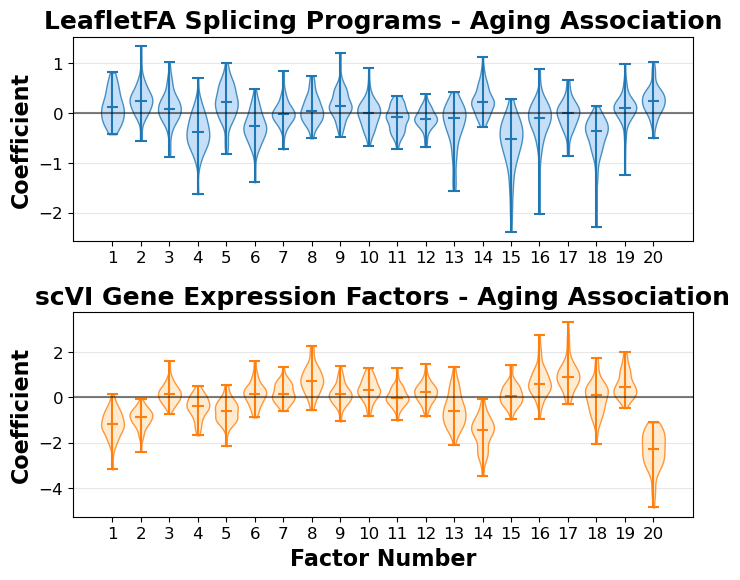

In [47]:
# Example usage:
create_factor_violin_summary(feature_importance_df, output_dir)

Running univariate (one-at-a-time) analysis by tissue_celltype...


100%|██████████| 76/76 [00:02<00:00, 28.42it/s]


🔍 Creating simplified factor summary violin plot...
📁 Saving to: /gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_Submission2025/Mouse_Splicing_Foundation/Figures/FIGURE4/figures/factor_aging_violin_summary.pdf


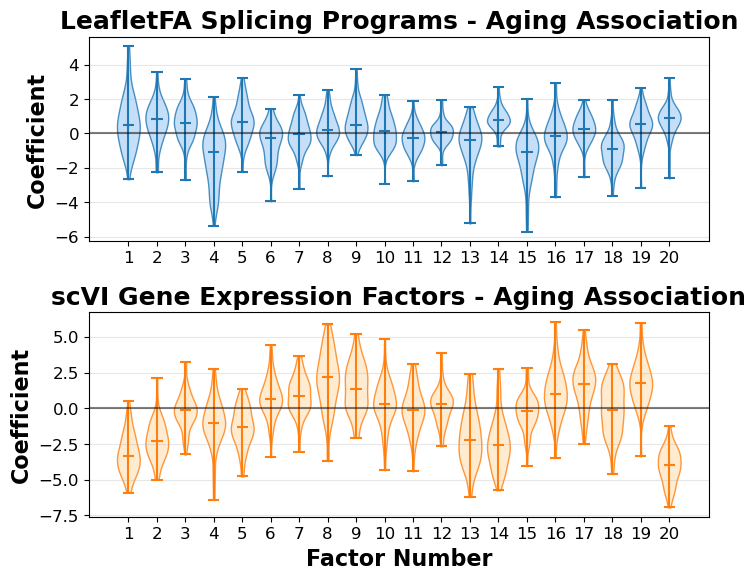

In [48]:
from scipy import stats
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
from tqdm import tqdm

def run_tissue_univariate_analysis(splice_adata, ge_adata, covariate="tissue_celltype"):
    """
    Run univariate regression analysis (one factor at a time).
    
    Returns:
        pd.DataFrame: A dataframe compatible with the plotting functions, 
                      containing coefficients, p-values, and R2 for each factor alone.
    """
    print(f"Running univariate (one-at-a-time) analysis by {covariate}...")
    
    # Check alignment
    assert all(splice_adata.obs_names == ge_adata.obs_names)
    
    # Extract matrices
    dirichlet_data = splice_adata.obsm["X_PHI"]
    scvi_data = ge_adata.obsm["X_scVI_linear"]
    age = splice_adata.obs['age_numeric'].values
    
    feature_importance_data = []
    
    n_splice_factors = dirichlet_data.shape[1]
    n_scvi_factors = scvi_data.shape[1]
    
    # Generate names
    splice_factor_names = [f"SP_{i+1}" for i in range(n_splice_factors)]
    scvi_factor_names = [f"Z_{i+1}" for i in range(n_scvi_factors)]
    
    # Loop over tissues
    unique_tissues = splice_adata.obs[covariate].unique()
    
    for tissue in tqdm(unique_tissues):
        mask = (splice_adata.obs[covariate] == tissue).values
        
        # Skip tissues with too few cells or no age variance
        if mask.sum() < 100 or len(np.unique(age[mask])) == 1:
            continue
            
        # Get tissue-specific data
        # We MUST standardize X to make coefficients comparable (Age change per 1 SD of factor)
        X_sp = StandardScaler().fit_transform(dirichlet_data[mask])
        X_sc = StandardScaler().fit_transform(scvi_data[mask])
        y = age[mask]
        
        # --- Analyze Splicing Factors ---
        for i, name in enumerate(splice_factor_names):
            x_factor = X_sp[:, i]
            
            # Use linregress for fast OLS stats
            slope, intercept, r_value, p_value, std_err = stats.linregress(x_factor, y)
            
            feature_importance_data.append({
                'cell_type': tissue,
                'factor_type': 'Splicing',
                'factor_name': name,
                'coefficient': slope,       # This is the effect size
                'p_value': p_value,         # Significance
                'r2': r_value**2,           # Variance explained by this factor alone
                'abs_coefficient': abs(slope)
            })
            
        # --- Analyze Gene Expression (scVI) Factors ---
        for i, name in enumerate(scvi_factor_names):
            x_factor = X_sc[:, i]
            
            slope, intercept, r_value, p_value, std_err = stats.linregress(x_factor, y)
            
            feature_importance_data.append({
                'cell_type': tissue,
                'factor_type': 'Gene_Expression',
                'factor_name': name,
                'coefficient': slope,
                'p_value': p_value,
                'r2': r_value**2,
                'abs_coefficient': abs(slope)
            })
    
    return pd.DataFrame(feature_importance_data)

# --- USAGE EXAMPLE ---
# 1. Run the analysis
univariate_df = run_tissue_univariate_analysis(splice_adata, ge_adata, covariate="tissue_celltype")

# 2. Visualize using the SAME function from before
create_factor_violin_summary(univariate_df, output_dir)

In [49]:
def create_forest_plot_single_celltype(feature_df, cell_type, output_dir, top_n_factors=10, figsize=(4, 4)):
    """Create a simple forest plot for a single cell type."""
    
    # Filter and get top factors
    ct_data = feature_df[feature_df['cell_type'] == cell_type].copy()
    ct_data = ct_data.nlargest(top_n_factors, 'abs_coefficient').sort_values('coefficient')
    
    # Plot
    fig, ax = plt.subplots(1, 1, figsize=figsize)
    colors = {'Splicing': '#1f77b4', 'Gene_Expression': '#ff7f0e'}
    
    for i, (_, row) in enumerate(ct_data.iterrows()):
        ax.errorbar(row['coefficient'], i, 
                   xerr=[[row['coefficient'] - row['ci_lower']], [row['ci_upper'] - row['coefficient']]], 
                   fmt='o', color=colors[row['factor_type']], capsize=3, markersize=6, alpha=0.8)
        
        factor_label = row['factor_name']
        ax.text(row['coefficient'], i, f"  {factor_label}", va='center', 
               ha='left' if row['coefficient'] >= 0 else 'right', fontsize=10)
    
    # Format
    ax.axvline(0, color='black', linestyle='--', alpha=0.5)
    ax.set_xlabel('Ridge Regression Coefficient ± 95% CI', fontweight='bold', fontsize=11)
    ax.set_ylabel('Top Factors', fontweight='bold', fontsize=11)
    ax.set_title(cell_type, fontweight='bold', fontsize=12)
    ax.set_yticks([])
    ax.tick_params(axis='x', labelsize=12)
    ax.grid(True, alpha=0.3, axis='x')
    
    # Legend
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor=colors['Splicing'], label='LeafletFA'),
                      Patch(facecolor=colors['Gene_Expression'], label='scVI')]
    ax.legend(handles=legend_elements, loc='best', fontsize=9)
    
    plt.tight_layout()
    plt.savefig(f"{output_dir}/forest_plot_{cell_type.replace(' ', '_').replace('/', '_')}.pdf", 
                dpi=300, bbox_inches='tight')
    print(f"Saved file to {output_dir}/forest_plot_{cell_type.replace(' ', '_').replace('/', '_')}.pdf")
    plt.show()

In [50]:
feature_df_ci

,cell_type,factor_type,factor_name,coefficient,ci_lower,ci_upper,abs_coefficient,combined_r2,p_vs_scvi,significant
0,Trachea_Epithelial,Splicing,SP_1,0.549265,0.371449,0.816316,0.549265,0.396454,0.694834,True
1,Trachea_Epithelial,Splicing,SP_2,-0.423479,-0.695882,-0.204761,0.423479,0.396454,0.694834,True
2,Trachea_Epithelial,Splicing,SP_3,0.320273,-0.039833,0.593825,0.320273,0.396454,0.694834,False
3,Trachea_Epithelial,Splicing,SP_4,-0.244587,-0.570414,0.122349,0.244587,0.396454,0.694834,False
4,Trachea_Epithelial,Splicing,SP_5,0.127024,-0.049895,0.336609,0.127024,0.396454,0.694834,False
...,...,...,...,...,...,...,...,...,...,...
3035,Diaphragm_Endothelial,Gene_Expression,Z_16,1.367422,0.882354,1.715090,1.367422,0.753051,0.912810,True
3036,Diaphragm_Endothelial,Gene_Expression,Z_17,0.114010,-0.246243,0.632092,0.114010,0.753051,0.912810,False
3037,Diaphragm_Endothelial,Gene_Expression,Z_18,0.161775,-0.186714,0.509423,0.161775,0.753051,0.912810,False
3038,Diaphragm_Endothelial,Gene_Expression,Z_19,1.370871,1.002301,1.680384,1.370871,0.753051,0.912810,True


Saved file to /gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_Submission2025/Mouse_Splicing_Foundation/Figures/FIGURE4/figures/forest_plot_Trachea_Epithelial.pdf


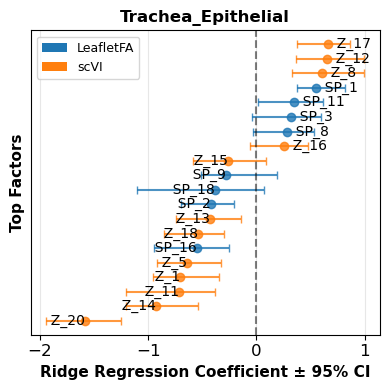

Saved file to /gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_Submission2025/Mouse_Splicing_Foundation/Figures/FIGURE4/figures/forest_plot_Skin_Keratinocyte.pdf


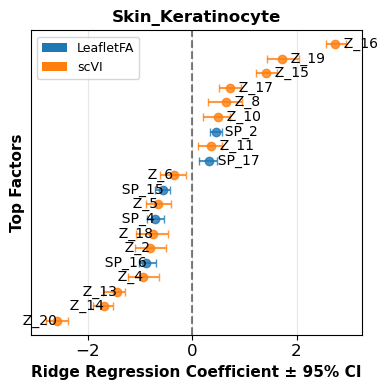

Saved file to /gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_Submission2025/Mouse_Splicing_Foundation/Figures/FIGURE4/figures/forest_plot_SCAT_Myeloid.pdf


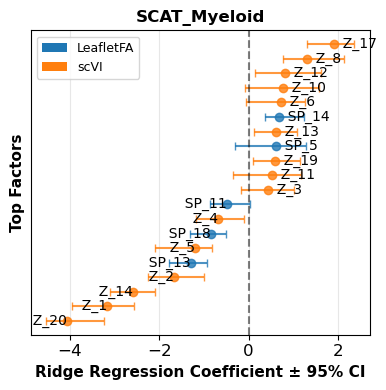

Saved file to /gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_Submission2025/Mouse_Splicing_Foundation/Figures/FIGURE4/figures/forest_plot_Heart_VascEndo.pdf


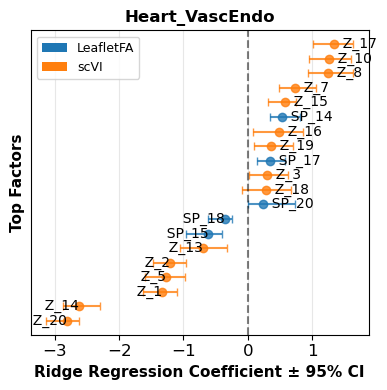

Saved file to /gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_Submission2025/Mouse_Splicing_Foundation/Figures/FIGURE4/figures/forest_plot_Heart_Muscle.pdf


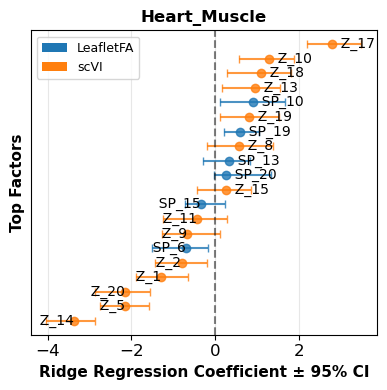

Saved file to /gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_Submission2025/Mouse_Splicing_Foundation/Figures/FIGURE4/figures/forest_plot_Brain_Endothelial.pdf


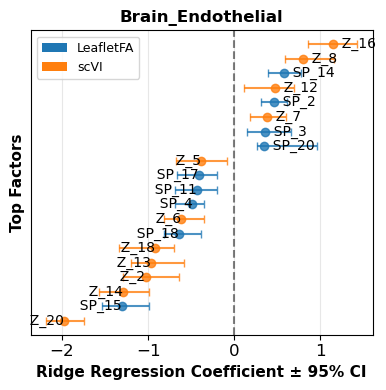

Saved file to /gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_Submission2025/Mouse_Splicing_Foundation/Figures/FIGURE4/figures/forest_plot_Lung_SmoothMus.pdf


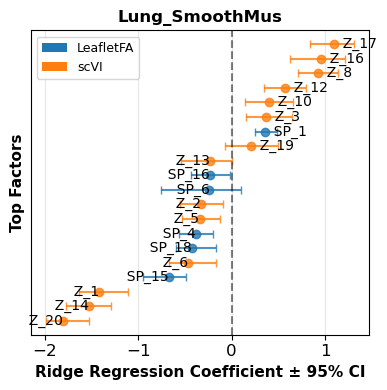

Saved file to /gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_Submission2025/Mouse_Splicing_Foundation/Figures/FIGURE4/figures/forest_plot_LI_IntEpi.pdf


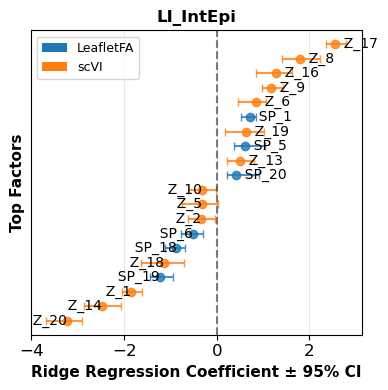

Saved file to /gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_Submission2025/Mouse_Splicing_Foundation/Figures/FIGURE4/figures/forest_plot_LI_EpiProg.pdf


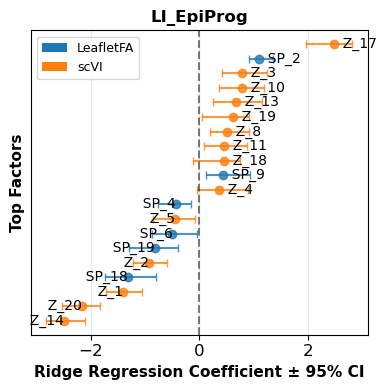

Saved file to /gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_Submission2025/Mouse_Splicing_Foundation/Figures/FIGURE4/figures/forest_plot_Lung_Fibroblast.pdf


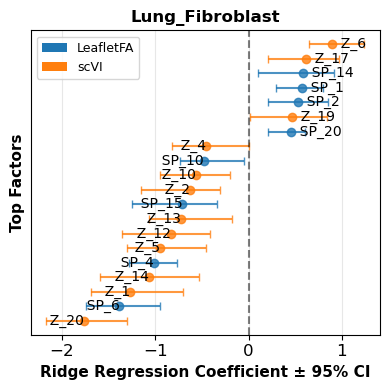

Saved file to /gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_Submission2025/Mouse_Splicing_Foundation/Figures/FIGURE4/figures/forest_plot_SCAT_B_Cell.pdf


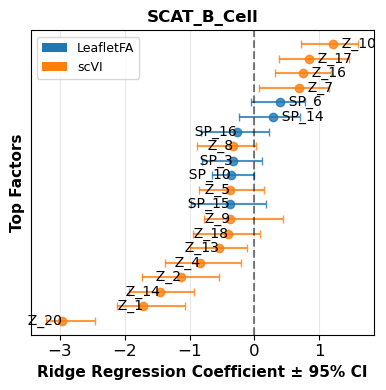

Saved file to /gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_Submission2025/Mouse_Splicing_Foundation/Figures/FIGURE4/figures/forest_plot_Marrow_Myeloid.pdf


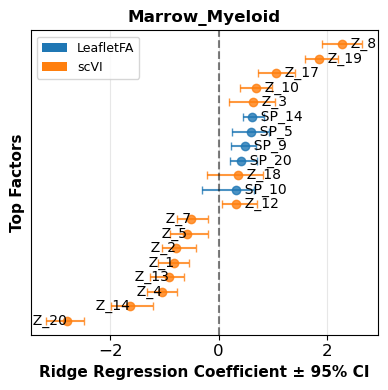

Saved file to /gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_Submission2025/Mouse_Splicing_Foundation/Figures/FIGURE4/figures/forest_plot_GAT_Myeloid.pdf


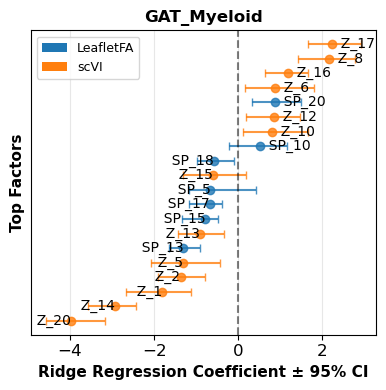

Saved file to /gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_Submission2025/Mouse_Splicing_Foundation/Figures/FIGURE4/figures/forest_plot_MAT_T_Cell.pdf


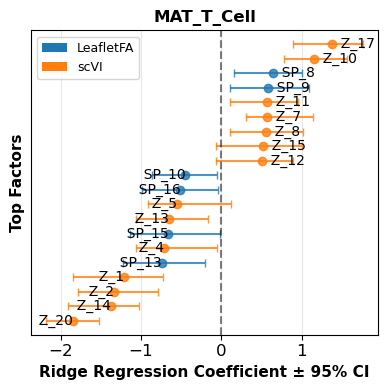

Saved file to /gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_Submission2025/Mouse_Splicing_Foundation/Figures/FIGURE4/figures/forest_plot_Marrow_BloodProg.pdf


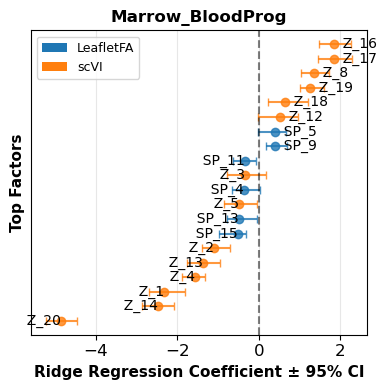

Saved file to /gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_Submission2025/Mouse_Splicing_Foundation/Figures/FIGURE4/figures/forest_plot_MAT_Myeloid.pdf


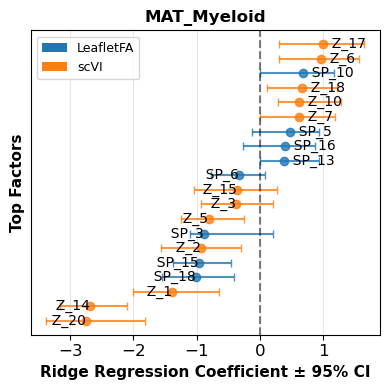

Saved file to /gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_Submission2025/Mouse_Splicing_Foundation/Figures/FIGURE4/figures/forest_plot_BAT_B_Cell.pdf


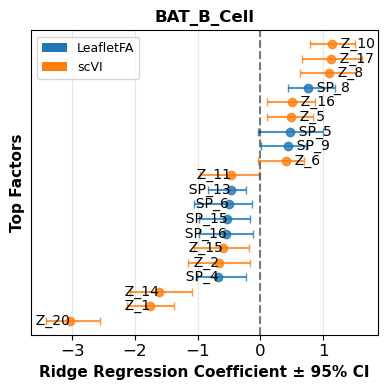

Saved file to /gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_Submission2025/Mouse_Splicing_Foundation/Figures/FIGURE4/figures/forest_plot_Heart_Endothelial.pdf


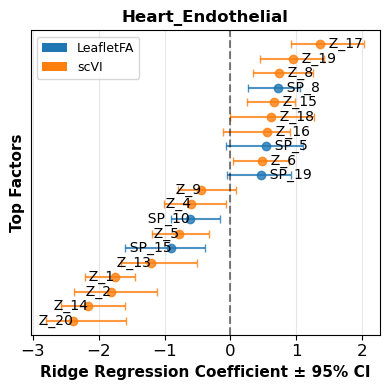

Saved file to /gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_Submission2025/Mouse_Splicing_Foundation/Figures/FIGURE4/figures/forest_plot_BAT_Myeloid.pdf


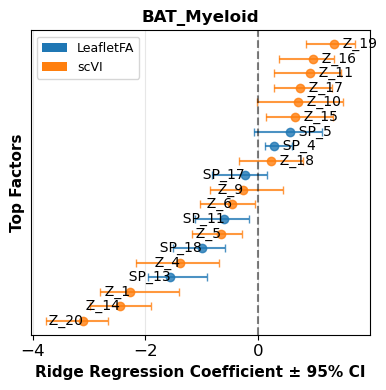

Saved file to /gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_Submission2025/Mouse_Splicing_Foundation/Figures/FIGURE4/figures/forest_plot_Bladder_Urothelial.pdf


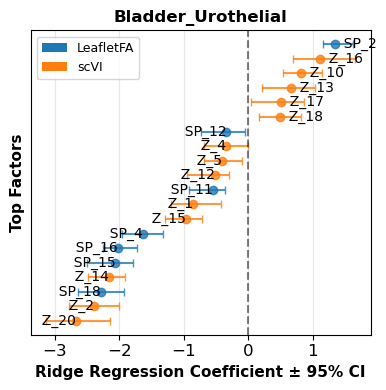

Saved file to /gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_Submission2025/Mouse_Splicing_Foundation/Figures/FIGURE4/figures/forest_plot_Pancreas_Islet.pdf


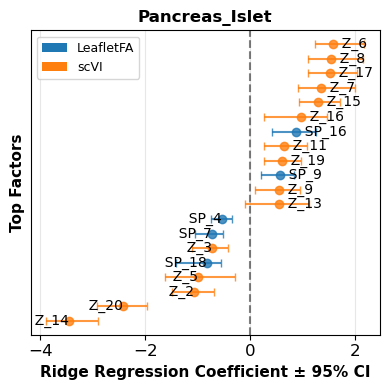

Saved file to /gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_Submission2025/Mouse_Splicing_Foundation/Figures/FIGURE4/figures/forest_plot_SCAT_T_Cell.pdf


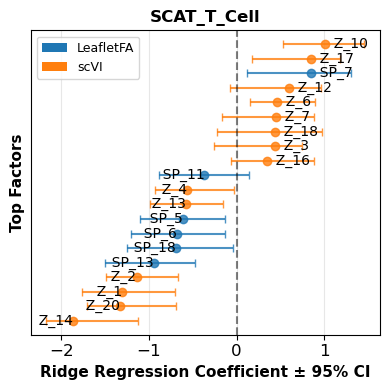

Saved file to /gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_Submission2025/Mouse_Splicing_Foundation/Figures/FIGURE4/figures/forest_plot_Brain_Microglia.pdf


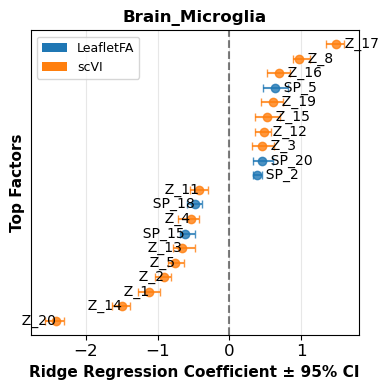

Saved file to /gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_Submission2025/Mouse_Splicing_Foundation/Figures/FIGURE4/figures/forest_plot_Thymus_BloodProg.pdf


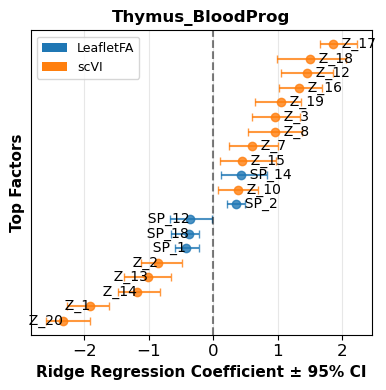

Saved file to /gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_Submission2025/Mouse_Splicing_Foundation/Figures/FIGURE4/figures/forest_plot_Kidney_RenalEpi.pdf


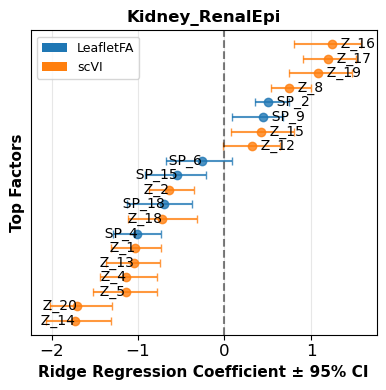

Saved file to /gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_Submission2025/Mouse_Splicing_Foundation/Figures/FIGURE4/figures/forest_plot_Spleen_B_Cell.pdf


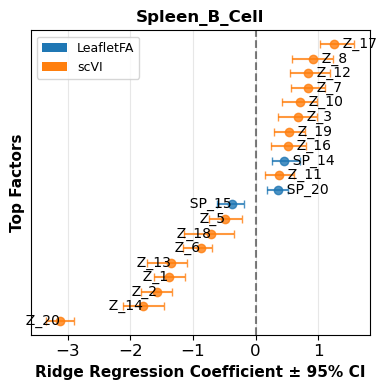

Saved file to /gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_Submission2025/Mouse_Splicing_Foundation/Figures/FIGURE4/figures/forest_plot_Muscle_Satellite.pdf


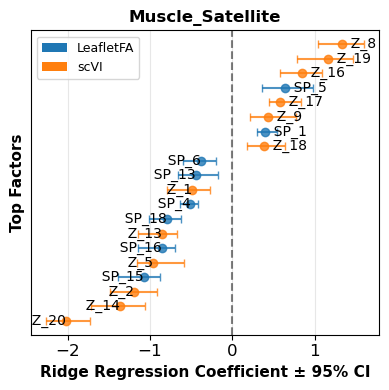

Saved file to /gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_Submission2025/Mouse_Splicing_Foundation/Figures/FIGURE4/figures/forest_plot_Spleen_T_Cell.pdf


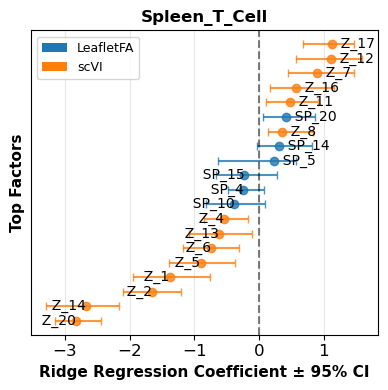

Saved file to /gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_Submission2025/Mouse_Splicing_Foundation/Figures/FIGURE4/figures/forest_plot_MAT_B_Cell.pdf


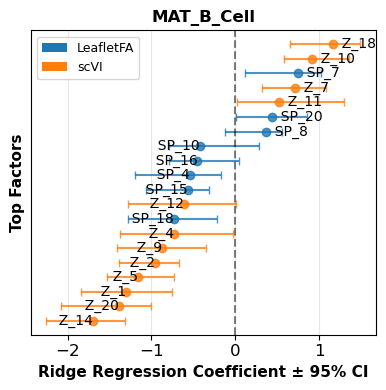

Saved file to /gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_Submission2025/Mouse_Splicing_Foundation/Figures/FIGURE4/figures/forest_plot_BAT_T_Cell.pdf


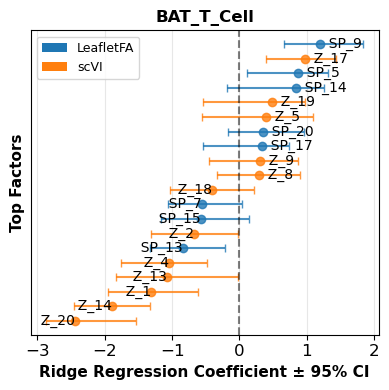

Saved file to /gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_Submission2025/Mouse_Splicing_Foundation/Figures/FIGURE4/figures/forest_plot_Tongue_Keratinocyte.pdf


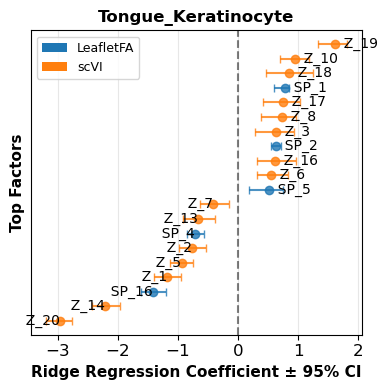

Saved file to /gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_Submission2025/Mouse_Splicing_Foundation/Figures/FIGURE4/figures/forest_plot_Liver_Hepatocyte.pdf


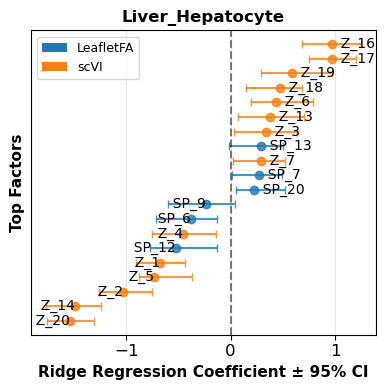

Saved file to /gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_Submission2025/Mouse_Splicing_Foundation/Figures/FIGURE4/figures/forest_plot_Brain_Pericyte.pdf


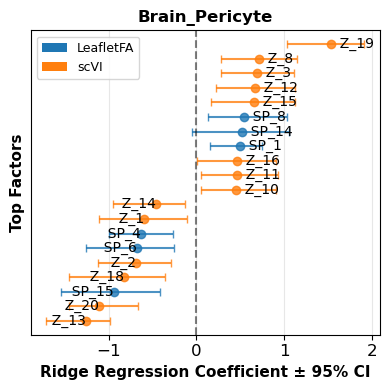

Saved file to /gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_Submission2025/Mouse_Splicing_Foundation/Figures/FIGURE4/figures/forest_plot_Diaphragm_Satellite.pdf


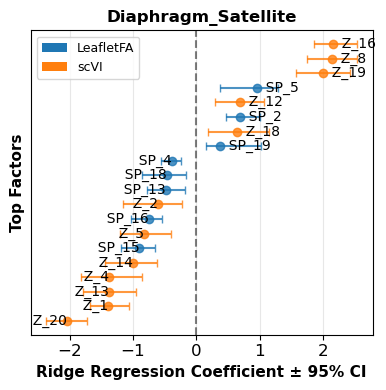

Saved file to /gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_Submission2025/Mouse_Splicing_Foundation/Figures/FIGURE4/figures/forest_plot_Heart_Fibroblast.pdf


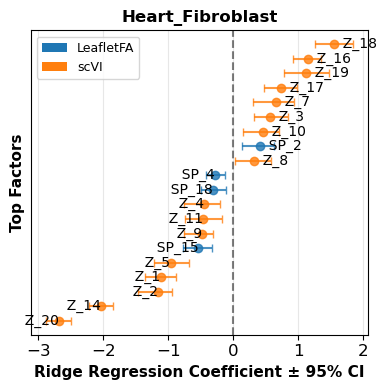

Saved file to /gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_Submission2025/Mouse_Splicing_Foundation/Figures/FIGURE4/figures/forest_plot_Marrow_B_Cell.pdf


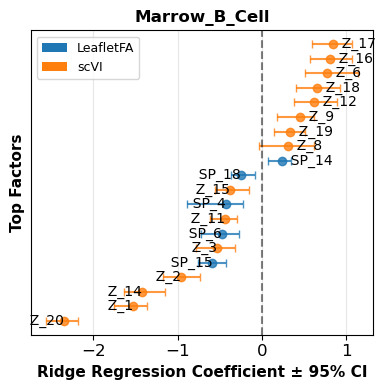

Saved file to /gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_Submission2025/Mouse_Splicing_Foundation/Figures/FIGURE4/figures/forest_plot_MAT_APC.pdf


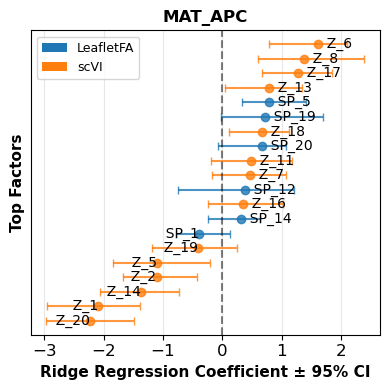

Saved file to /gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_Submission2025/Mouse_Splicing_Foundation/Figures/FIGURE4/figures/forest_plot_Marrow_HSC.pdf


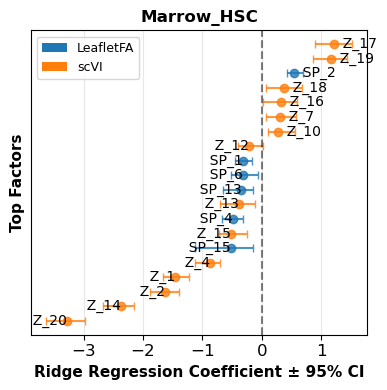

Saved file to /gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_Submission2025/Mouse_Splicing_Foundation/Figures/FIGURE4/figures/forest_plot_Brain_Astrocyte.pdf


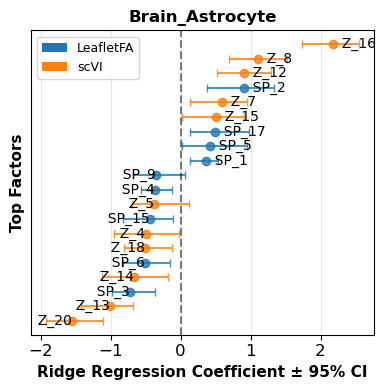

Saved file to /gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_Submission2025/Mouse_Splicing_Foundation/Figures/FIGURE4/figures/forest_plot_Kidney_VascEndo.pdf


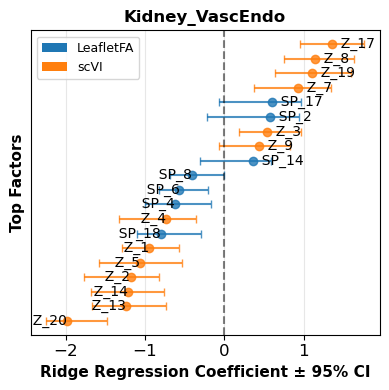

Saved file to /gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_Submission2025/Mouse_Splicing_Foundation/Figures/FIGURE4/figures/forest_plot_LI_Secretory.pdf


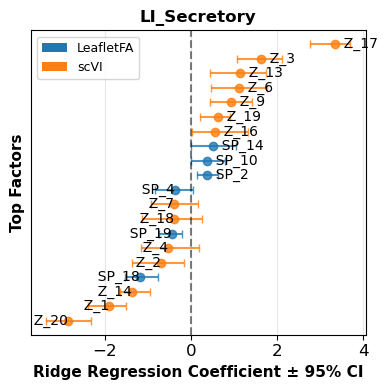

Saved file to /gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_Submission2025/Mouse_Splicing_Foundation/Figures/FIGURE4/figures/forest_plot_Trachea_Fibroblast.pdf


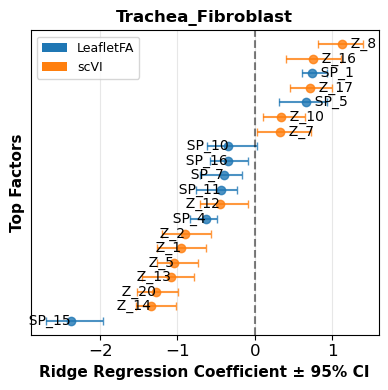

Saved file to /gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_Submission2025/Mouse_Splicing_Foundation/Figures/FIGURE4/figures/forest_plot_Brain_Oligo.pdf


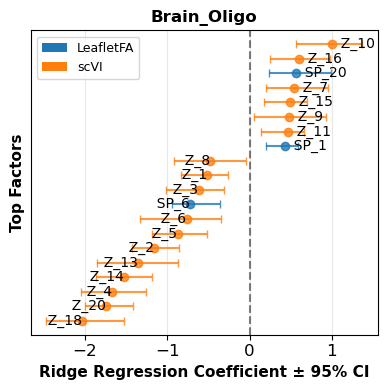

Saved file to /gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_Submission2025/Mouse_Splicing_Foundation/Figures/FIGURE4/figures/forest_plot_Heart_Myeloid.pdf


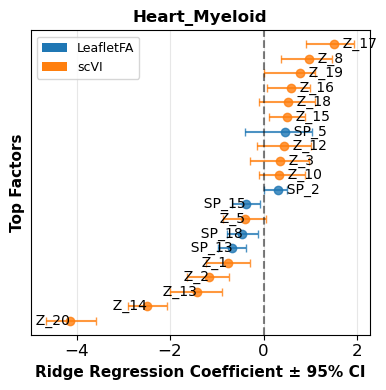

Saved file to /gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_Submission2025/Mouse_Splicing_Foundation/Figures/FIGURE4/figures/forest_plot_SCAT_MSC.pdf


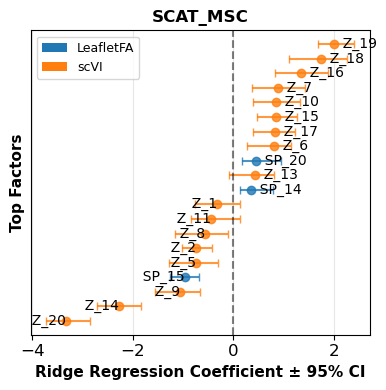

Saved file to /gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_Submission2025/Mouse_Splicing_Foundation/Figures/FIGURE4/figures/forest_plot_Lung_Vascular.pdf


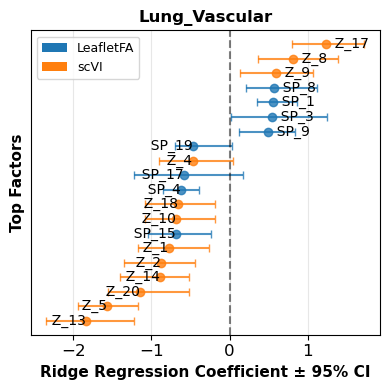

Saved file to /gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_Submission2025/Mouse_Splicing_Foundation/Figures/FIGURE4/figures/forest_plot_Brain_GliaProg.pdf


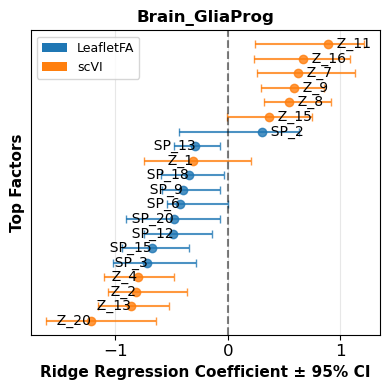

Saved file to /gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_Submission2025/Mouse_Splicing_Foundation/Figures/FIGURE4/figures/forest_plot_Aorta_Fibroblast.pdf


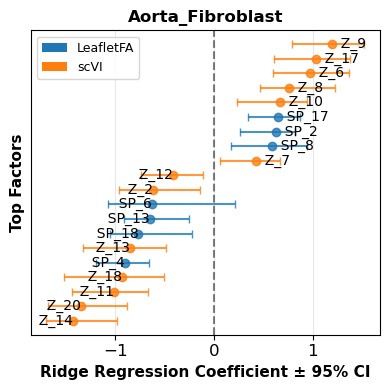

Saved file to /gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_Submission2025/Mouse_Splicing_Foundation/Figures/FIGURE4/figures/forest_plot_Thymus_T_Cell.pdf


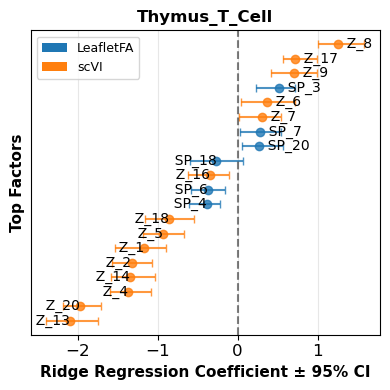

Saved file to /gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_Submission2025/Mouse_Splicing_Foundation/Figures/FIGURE4/figures/forest_plot_Brain_In-General.pdf


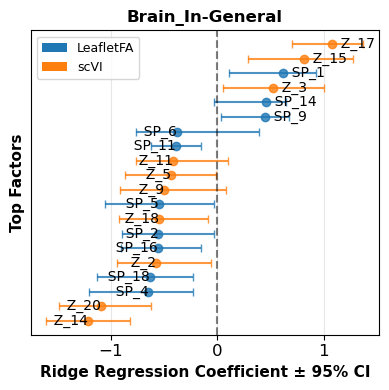

Saved file to /gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_Submission2025/Mouse_Splicing_Foundation/Figures/FIGURE4/figures/forest_plot_Marrow_APC.pdf


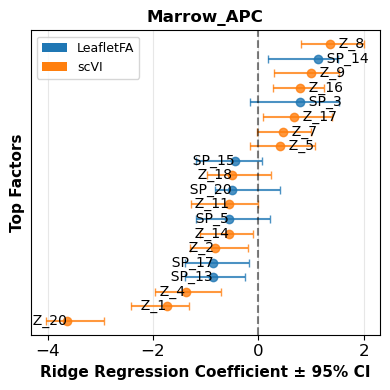

Saved file to /gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_Submission2025/Mouse_Splicing_Foundation/Figures/FIGURE4/figures/forest_plot_Liver_SinEndo.pdf


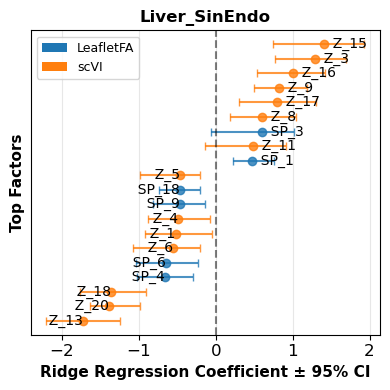

Saved file to /gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_Submission2025/Mouse_Splicing_Foundation/Figures/FIGURE4/figures/forest_plot_Lung_APC.pdf


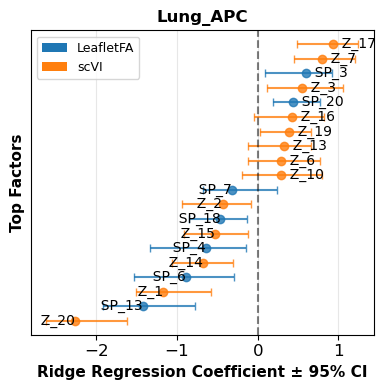

Saved file to /gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_Submission2025/Mouse_Splicing_Foundation/Figures/FIGURE4/figures/forest_plot_Brain_Neuron.pdf


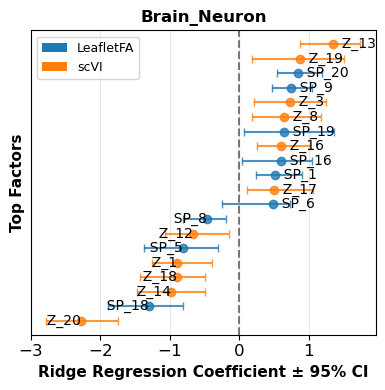

Saved file to /gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_Submission2025/Mouse_Splicing_Foundation/Figures/FIGURE4/figures/forest_plot_Marrow_NK.pdf


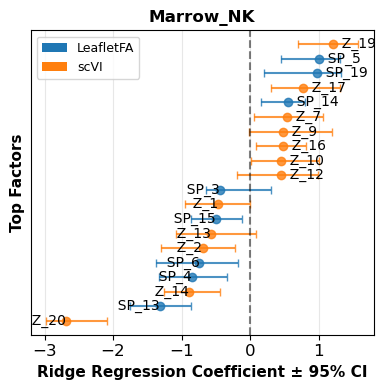

Saved file to /gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_Submission2025/Mouse_Splicing_Foundation/Figures/FIGURE4/figures/forest_plot_Marrow_T_Cell.pdf


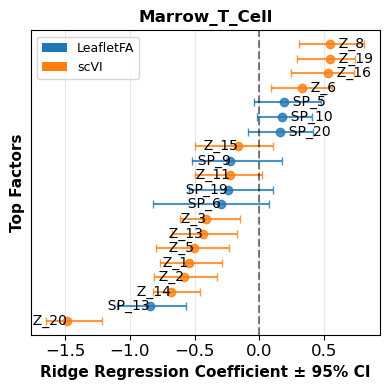

Saved file to /gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_Submission2025/Mouse_Splicing_Foundation/Figures/FIGURE4/figures/forest_plot_Lung_B_Cell.pdf


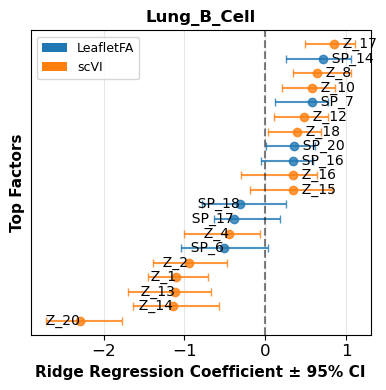

Saved file to /gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_Submission2025/Mouse_Splicing_Foundation/Figures/FIGURE4/figures/forest_plot_Trachea_T_Cell.pdf


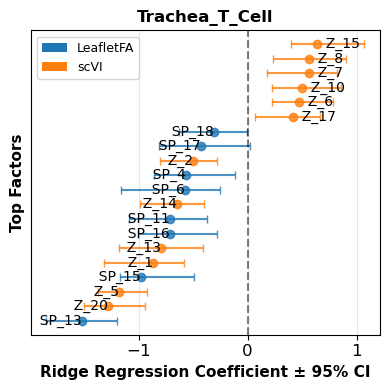

Saved file to /gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_Submission2025/Mouse_Splicing_Foundation/Figures/FIGURE4/figures/forest_plot_Pancreas_Acinar.pdf


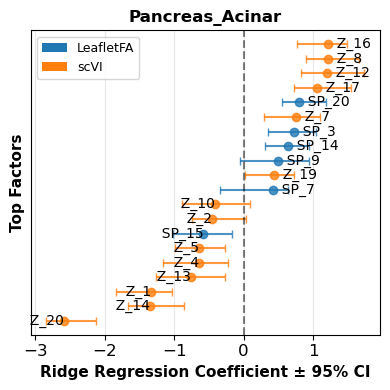

Saved file to /gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_Submission2025/Mouse_Splicing_Foundation/Figures/FIGURE4/figures/forest_plot_Lung_Myeloid.pdf


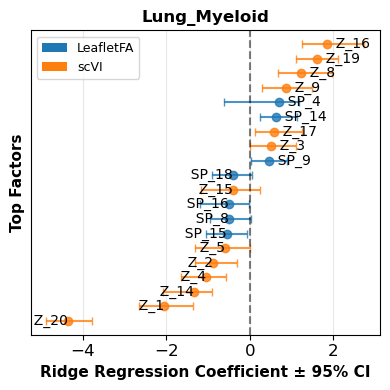

Saved file to /gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_Submission2025/Mouse_Splicing_Foundation/Figures/FIGURE4/figures/forest_plot_Trachea_APC.pdf


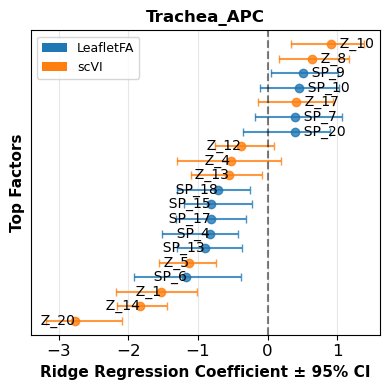

Saved file to /gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_Submission2025/Mouse_Splicing_Foundation/Figures/FIGURE4/figures/forest_plot_Muscle_MSC.pdf


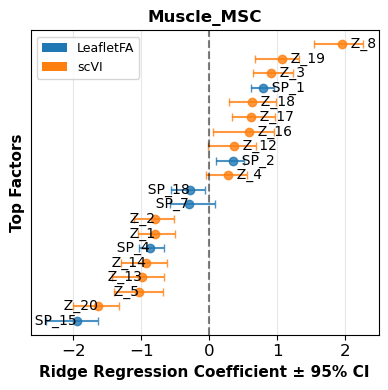

Saved file to /gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_Submission2025/Mouse_Splicing_Foundation/Figures/FIGURE4/figures/forest_plot_Aorta_VascEndo.pdf


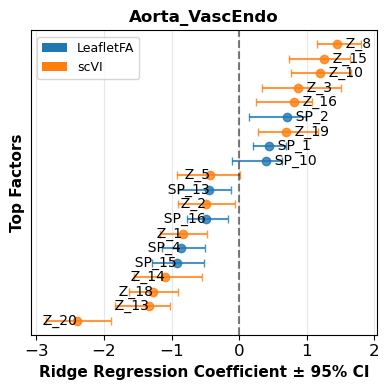

Saved file to /gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_Submission2025/Mouse_Splicing_Foundation/Figures/FIGURE4/figures/forest_plot_Diaphragm_MSC.pdf


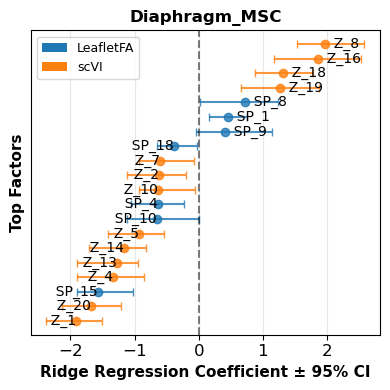

Saved file to /gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_Submission2025/Mouse_Splicing_Foundation/Figures/FIGURE4/figures/forest_plot_Pancreas_Endothelial.pdf


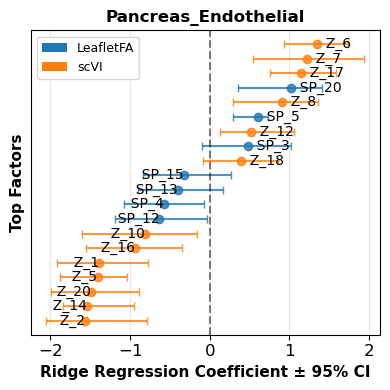

Saved file to /gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_Submission2025/Mouse_Splicing_Foundation/Figures/FIGURE4/figures/forest_plot_GAT_Endothelial.pdf


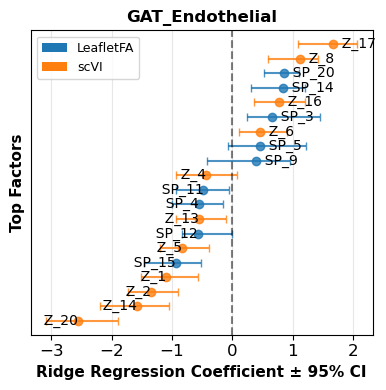

Saved file to /gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_Submission2025/Mouse_Splicing_Foundation/Figures/FIGURE4/figures/forest_plot_MAT_Endothelial.pdf


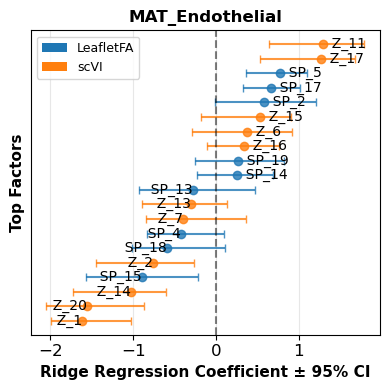

Saved file to /gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_Submission2025/Mouse_Splicing_Foundation/Figures/FIGURE4/figures/forest_plot_BAT_Endothelial.pdf


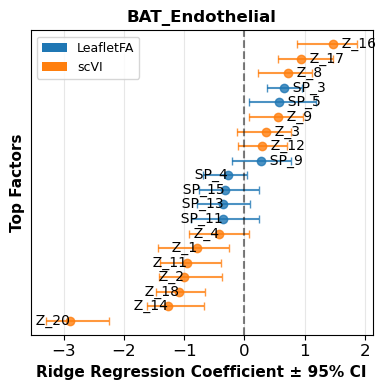

Saved file to /gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_Submission2025/Mouse_Splicing_Foundation/Figures/FIGURE4/figures/forest_plot_GAT_MSC.pdf


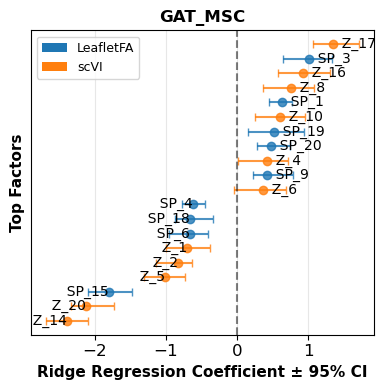

Saved file to /gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_Submission2025/Mouse_Splicing_Foundation/Figures/FIGURE4/figures/forest_plot_SCAT_Endothelial.pdf


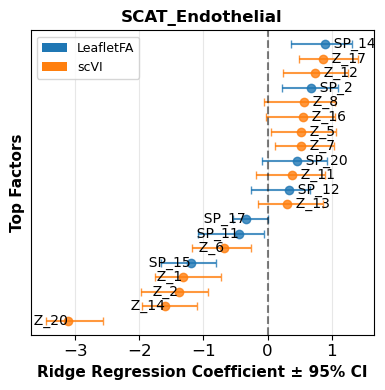

Saved file to /gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_Submission2025/Mouse_Splicing_Foundation/Figures/FIGURE4/figures/forest_plot_MAT_MSC.pdf


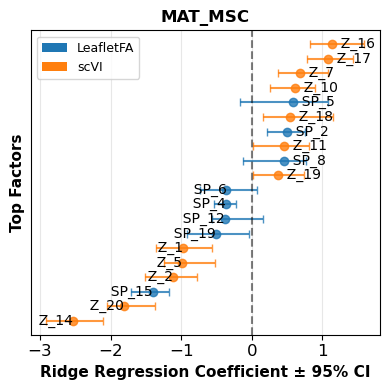

Saved file to /gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_Submission2025/Mouse_Splicing_Foundation/Figures/FIGURE4/figures/forest_plot_BAT_MSC.pdf


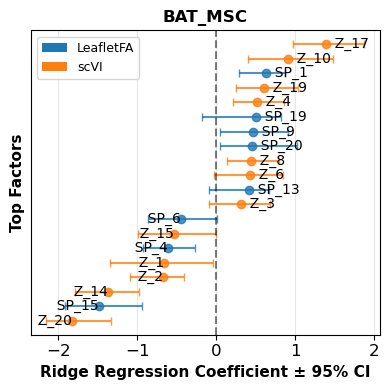

Saved file to /gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_Submission2025/Mouse_Splicing_Foundation/Figures/FIGURE4/figures/forest_plot_Muscle_Endothelial.pdf


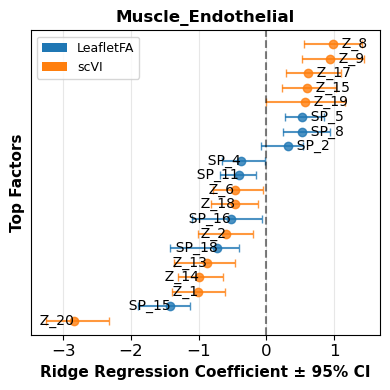

Saved file to /gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_Submission2025/Mouse_Splicing_Foundation/Figures/FIGURE4/figures/forest_plot_Lung_Pneumocyte.pdf


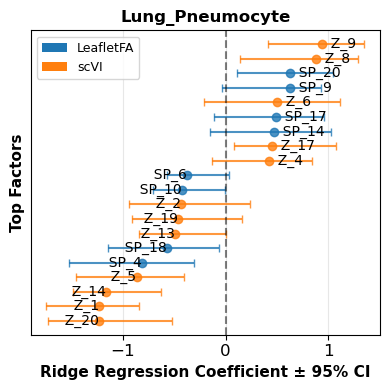

Saved file to /gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_Submission2025/Mouse_Splicing_Foundation/Figures/FIGURE4/figures/forest_plot_Muscle_B_Cell.pdf


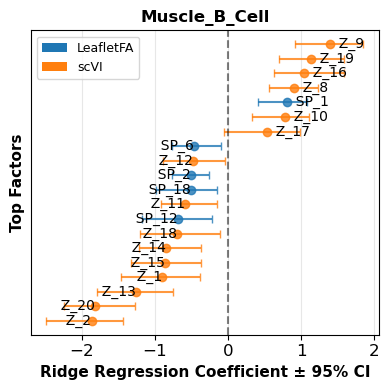

Saved file to /gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_Submission2025/Mouse_Splicing_Foundation/Figures/FIGURE4/figures/forest_plot_Diaphragm_Endothelial.pdf


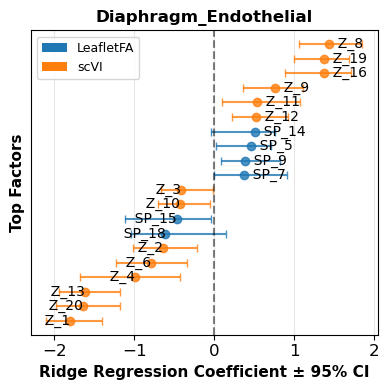

In [51]:
# Make forest plot for every cell type! 
for cell_type in splice_adata.obs["tissue_celltype"].unique():
    create_forest_plot_single_celltype(feature_df_ci, cell_type, output_dir, top_n_factors=20, figsize=(4, 4))

## Load LeafletFA SP junction markers 
Obtained from `/gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/NatureAging_PLOTTING_MOUSE/MOUSE_FIGURE_PLOTS.ipynb`

In [52]:
sj_markers = "/gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_Submission2025/Mouse_Splicing_Foundation/Figures/FIGURE3/figures/final_df.tsv.gz"
sj_markers_df = pd.read_csv(sj_markers, sep="\t")
# remove gene_name_y and rename gene_name_x to gene_name
sj_markers_df = sj_markers_df.drop(columns=["gene_name_y"])
sj_markers_df = sj_markers_df.rename(columns={"gene_name_x": "gene_name"})
sj_markers_df.head()

markers = sj_markers_df[["junction_id", "gene_name", "effect_size", "abs_effect_size", "junction_idx", "factor_idx"]].sort_values(by="abs_effect_size", ascending=False)
# find junctions for factor 4 
top_100 = markers[markers["factor_idx"] == 3].head(n=100)
# find genes with multiple junctions 
top_100[top_100["gene_name"].isin(top_100["gene_name"].value_counts()[top_100["gene_name"].value_counts() > 1].index)]

,junction_id,gene_name,effect_size,abs_effect_size,junction_idx,factor_idx
239773,chr1_132605585_132608382_-,NFASC,0.952713,0.952713,29467,3
239786,chr1_132637091_132642677_-,NFASC,0.911522,0.911522,29480,3
216842,chr11_54335125_54337070_+,ACSL6,0.896733,0.896733,6536,3
216844,chr11_54337148_54338411_+,ACSL6,0.889758,0.889758,6538,3
259551,chr5_146455661_146465849_+,WASF3,0.878828,0.878828,49245,3
240573,chr1_162019992_162084032_-,DNM3,0.860554,0.860554,30267,3
225267,chr14_30913193_30914048_-,ITIH3,0.857149,0.857149,14961,3
214465,chr11_105325903_105327971_+,MRC2,0.853744,0.853744,4159,3
230528,chr16_29475628_29479755_-,ATP13A4,0.841980,0.841980,20222,3
216840,chr11_54315207_54320151_+,ACSL6,0.838408,0.838408,6534,3


In [53]:
# Set style
plt.style.use('default')

# Define the important factors and their age associations
important_factors = [0, 1, 3, 5]  # SP_1, SP_2, SP_4, SP_6

# Age association direction for each factor (from your feature_df_ci)
age_associations = {
    0: 'positive',   # SP_1: positive coefficient = more active in older cells
    1: 'positive',   # SP_2: negative coefficient = more active in younger cells  
    3: 'negative',   # SP_4: negative coefficient = more active in younger cells
    5: 'negative'    # SP_6: positive coefficient = more active in older cells
}

# Filter for significant junctions
filtered_df = sj_markers_df[
    (sj_markers_df["factor_idx"].isin(important_factors)) & 
    (sj_markers_df["significant"]) & 
    (sj_markers_df["abs_effect_size"] > 0.25)
].copy()

In [54]:
filtered_df["factor_idx"].value_counts()

factor_idx
1    16525
0    16122
3    14934
5     8127
Name: count, dtype: int64

In [55]:
# Get top N junctions per factor
top_n_per_factor = 10
top_junctions = []
for factor in important_factors:
    factor_data = filtered_df[filtered_df["factor_idx"] == factor]
    if len(factor_data) > 0:
        top_factor_junctions = factor_data.nlargest(top_n_per_factor, 'abs_effect_size')
        top_junctions.append(top_factor_junctions)

plot_data = pd.concat(top_junctions, ignore_index=True)

In [56]:
# Create junction labels
plot_data['junction_label'] = plot_data['junction_id'].str.replace('_', ':', 1).str.replace('_', '-', 1).str.replace('_', '(', 1) + ')'

# Check which junctions appear across more than one factor
junction_counts = plot_data['junction_label'].value_counts()
multiple_factors = junction_counts[junction_counts > 1]
print(f"Junctions appearing in multiple factors: {len(multiple_factors)}")

Junctions appearing in multiple factors: 0


Plot saved to /gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_Submission2025/Mouse_Splicing_Foundation/Figures/FIGURE4/figures/sj_markers_aging_effect_size.pdf


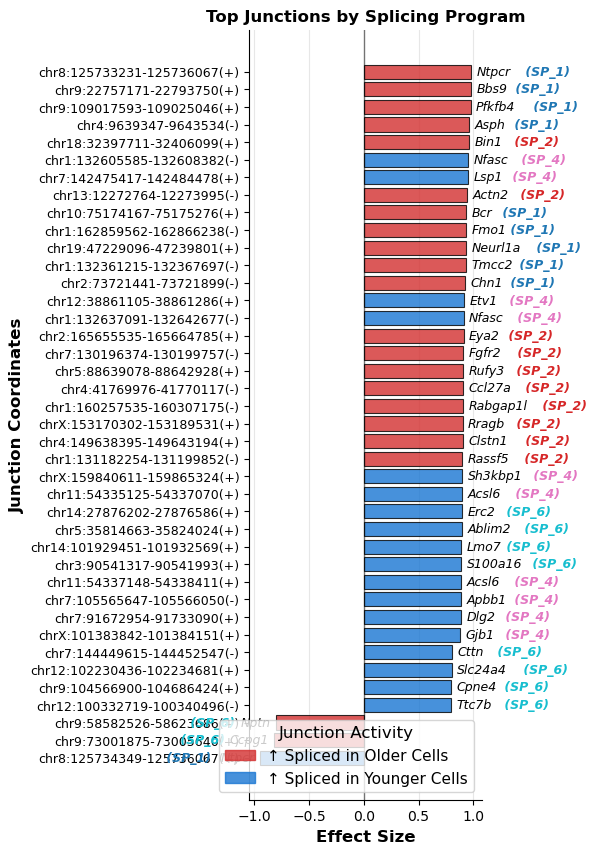

In [57]:
import matplotlib

# Create interpretable effect direction
plot_data['age_direction'] = plot_data.apply(lambda row: 
    'Older' if (age_associations[row['factor_idx']] == 'positive' and row['effect_size'] > 0) or 
              (age_associations[row['factor_idx']] == 'negative' and row['effect_size'] < 0)
    else 'Younger', axis=1)

# Create factor labels with age direction
plot_data['sp_label'] = 'SP_' + (plot_data['factor_idx'] + 1).astype(str)

# Define colors based on age direction instead of just factor
plot_data['color'] = plot_data['age_direction'].map({
    'Older': '#d32f2f',    # Red for increased splicing in older cells
    'Younger': '#1976d2'   # Blue for increased splicing in younger cells
})

# Create the plot
plt.figure(figsize=(3, 10))

# Sort by effect size
plot_data_sorted = plot_data.sort_values('effect_size', ascending=True)

# Create barplot
bars = plt.barh(range(len(plot_data_sorted)), plot_data_sorted['effect_size'], 
                color=plot_data_sorted['color'], 
                alpha=0.8, edgecolor='black', linewidth=0.8)

# Customize labels
plt.yticks(range(len(plot_data_sorted)), 
           plot_data_sorted['junction_label'],
           fontsize=9)

plt.xlabel('Effect Size', fontsize=12, fontweight='bold')
plt.ylabel('Junction Coordinates', fontsize=12, fontweight='bold')
plt.title('Top Junctions by Splicing Program', 
          fontsize=12, fontweight='bold')

# Add vertical line at x=0
plt.axvline(x=0, color='black', linestyle='-', alpha=0.5, linewidth=1)


# Dynamically assign SP colors based on the number of unique factors in plot_data_sorted

unique_factor_idxs = sorted(plot_data_sorted['factor_idx'].unique())
num_factors = len(unique_factor_idxs)
# Use a matplotlib tab10 or tab20 colormap for distinct colors
cmap = matplotlib.cm.get_cmap('tab10' if num_factors <= 10 else 'tab20', num_factors)
sp_text_colors = {factor_idx: matplotlib.colors.rgb2hex(cmap(i)) for i, factor_idx in enumerate(unique_factor_idxs)}

for i, (bar, row) in enumerate(zip(bars, plot_data_sorted.itertuples())):
    width = bar.get_width()
    
    # Get raw gene name
    raw_gene_name = getattr(row, 'gene_name_y', getattr(row, 'gene_name', 'Unknown'))
    
    # FIX: Convert to string, capitalize (Mouse style: Gfap, Apoe), and handle 'Unknown'
    gene_name = str(raw_gene_name).capitalize()
    
    sp_label = f"SP_{getattr(row, 'factor_idx')+1}"
    factor_idx = getattr(row, 'factor_idx')

    # Position logic
    # If bar is positive, text goes to the right; if negative, to the left
    ha_val = 'left' if width >= 0 else 'right'
    x_pos = width + (0.05 if width >= 0 else -0.05) # Subtle padding

    # Create the label with gene name (Italicized and Mouse-formatted)
    plt.text(x_pos, bar.get_y() + bar.get_height()/2,
             gene_name, ha=ha_val,
             va='center', fontsize=9, style='italic', color='black')

    # Add SP label in color (Bold and Italicized)
    # We use a small offset based on the length of the capitalized gene name
    sp_x_offset = len(gene_name) * 0.08  # Adjusted multiplier for better spacing
    sp_x_pos = x_pos + (sp_x_offset if width >= 0 else -sp_x_offset)

    plt.text(sp_x_pos, bar.get_y() + bar.get_height()/2,
             f' ({sp_label})', ha=ha_val,
             va='center', fontsize=9, style='italic',
             color=sp_text_colors.get(factor_idx, 'black'), fontweight='bold')

# Create age-direction legend
legend_elements = [
    plt.Rectangle((0,0),1,1, color='#d32f2f', alpha=0.8, label='↑ Spliced in Older Cells'),
    plt.Rectangle((0,0),1,1, color='#1976d2', alpha=0.8, label='↑ Spliced in Younger Cells')
]
plt.legend(handles=legend_elements, title='Junction Activity', title_fontsize=12, fontsize=11, 
           loc='lower right')

# Grid and styling
plt.grid(True, alpha=0.3, axis='x')
plt.gca().set_axisbelow(True)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(f"{output_dir}/sj_markers_aging_effect_size.pdf", dpi=300, bbox_inches='tight')
# print where plot was saved 
print(f"Plot saved to {output_dir}/sj_markers_aging_effect_size.pdf")
plt.show()

In [58]:
sj_markers_df

,factor_idx,junction_idx,effect_size,abs_effect_size,effect_size_var,num_greater,prob_greater,prob_lessoreq,significant,delta,...,donor_usage,acceptor_usage,donor_total_reads,acceptor_total_reads,splice_motif_y,donor_seq,acceptor_seq,position_off_5_prime_y,position_off_3_prime_y,junction_annotation
0,0,0,0.159471,0.159471,0.000192,0.0,0.0,1.0,False,0.25,...,0.9938,0.9758,208143,211996,GT-AG,GT,AG,0.0,1.0,Both_SS_annotated
1,0,1,-0.019480,0.019480,0.000039,0.0,0.0,1.0,False,0.25,...,0.0236,1.0000,211996,5002,GT-AG,GT,AG,0.0,1.0,Both_SS_annotated
2,0,2,0.089473,0.089473,0.002858,0.0,0.0,1.0,False,0.25,...,0.6454,1.0000,307509,198469,GT-AG,GT,AG,0.0,1.0,Both_SS_annotated
3,0,3,0.039674,0.039674,0.001106,0.0,0.0,1.0,False,0.25,...,0.3518,0.3736,307509,289522,GT-AG,GT,AG,0.0,1.0,Both_SS_annotated
4,0,4,0.117123,0.117123,0.002422,0.0,0.0,1.0,False,0.25,...,1.0000,0.6229,180342,289522,GT-AG,GT,AG,0.0,1.0,Both_SS_annotated
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1402035,19,70097,-0.432247,0.432247,0.000170,100.0,1.0,0.0,True,0.25,...,0.9896,0.9913,12644,12622,GT-AG,GT,AG,0.0,1.0,Both_SS_annotated
1402036,19,70098,-0.454091,0.454091,0.000181,100.0,1.0,0.0,True,0.25,...,0.9836,1.0000,10019,9855,GT-AG,GT,AG,0.0,1.0,Both_SS_annotated
1402037,19,70099,-0.015128,0.015128,0.000009,0.0,0.0,1.0,False,0.25,...,0.0164,1.0000,10019,164,GT-AG,GT,AG,0.0,NaN,5_prime_annotated
1402038,19,70100,-0.444459,0.444459,0.000150,100.0,1.0,0.0,True,0.25,...,1.0000,0.9871,13870,14051,GT-AG,GT,AG,0.0,1.0,Both_SS_annotated


In [59]:
splice_adata

AnnData object with n_obs × n_vars = 80557 × 70102
    obs: 'cell_id_index', 'age', 'donor_id', 'sex', 'subtissue', 'cell_name', 'cell_id', 'cell_clean', 'specific_cell_type', 'medium_cell_type', 'seqtech', 'library_size', 'total_junction_reads', 'annotated_junction_reads', 'unannotated_junction_reads', 'n_detected_annotated_junctions', 'n_detected_unannotated_junctions', 'age_numeric', 'age_group', 'cell_ontology_class', 'broad_cell_type', 'tissue', 'tissue_celltype', 'dataset', 'total_counts', 'GAG_score', 'SP_1', 'SP_2', 'SP_3', 'SP_4', 'SP_5', 'SP_6', 'SP_7', 'SP_8', 'SP_9', 'SP_10', 'SP_11', 'SP_12', 'SP_13', 'SP_14', 'SP_15', 'SP_16', 'SP_17', 'SP_18', 'SP_19', 'SP_20', 'perplexity'
    var: 'index', 'junction_id', 'event_id', 'splice_motif', 'annotation_status', 'gene_name', 'gene_id', 'num_junctions', 'position_off_5_prime', 'position_off_3_prime', 'CountJuncs', 'junction_id_index', 'n_cells_detected', 'confidence', 'aging_gene', 'aging_lifespan_effect', 'aging_longevity_influe

<Axes: >

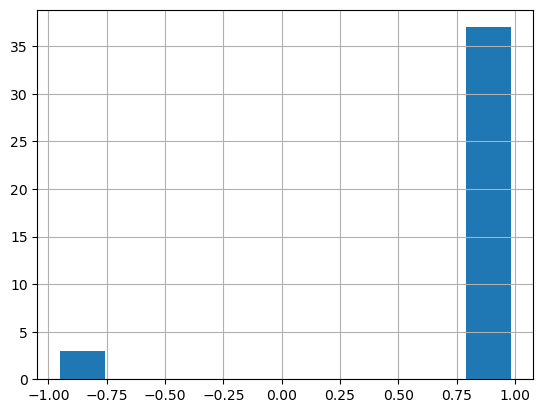

In [60]:
plot_data["effect_size"].hist()

In [61]:
splicing_aging

AnnData object with n_obs × n_vars = 80557 × 70102
    obs: 'cell_id_index', 'age', 'donor_id', 'sex', 'subtissue', 'cell_name', 'cell_id', 'cell_clean', 'specific_cell_type', 'medium_cell_type', 'seqtech', 'library_size', 'total_junction_reads', 'annotated_junction_reads', 'unannotated_junction_reads', 'n_detected_annotated_junctions', 'n_detected_unannotated_junctions', 'age_numeric', 'age_group', 'cell_ontology_class', 'broad_cell_type', 'tissue', 'tissue_celltype', 'dataset', 'total_counts', 'GAG_score', 'SP_1', 'SP_2', 'SP_3', 'SP_4', 'SP_5', 'SP_6', 'SP_7', 'SP_8', 'SP_9', 'SP_10', 'SP_11', 'SP_12', 'SP_13', 'SP_14', 'SP_15', 'SP_16', 'SP_17', 'SP_18', 'SP_19', 'SP_20', 'perplexity'
    var: 'index', 'junction_id', 'event_id', 'splice_motif', 'annotation_status', 'gene_name', 'gene_id', 'num_junctions', 'position_off_5_prime', 'position_off_3_prime', 'CountJuncs', 'junction_id_index', 'n_cells_detected', 'confidence', 'aging_gene', 'aging_lifespan_effect', 'aging_longevity_influe

In [62]:
splicing_aging.layers["denoised_PSI"] = splicing_aging.obsm["X_PHI"] @ splicing_aging.varm["psi_learned"].T

In [63]:
def plot_psi_by_age_violin(splice_adata, junction_idx, OUTPUT_DIR=None, figsize=(4, 4)):
    """
    Create a violin plot showing denoised PSI values by age for a single junction
    """
        
    # Get denoised PSI data and age
    junction_psi = splice_adata.layers["denoised_PSI"][:, junction_idx]  # All cells for this junction
    ages = splice_adata.obs["age_numeric"].values
    junction_id = splice_adata.var["junction_id"].values[junction_idx]

    # Create dataframe for plotting
    plot_df = pd.DataFrame({
        'PSI': junction_psi,
        'Age': ages
    })
    
    # Remove any NaN values
    plot_df = plot_df.dropna()
    
    # Create the plot
    plt.figure(figsize=figsize)
    
    # Create violin plot with age as continuous variable
    sns.violinplot(data=plot_df, x='Age', y='PSI', 
                  color='#1976d2', alpha=0.7)
    
    # Customize plot
    title = f'Junction {junction_id}'
    plt.title(title, fontsize=11, fontweight='bold')
    plt.xlabel('Age (Months)', fontsize=11, fontweight='bold')
    plt.ylabel('Denoised Junction \nUsage Ratio', fontsize=11, fontweight='bold')

    # Increase tick font size 
    plt.tick_params(axis='both', which='major', labelsize=12)
    
    # Add grid
    plt.grid(True, alpha=0.3)
    plt.gca().set_axisbelow(True)
    
    plt.tight_layout()
    if OUTPUT_DIR:
        plt.savefig(f"{OUTPUT_DIR}/psi_by_age_violin_{junction_id}.pdf", dpi=300, bbox_inches='tight')
        print(f"Plot saved to {OUTPUT_DIR}/psi_by_age_violin_{junction_id}.pdf")
    plt.show()

In [64]:
plot_data[plot_data["factor_idx"] == 1]

,factor_idx,junction_idx,effect_size,abs_effect_size,effect_size_var,num_greater,prob_greater,prob_lessoreq,significant,delta,...,splice_motif_y,donor_seq,acceptor_seq,position_off_5_prime_y,position_off_3_prime_y,junction_annotation,junction_label,age_direction,sp_label,color
10,1,25579,0.963354,0.963354,0.000047,100.0,1.0,0.0,True,0.25,...,GT-AG,GT,AG,NaN,1.0,3_prime_annotated,chr18:32397711-32406099(+),Older,SP_2,#d32f2f
11,1,12284,0.943330,0.943330,0.000281,100.0,1.0,0.0,True,0.25,...,GT-AG,GT,AG,NaN,0.0,3_prime_annotated,chr13:12272764-12273995(-),Older,SP_2,#d32f2f
12,1,35908,0.911043,0.911043,0.000144,100.0,1.0,0.0,True,0.25,...,GT-AG,GT,AG,NaN,1.0,3_prime_annotated,chr2:165655535-165664785(+),Older,SP_2,#d32f2f
13,1,56281,0.909456,0.909456,0.000199,100.0,1.0,0.0,True,0.25,...,GT-AG,GT,AG,1.0,0.0,Both_SS_annotated,chr7:130196374-130199757(-),Older,SP_2,#d32f2f
14,1,51276,0.906837,0.906837,0.000215,100.0,1.0,0.0,True,0.25,...,GT-AG,GT,AG,0.0,1.0,Both_SS_annotated,chr5:88639078-88642928(+),Older,SP_2,#d32f2f
15,1,45643,0.903428,0.903428,0.000076,100.0,1.0,0.0,True,0.25,...,GT-AG,GT,AG,NaN,0.0,3_prime_annotated,chr4:41769976-41770117(-),Older,SP_2,#d32f2f
16,1,30202,0.903249,0.903249,0.000068,100.0,1.0,0.0,True,0.25,...,GT-AG,GT,AG,NaN,0.0,3_prime_annotated,chr1:160257535-160307175(-),Older,SP_2,#d32f2f
17,1,68749,0.902295,0.902295,0.000647,100.0,1.0,0.0,True,0.25,...,GT-AG,GT,AG,0.0,NaN,5_prime_annotated,chrX:153170302-153189531(+),Older,SP_2,#d32f2f
18,1,44742,0.901758,0.901758,0.000179,100.0,1.0,0.0,True,0.25,...,GT-AG,GT,AG,0.0,1.0,Both_SS_annotated,chr4:149638395-149643194(+),Older,SP_2,#d32f2f
19,1,29351,0.900807,0.900807,0.000066,100.0,1.0,0.0,True,0.25,...,GT-AG,GT,AG,1.0,0.0,Both_SS_annotated,chr1:131182254-131199852(-),Older,SP_2,#d32f2f


In [65]:
splicing_aging.var[splicing_aging.var["event_id"] == "ENSMUSG00000039953.13_atse_2"][["junction_id_index", "junction_id"]]

,junction_id_index,junction_id
57232,44741,chr4_149638395_149641657_+
57233,44742,chr4_149638395_149643194_+
57234,44743,chr4_149641714_149643194_+


In [66]:
splicing_aging.var[splicing_aging.var["junction_id_index"] == 44742]

,index,junction_id,event_id,splice_motif,annotation_status,gene_name,gene_id,num_junctions,position_off_5_prime,position_off_3_prime,CountJuncs,junction_id_index,n_cells_detected,confidence,aging_gene,aging_lifespan_effect,aging_longevity_influence,RBP_gene,Aging_gene
57233,72660,chr4_149638395_149643194_+,ENSMUSG00000039953.13_atse_2,GT-AG,both,CLSTN1,ENSMUSG00000039953,3,0.0,1.0,25918,44742,2781,high,False,NaN,NaN,False,False


In [67]:
# ── Cell counts for Figure 4 legend ──────────────────────────────────────
# Panel F: all cells by age
print("Panel F – all cells per age:")
print(splicing_aging.obs["age_numeric"].value_counts().sort_index().to_string())
print()

# Panel G: Bladder Urothelial cells by age
bladder = splicing_aging[splicing_aging.obs["tissue_celltype"] == "Bladder_Urothelial"]
print("Panel G – Bladder Urothelial cells per age:")
print(bladder.obs["age_numeric"].value_counts().sort_index().to_string())


Panel F – all cells per age:
age_numeric
2       252
3     30262
18    25078
24    24965

Panel G – Bladder Urothelial cells per age:
age_numeric
3     492
18    639
24    398


In [98]:
splicing_aging[splicing_aging.obs["tissue_celltype"] == "Bladder_Urothelial"].obs["age"].value_counts()

age
18m    639
3m     492
24m    398
Name: count, dtype: int64

Plot saved to /gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_Submission2025/Mouse_Splicing_Foundation/Figures/FIGURE4/figures/psi_by_age_violin_chr4_149638395_149643194_+.pdf


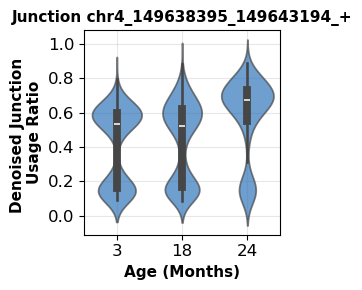

In [68]:
plot_psi_by_age_violin(splicing_aging[splicing_aging.obs["tissue_celltype"] == "Bladder_Urothelial"], junction_idx=44742, OUTPUT_DIR=output_dir, figsize=(3, 3))

Plot saved to /gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_Submission2025/Mouse_Splicing_Foundation/Figures/FIGURE4/figures/psi_by_age_violin_chr4_149638395_149643194_+.pdf


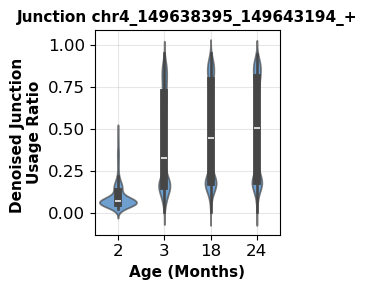

In [69]:
plot_psi_by_age_violin(splicing_aging, junction_idx=44742, OUTPUT_DIR=output_dir, figsize=(3, 3))

In [70]:
feature_importance_df[feature_importance_df["factor_name"] == "SP_3"].sort_values(by="coefficient", ascending=False)

,cell_type,factor_type,factor_name,coefficient,abs_coefficient,combined_r2,p_vs_scvi
2722,GAT_MSC,Splicing,SP_3,1.017253,1.017253,0.696807,1.110223e-16
2002,Marrow_APC,Splicing,SP_3,0.787062,0.787062,0.532529,1.142272e-02
2322,Pancreas_Acinar,Splicing,SP_3,0.724854,0.724854,0.413860,1.752615e-02
2602,GAT_Endothelial,Splicing,SP_3,0.660297,0.660297,0.700484,5.433421e-04
2682,BAT_Endothelial,Splicing,SP_3,0.650021,0.650021,0.524299,9.821949e-01
...,...,...,...,...,...,...,...
2122,Brain_Neuron,Splicing,SP_3,-0.416532,0.416532,0.489905,1.157851e-02
2162,Marrow_NK,Splicing,SP_3,-0.437857,0.437857,0.609421,6.799828e-06
1842,Brain_GliaProg,Splicing,SP_3,-0.713656,0.713656,0.574585,1.130114e-01
1522,Brain_Astrocyte,Splicing,SP_3,-0.720901,0.720901,0.547210,1.286295e-06


## RBP analysis FIgure 4 !

In [71]:
feature_importance_df

,cell_type,factor_type,factor_name,coefficient,abs_coefficient,combined_r2,p_vs_scvi
0,Trachea_Epithelial,Splicing,SP_1,0.549265,0.549265,0.396454,0.694834
1,Trachea_Epithelial,Splicing,SP_2,-0.423479,0.423479,0.396454,0.694834
2,Trachea_Epithelial,Splicing,SP_3,0.320273,0.320273,0.396454,0.694834
3,Trachea_Epithelial,Splicing,SP_4,-0.244587,0.244587,0.396454,0.694834
4,Trachea_Epithelial,Splicing,SP_5,0.127024,0.127024,0.396454,0.694834
...,...,...,...,...,...,...,...
3035,Diaphragm_Endothelial,Gene_Expression,Z_16,1.367422,1.367422,0.753051,0.912810
3036,Diaphragm_Endothelial,Gene_Expression,Z_17,0.114010,0.114010,0.753051,0.912810
3037,Diaphragm_Endothelial,Gene_Expression,Z_18,0.161775,0.161775,0.753051,0.912810
3038,Diaphragm_Endothelial,Gene_Expression,Z_19,1.370871,1.370871,0.753051,0.912810


In [72]:
assert all(ge_adata_aging.obs_names == splicing_aging.obs_names)

In [73]:
ge_adata_aging.layers["scVI_linear"] = ge_adata_aging.obsm["X_normalized_scVI_linear"]

### Running RBP expression vs SP1, SP2 and age correlation

In [74]:
# 2. Get overlapping cell types between SP1 and SP2
# sp1_cell_types = set(SP1_cells['cell_type'].values)
# sp2_cell_types = set(SP2_cells['cell_type'].values)
# overlapping_cell_types = list(sp1_cell_types & sp2_cell_types)
# print(f"\nOverlapping cell types: length {len(overlapping_cell_types)}")
# print(overlapping_cell_types)

# 1. Extract RBP genes and their expression
print("Extracting RBP genes...")
rbp_genes = ge_adata_aging.var[ge_adata_aging.var['is_rbp']].index.tolist()
print(f"Found {len(rbp_genes)} RBP genes")

# 3. Ensure all SP scores (SP_1 to SP_20) are in ge_adata_aging
for sp_num in range(1, 21):
    col_name = f'SP_{sp_num}'
    if col_name not in ge_adata_aging.obs.columns:
        if col_name in splicing_aging.obs.columns:
            ge_adata_aging.obs.loc[:, col_name] = splicing_aging.obs.loc[:, col_name]

Extracting RBP genes...
Found 269 RBP genes


In [75]:
from statsmodels.stats.multitest import multipletests
import pingouin as pg

def simple_mediation_analysis(ge_adata_aging, rbp_genes, cell_type, sp_names, n_boot=500):
    """Simple mediation analysis for one cell type, allowing arbitrary SP column names."""
    
    # Subset to cell type
    mask = ge_adata_aging.obs["tissue_celltype"] == cell_type
    ct = ge_adata_aging[mask].copy()
    print(f"{cell_type}: {ct.n_obs} cells")
    
    # Get available RBPs
    available_rbps = [rbp for rbp in rbp_genes if rbp in ct.var_names]
    print(f"Testing {len(available_rbps)} RBPs")
    
    # Run mediation for all RBPs and all SPs
    results = []
    for rbp in tqdm(available_rbps):
        # Get RBP expression
        rbp_expr = np.asarray(ct[:, rbp].layers["scVI_linear"]).ravel()
        
        # Build dataframe: Age, RBP expr, all SPs
        df_dict = {
            "Age": ct.obs["age_numeric"].values,
            "RBP_expr": rbp_expr,
        }
        for sp_col in sp_names:
            df_dict[sp_col] = ct.obs[sp_col].values
        
        df = pd.DataFrame(df_dict)
        
        # Test each outcome (SP)
        for outcome in sp_names:
            d = df[["Age", "RBP_expr", outcome]].dropna().rename(columns={outcome: "Y"})
            try:
                res = pg.mediation_analysis(data=d, x="Age", m="RBP_expr", y="Y", n_boot=n_boot, seed=42)
                res["RBP"] = rbp
                res["Outcome"] = outcome
                res["CellType"] = cell_type
                results.append(res)
            except Exception as e:
                continue
    
    # Combine results
    if not results:
        return pd.DataFrame()
        
    all_results = pd.concat(results, ignore_index=True)
    print(all_results.head)
    
    # FDR correction for indirect effects only
    indirect = all_results[all_results['path'] == 'Indirect'].copy()
    if not indirect.empty:
        _, pvals_corrected, _, _ = multipletests(indirect['pval'], method='fdr_bh')
        indirect['pval_fdr'] = pvals_corrected
    else:
        indirect['pval_fdr'] = []
    
    # Get significant mediations
    indirect['effect_size'] = np.abs(indirect['coef'])
    indirect = indirect.sort_values('effect_size', ascending=False)
    
    return indirect

# Usage:
# Specify the SPs to test (will accept any length of vector)
sp_names = [col for col in ge_adata_aging.obs.columns if col.startswith("SP_")]

#all_res = []
#for cell_type in tqdm(ge_adata_aging.obs["tissue_celltype"].unique()):
#    results = simple_mediation_analysis(ge_adata_aging, rbp_genes, cell_type, sp_names, n_boot=10)
#    all_res.append(results)

In [76]:
# Save all_res to file
#all_res_df = pd.concat(all_res, ignore_index=True)
#all_res_df.to_csv(os.path.join(output_dir, "all_RBP_SP_mediation_results.csv.gz"), index=False, compression="gzip")

In [77]:
all_res_df = pd.read_csv(os.path.join(output_dir, "all_RBP_SP_mediation_results.csv.gz"))

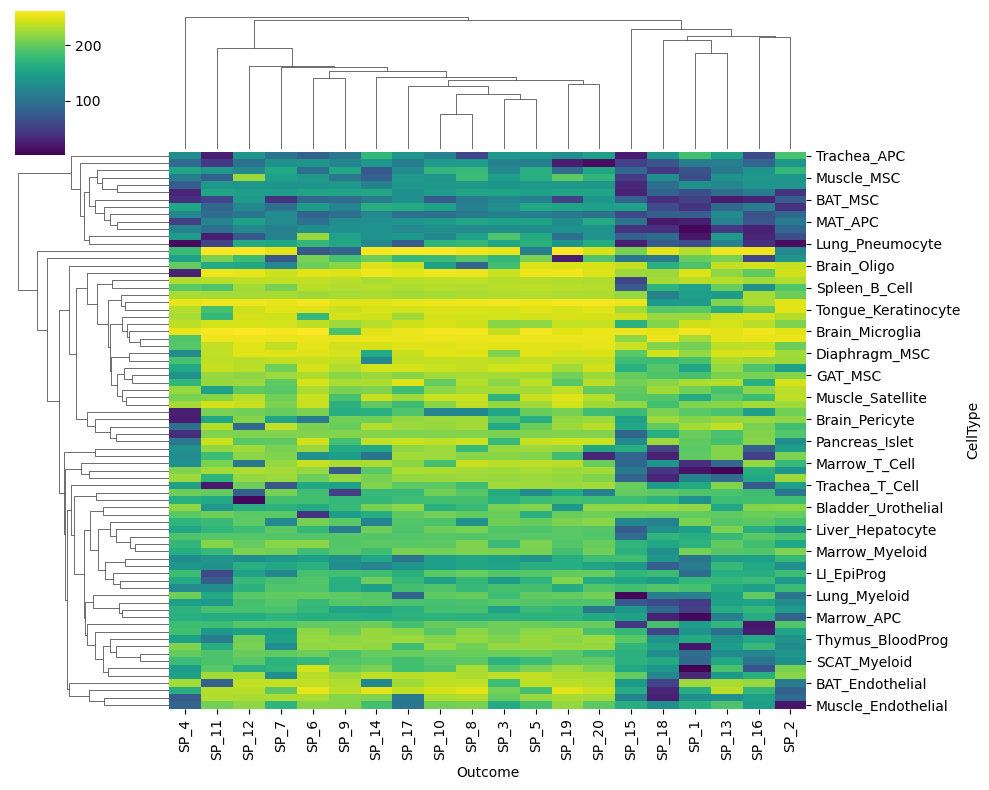

In [78]:
#  Summarize significant RBPs by cell type and Outcome 
significant_rbps = all_res_df[all_res_df["sig"] == "Yes"]
# Count how many RBPs are significant for each cell type and Outcome
rbp_counts = significant_rbps.groupby(["CellType", "Outcome"])["RBP"].count().reset_index()
rbp_counts
# Plot heatmap of cell types by RBPs pivot 
# Plot heatmap of cell types by RBPs pivot 
rbp_counts_pivot = rbp_counts.pivot(index="CellType", columns="Outcome", values="RBP")
sns.clustermap(rbp_counts_pivot, cmap="viridis", figsize=(10, 8))

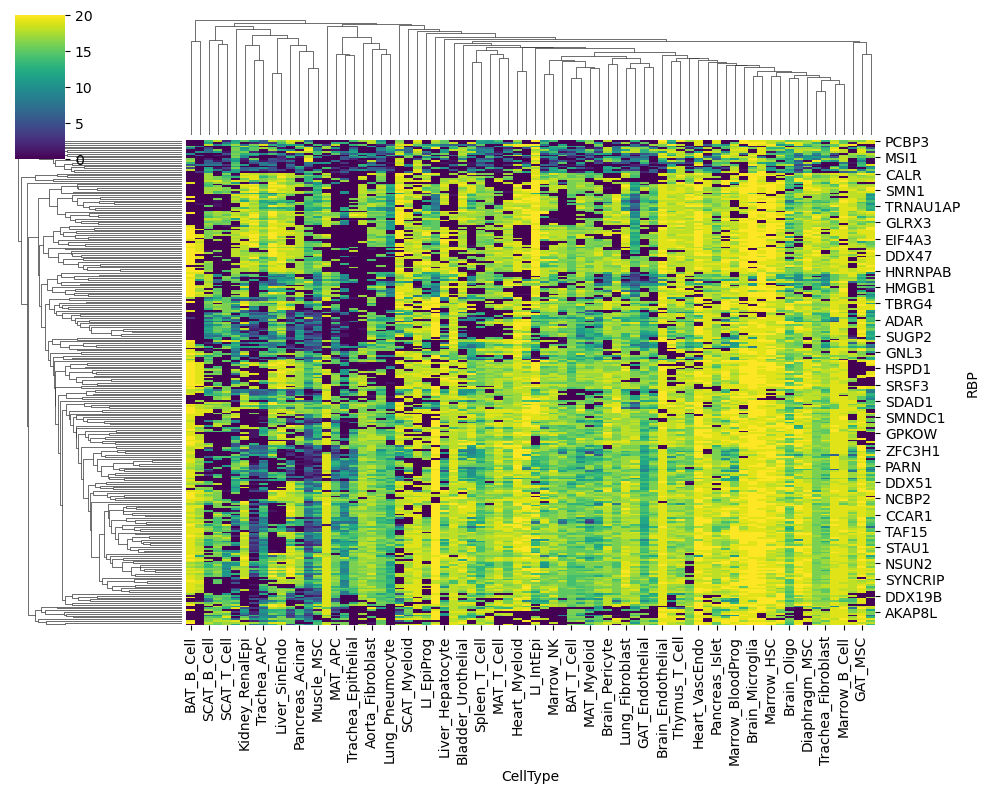

In [79]:
# now lets do the same by have RBPs versus cell types and count SPs
SP_counts = significant_rbps.groupby(["RBP", "CellType"])["Outcome"].count().reset_index()
SP_counts
SP_counts_pivot = SP_counts.pivot(index="RBP", columns="CellType", values="Outcome")
# replace nan with 0
SP_counts_pivot = SP_counts_pivot.fillna(0)
sns.clustermap(SP_counts_pivot, cmap="viridis", figsize=(10, 8))

In [80]:
# Significant SPdiff hits
sig_hits = (
    all_res_df
    .query("path == 'Indirect' and pval_fdr < 0.05")
    .copy()
)

# Top 5 per cell type
top_per_cell = (
    sig_hits
    .sort_values(["CellType", "effect_size"], ascending=[True, False])
    .groupby("CellType")
    .head(30)
)

top_per_cell

,path,coef,se,pval,CI[2.5%],CI[97.5%],sig,RBP,Outcome,CellType,pval_fdr,effect_size
252860,Indirect,-0.010877,0.001525,0.0,-0.011623,-0.008745,Yes,RECQL5,SP_2,Aorta_Fibroblast,0.0,0.010877
252861,Indirect,0.006940,0.001224,0.0,0.005007,0.008096,Yes,RECQL5,SP_4,Aorta_Fibroblast,0.0,0.006940
252862,Indirect,-0.005747,0.002253,0.0,-0.009445,-0.003979,Yes,RCC2,SP_2,Aorta_Fibroblast,0.0,0.005747
252863,Indirect,0.005692,0.001950,0.0,0.003143,0.008630,Yes,ADAR,SP_4,Aorta_Fibroblast,0.0,0.005692
252864,Indirect,-0.005634,0.001419,0.0,-0.008119,-0.004230,Yes,ADAR,SP_2,Aorta_Fibroblast,0.0,0.005634
...,...,...,...,...,...,...,...,...,...,...,...,...
306692,Indirect,-0.001531,0.000727,0.0,-0.002359,-0.000444,Yes,WRN,SP_2,Trachea_T_Cell,0.0,0.001531
306693,Indirect,0.001528,0.000344,0.0,0.001313,0.002174,Yes,METAP2,SP_1,Trachea_T_Cell,0.0,0.001528
306695,Indirect,-0.001520,0.000828,0.0,-0.002927,-0.000477,Yes,SAFB,SP_2,Trachea_T_Cell,0.0,0.001520
306696,Indirect,-0.001504,0.000594,0.0,-0.002422,-0.001006,Yes,DDX27,SP_2,Trachea_T_Cell,0.0,0.001504


In [81]:
# Keep only these RBPs & cell types in the full results
rbps_keep = top_per_cell["RBP"].unique()
cell_types_keep = ["Bladder_Urothelial", "Heart_Muscle"] #top_per_cell["CellType"].unique()

subset_df = top_per_cell[
    top_per_cell["RBP"].isin(rbps_keep) &
    top_per_cell["CellType"].isin(cell_types_keep) &
    (top_per_cell["path"] == "Indirect")
].copy()

subset_df.reset_index(drop=True)

,path,coef,se,pval,CI[2.5%],CI[97.5%],sig,RBP,Outcome,CellType,pval_fdr,effect_size
0,Indirect,0.006659,0.000621,0.0,0.005928,0.007291,Yes,RALY,SP_2,Bladder_Urothelial,0.0,0.006659
1,Indirect,0.006209,0.000467,0.0,0.005700,0.006946,Yes,U2AF1,SP_2,Bladder_Urothelial,0.0,0.006209
2,Indirect,-0.006069,0.000711,0.0,-0.006676,-0.004985,Yes,FASTKD2,SP_2,Bladder_Urothelial,0.0,0.006069
3,Indirect,0.005819,0.000797,0.0,0.004704,0.006772,Yes,SERBP1,SP_2,Bladder_Urothelial,0.0,0.005819
4,Indirect,0.005685,0.000660,0.0,0.004639,0.006130,Yes,UCHL5,SP_2,Bladder_Urothelial,0.0,0.005685
5,Indirect,0.005649,0.000362,0.0,0.005176,0.006166,Yes,SNRNP70,SP_2,Bladder_Urothelial,0.0,0.005649
6,Indirect,0.005633,0.000773,0.0,0.004423,0.006566,Yes,RPLP0,SP_2,Bladder_Urothelial,0.0,0.005633
7,Indirect,0.005556,0.000717,0.0,0.004596,0.006290,Yes,DNAJC21,SP_2,Bladder_Urothelial,0.0,0.005556
8,Indirect,0.005553,0.000442,0.0,0.004774,0.006027,Yes,MBNL1,SP_2,Bladder_Urothelial,0.0,0.005553
9,Indirect,0.005487,0.000368,0.0,0.004917,0.006031,Yes,EXOSC5,SP_2,Bladder_Urothelial,0.0,0.005487


In [82]:
idx = subset_df.groupby(['RBP', 'CellType'])['coef'].transform(lambda x: x.abs() == x.abs().max())
subset_max = subset_df[idx].copy()

# Handle rare ties by dropping duplicates
subset_max = subset_max.drop_duplicates(subset=['RBP', 'CellType'])

In [83]:
# Pivot to RBP × CellType matrix (effect size or coef)
heatmap_df = subset_max.pivot(index="RBP", columns="CellType", values="coef").fillna(0)
print(f"The number of RBPs is {heatmap_df.shape[0]} and the number of cell types is {heatmap_df.shape[1]}")

The number of RBPs is 55 and the number of cell types is 2


In [84]:
# Choose value column
value_col = "coef" if "coef" in subset_max.columns else "effect_size"

# Collapse to one row per (RBP, CellType): take the row with the smallest FDR
pair_df = (
    subset_max.sort_values("pval_fdr")
             .drop_duplicates(["RBP", "CellType"])
)

# Values for heatmap
heatmap_df = (
    pair_df.pivot(index="RBP", columns="CellType", values=value_col)
           .fillna(0)
)

# Significance mask (FDR<0.05)
sig_mask = (
    (pair_df.assign(sig=lambda d: d["pval_fdr"] < 0.05))
    .pivot(index="RBP", columns="CellType", values="sig")
    .fillna(False)
)

# Ensure same index/columns in both
sig_mask = sig_mask.reindex(index=heatmap_df.index, columns=heatmap_df.columns, fill_value=False)

RBP_SPdiff_mediation.pdf saved to /gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_Submission2025/Mouse_Splicing_Foundation/Figures/FIGURE4/figures/RBP_SPdiff_mediation.pdf


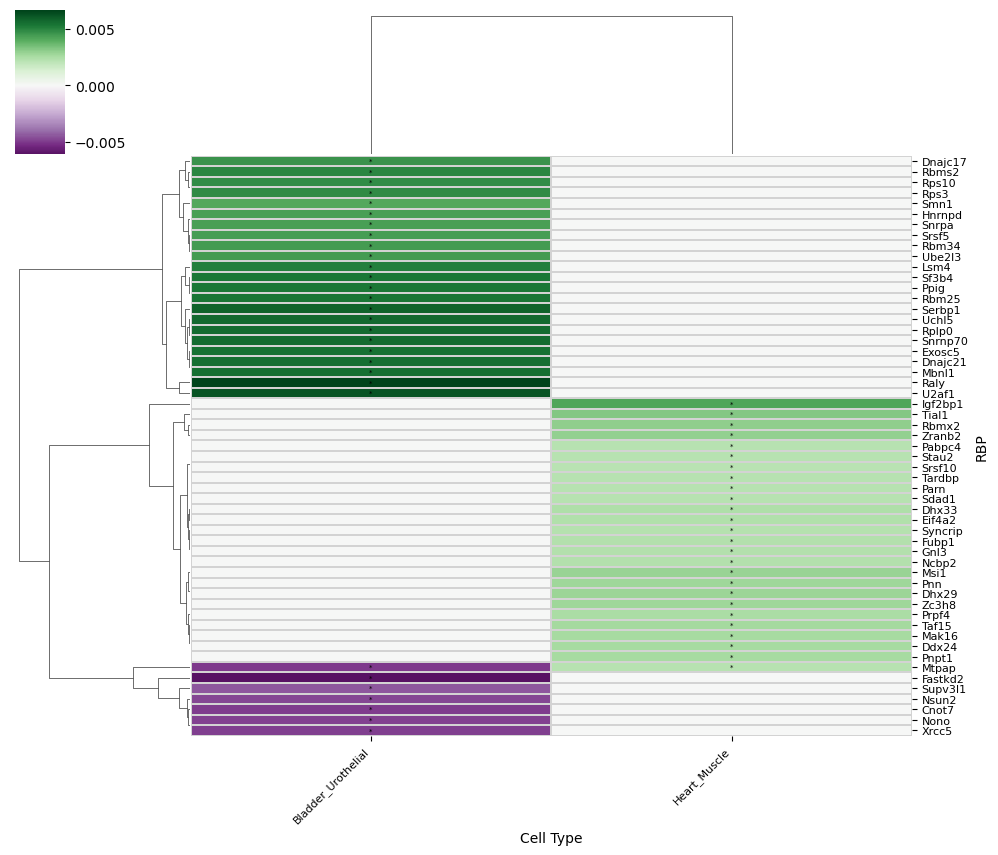

In [85]:
# --- 0) Reformat gene names to mouse style ---
heatmap_df.index = [name.capitalize() for name in heatmap_df.index]
sig_mask.index   = [name.capitalize() for name in sig_mask.index]

# --- 3) Plot with row_colors ---
figsize = (10, 8)
g = sns.clustermap(
    data=heatmap_df,
    cmap="PRGn",
    center=0,
    row_cluster=True,
    col_cluster=True,
    linewidths=0.15,
    linecolor="lightgray",
    xticklabels=True,
    yticklabels=True,
    figsize=figsize
)

# Axis labels
g.ax_heatmap.set_xlabel("Cell Type", fontsize=10)
g.ax_heatmap.set_ylabel("RBP", fontsize=10)

# Rotate/align x labels cleanly
for lbl in g.ax_heatmap.get_xticklabels():
    lbl.set_rotation(45)
    lbl.set_horizontalalignment('right')
    lbl.set_fontsize(8)
g.ax_heatmap.tick_params(axis='y', labelsize=8)

# Stars for FDR<0.05
row_order = [heatmap_df.index[i]   for i in g.dendrogram_row.reordered_ind]
col_order = [heatmap_df.columns[i] for i in g.dendrogram_col.reordered_ind]
for i, rbp in enumerate(row_order):
    for j, ct in enumerate(col_order):
        if sig_mask.loc[rbp, ct]:
            g.ax_heatmap.text(j + 0.5, i + 0.5, "*",
                              ha="center", va="center",
                              fontsize=5, color="black", clip_on=True)

# Legend for the row color strip
from matplotlib.patches import Patch

# --- 4) Save figure ---
plt.savefig(f"{output_dir}/RBP_SPdiff_mediation.pdf", bbox_inches='tight')
print(f"RBP_SPdiff_mediation.pdf saved to {output_dir}/RBP_SPdiff_mediation.pdf")

plt.show()

In [86]:
all_res_df[all_res_df["RBP"] == "RALY"].sort_values(by="coef", ascending=False)

,path,coef,se,pval,CI[2.5%],CI[97.5%],sig,RBP,Outcome,CellType,pval_fdr,effect_size
102220,Indirect,0.006659,0.000621,0.0,0.005928,0.007291,Yes,RALY,SP_2,Bladder_Urothelial,0.0,0.006659
333561,Indirect,0.005338,0.000561,0.0,0.004863,0.006010,Yes,RALY,SP_1,Aorta_VascEndo,0.0,0.005338
322803,Indirect,0.003228,0.000786,0.0,0.002313,0.004683,Yes,RALY,SP_2,Trachea_APC,0.0,0.003228
48430,Indirect,0.002298,0.000382,0.0,0.001498,0.002564,Yes,RALY,SP_1,Lung_Fibroblast,0.0,0.002298
26928,Indirect,0.002274,0.000283,0.0,0.001877,0.002657,Yes,RALY,SP_1,Brain_Endothelial,0.0,0.002274
...,...,...,...,...,...,...,...,...,...,...,...,...
322838,Indirect,-0.002320,0.000665,0.0,-0.003154,-0.001458,Yes,RALY,SP_1,Trachea_APC,0.0,0.002320
96886,Indirect,-0.002541,0.000757,0.0,-0.003399,-0.001475,Yes,RALY,SP_2,BAT_Myeloid,0.0,0.002541
102291,Indirect,-0.003097,0.000342,0.0,-0.003548,-0.002565,Yes,RALY,SP_4,Bladder_Urothelial,0.0,0.003097
333585,Indirect,-0.003103,0.000585,0.0,-0.003965,-0.002541,Yes,RALY,SP_4,Aorta_VascEndo,0.0,0.003103


In [87]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

def plot_mediation_landscape_simple(
    mediation_results,
    ge_adata_aging,
    cell_type,
    save_dir,
    effect_threshold=1e-4,
    top_labels=8,
    point_size=28,
    add_quadrant_labels=True,
):
    """
    Scatter for one cell type:
      x-axis: SPdiff mediation coefficient (Indirect path)
              (>0: aging-promoting; <0: youth-protective)
      y-axis: Spearman corr(RBP expression, age)
              (>0: RBP up with age; <0: RBP down with age)
    Color: SPdiff mediation coefficient (diverging, centered at 0)
    Saves PDF to <save_dir>/<cell_type>_RBP_landscape.pdf
    """
    # --- filter to SPdiff, indirect path, this cell type ---
    ct = mediation_results.query(
        "CellType == @cell_type and path == 'Indirect' and Outcome == 'SPdiff'"
    ).copy()
    if ct.empty:
        print(f"No SPdiff indirect rows for {cell_type}.")
        return pd.DataFrame()

    # one row per (RBP, CellType): keep smallest FDR (or pval)
    if "pval_fdr" in ct.columns:
        ct = (ct.sort_values("pval_fdr")
                .drop_duplicates(["RBP", "CellType"], keep="first"))
    else:
        ct = (ct.sort_values("pval")
                .drop_duplicates(["RBP", "CellType"], keep="first"))

    # --- compute RBP–age Spearman correlations in this cell type ---
    mask = ge_adata_aging.obs["medium_cell_type"] == cell_type
    if mask.sum() < 50:
        print(f"Too few cells for {cell_type}: {mask.sum()}")
        return pd.DataFrame()

    ages = ge_adata_aging.obs.loc[mask, "age_numeric"].astype(float).values
    rbps = [rbp for rbp in ct["RBP"].unique() if rbp in ge_adata_aging.var_names]
    if not rbps:
        print(f"No RBPs from mediation present in ge_adata_aging for {cell_type}.")
        return pd.DataFrame()

    age_corr = {}
    for rbp in rbps:
        try:
            expr = np.asarray(ge_adata_aging[mask, rbp].layers["scVI_linear"]).ravel()
        except Exception:
            expr = np.asarray(ge_adata_aging[mask, rbp].X).ravel()
        if np.std(expr) == 0 or np.isnan(expr).any():
            continue
        rho, _ = spearmanr(expr, ages)
        age_corr[rbp] = rho
    if not age_corr:
        print(f"No valid age correlations computed for {cell_type}.")
        return pd.DataFrame()

    # --- assemble plotting frame ---
    P = (
        ct.set_index("RBP")[["coef"]]
          .rename(columns={"coef": "med_coef"})
          .join(pd.Series(age_corr, name="age_corr"), how="inner")
          .dropna()
    )
    P = P.loc[P["med_coef"].abs() > effect_threshold]
    if P.empty:
        print(f"No RBPs pass |SPdiff coef| > {effect_threshold} in {cell_type}.")
        return P

    # --- plot ---
    fig, ax = plt.subplots(figsize=(4, 3))

    vmax = float(np.nanmax(np.abs(P["med_coef"])))
    sc = ax.scatter(
        P["med_coef"], P["age_corr"],
        c=P["med_coef"], cmap="PRGn", vmin=-vmax, vmax=vmax,
        s=point_size, edgecolors="black", linewidths=0.1, alpha=0.9
    )

    # axes crosshairs
    ax.axhline(0, color="black", ls="--", lw=0.6, alpha=0.5)
    ax.axvline(0, color="black", ls="--", lw=0.6, alpha=0.5)

    ax.set_xlabel("SPdiff mediation coefficient", fontsize=10)
    ax.set_ylabel("Spearman corr(RBP expression, age)", fontsize=10)
    ax.set_title(f"RBP:landscape:{cell_type}", fontsize=5, pad=6)

    for lbl in ax.get_xticklabels():
        lbl.set_rotation(45)
    ax.tick_params(axis="both", labelsize=11)

    # colorbar
    cbar = plt.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("Mediation coef", fontsize=6)
    cbar.ax.tick_params(labelsize=7)

    # label top points by |coef|
    for rbp in P["med_coef"].abs().nlargest(min(top_labels, len(P))).index:
        ax.annotate(
            rbp, (P.at[rbp, "med_coef"], P.at[rbp, "age_corr"]),
            xytext=(5, 3), textcoords="offset points",
            fontsize=6, 
            bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.7)
        )

    # --- quadrant annotations (axes-relative, no unpack bug) ---
    if add_quadrant_labels:
        pos = {
            "Q1": (0.78, 0.88),  # x>0,y>0
            "Q2": (0.12, 0.88),  # x<0,y>0
            "Q3": (0.12, 0.12),  # x<0,y<0
            "Q4": (0.78, 0.12),  # x>0,y<0
        }
        qtext = {
            "Q1": "Aging-promoter\n↑ with age",
            "Q2": "Youth-protective\n↑ with age",
            "Q3": "Youth-protective\n↓ with age",
            "Q4": "Aging-promoter\n↓ with age",
        }
        for q, label in qtext.items():
            x, y = pos[q]
            ax.text(
                x, y, label,
                transform=ax.transAxes,
                ha="center", va="center",
                fontsize=7,
                bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.6, ec="none"),
            )

    plt.tight_layout()

    # --- save as PDF ---
    os.makedirs(save_dir, exist_ok=True)
    pdf_path = os.path.join(save_dir, f"{cell_type}_RBP_landscape.pdf")
    # replace any spaces with underscores
    pdf_path = pdf_path.replace(" ", "_")
    plt.savefig(pdf_path, bbox_inches="tight")
    print(f"Saved: {pdf_path}")
    plt.show()
    return P

In [88]:
all_res_df["RBP"] = all_res_df["RBP"].str.capitalize()

In [89]:
ge_adata_aging.var["mouse_gene_name"] = ge_adata_aging.var["index"]
ge_adata_aging.var_names = ge_adata_aging.var["mouse_gene_name"]
ge_adata_aging

AnnData object with n_obs × n_vars = 80557 × 10572
    obs: 'cell_id', 'age', 'cell_ontology_class', 'mouse.id', 'sex', 'tissue', 'dataset', 'batch', 'subtissue_clean', 'broad_cell_type', 'cell_id_index', 'specific_cell_type', 'medium_cell_type', 'cell_name', 'library_size', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'total_counts_is_rRNA', 'log1p_total_counts_is_rRNA', 'pct_counts_is_rRNA', '_scvi_batch', '_scvi_labels', 'leiden_scVI', 'GAG_score', 'tissue_celltype', 'age_numeric', 'SP_1', 'SP_2', 'SP_3', 'SP_4', 'SP_5', 'SP_6', 'SP_7', 'SP_8', 'SP_9', 'SP_10', 'SP_11', 'SP_12', 'SP_13', 'SP_14', 'SP_15', 'SP_16', 'SP_17', 'SP_18', 'SP_19', 'SP_20'
    var: 'index', 'gene_name', 'gene_id', 'mean_transcript_length', 'mean_intron_length', 'num_transcripts', 'gene_biotype', 'is_rRNA', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'RBP_gene', 'Aging_gene', 'is_hvg', 'is_rbp

### Mediation already calcualted for Sp1-Ps2 ~ RBP ~ Age so here can just simply plot SP1-SP2 activity versus RBP expression... 

In [90]:
all_res_df

,path,coef,se,pval,CI[2.5%],CI[97.5%],sig,RBP,Outcome,CellType,pval_fdr,effect_size
0,Indirect,2.382016e-03,6.768175e-04,0.0,1.393310e-03,3.274705e-03,Yes,Exosc5,SP_2,Trachea_Epithelial,0.000000,2.382016e-03
1,Indirect,1.600595e-03,4.687544e-04,0.0,8.651348e-04,1.925767e-03,Yes,Fastkd2,SP_1,Trachea_Epithelial,0.000000,1.600595e-03
2,Indirect,1.530300e-03,5.020520e-04,0.0,8.085237e-04,2.111946e-03,Yes,Snrpa,SP_2,Trachea_Epithelial,0.000000,1.530300e-03
3,Indirect,-1.527091e-03,5.646344e-04,0.0,-2.390410e-03,-8.500804e-04,Yes,Fastkd2,SP_2,Trachea_Epithelial,0.000000,1.527091e-03
4,Indirect,1.500567e-03,4.973672e-04,0.0,8.877575e-04,2.359266e-03,Yes,Cirbp,SP_2,Trachea_Epithelial,0.000000,1.500567e-03
...,...,...,...,...,...,...,...,...,...,...,...,...
408875,Indirect,-2.896894e-08,5.942658e-06,0.8,-1.560388e-05,3.889772e-06,No,Psip1,SP_20,Diaphragm_Endothelial,0.814843,2.896894e-08
408876,Indirect,1.903543e-08,9.732937e-07,0.6,-6.831630e-07,1.403937e-06,No,Esrp1,SP_11,Diaphragm_Endothelial,0.635934,1.903543e-08
408877,Indirect,1.435222e-08,1.025876e-06,0.8,-1.481014e-06,1.283888e-06,No,Rbm24,SP_15,Diaphragm_Endothelial,0.814843,1.435222e-08
408878,Indirect,1.656513e-09,6.958820e-07,0.8,-1.108608e-06,8.181383e-07,No,Coro1a,SP_11,Diaphragm_Endothelial,0.814843,1.656513e-09


In [91]:
splice_adata.var["gene_id"].nunique()

10136

In [92]:
splice_adata

AnnData object with n_obs × n_vars = 80557 × 70102
    obs: 'cell_id_index', 'age', 'donor_id', 'sex', 'subtissue', 'cell_name', 'cell_id', 'cell_clean', 'specific_cell_type', 'medium_cell_type', 'seqtech', 'library_size', 'total_junction_reads', 'annotated_junction_reads', 'unannotated_junction_reads', 'n_detected_annotated_junctions', 'n_detected_unannotated_junctions', 'age_numeric', 'age_group', 'cell_ontology_class', 'broad_cell_type', 'tissue', 'tissue_celltype', 'dataset', 'total_counts', 'GAG_score', 'SP_1', 'SP_2', 'SP_3', 'SP_4', 'SP_5', 'SP_6', 'SP_7', 'SP_8', 'SP_9', 'SP_10', 'SP_11', 'SP_12', 'SP_13', 'SP_14', 'SP_15', 'SP_16', 'SP_17', 'SP_18', 'SP_19', 'SP_20', 'perplexity'
    var: 'index', 'junction_id', 'event_id', 'splice_motif', 'annotation_status', 'gene_name', 'gene_id', 'num_junctions', 'position_off_5_prime', 'position_off_3_prime', 'CountJuncs', 'junction_id_index', 'n_cells_detected', 'confidence', 'aging_gene', 'aging_lifespan_effect', 'aging_longevity_influe

## RBPs vs Splice Junctions

In [93]:
ge_adata_aging.var[ge_adata_aging.var["gene_name"] == "ADAR"]

,index,gene_name,gene_id,mean_transcript_length,mean_intron_length,num_transcripts,gene_biotype,is_rRNA,n_cells_by_counts,mean_counts,log1p_mean_counts,pct_dropout_by_counts,total_counts,log1p_total_counts,RBP_gene,Aging_gene,is_hvg,is_rbp,is_aging,mouse_gene_name
mouse_gene_name,,,,,,,,,,,,,,,,,,,,
Adar,Adar,ADAR,ENSMUSG00000027951.16,5814.0,21203.625,8,protein-coding,False,81597,37.496819,3.650576,50.830371,6222597.0,15.643698,True,False,True,True,False,Adar


In [94]:
sj_markers_df

,factor_idx,junction_idx,effect_size,abs_effect_size,effect_size_var,num_greater,prob_greater,prob_lessoreq,significant,delta,...,donor_usage,acceptor_usage,donor_total_reads,acceptor_total_reads,splice_motif_y,donor_seq,acceptor_seq,position_off_5_prime_y,position_off_3_prime_y,junction_annotation
0,0,0,0.159471,0.159471,0.000192,0.0,0.0,1.0,False,0.25,...,0.9938,0.9758,208143,211996,GT-AG,GT,AG,0.0,1.0,Both_SS_annotated
1,0,1,-0.019480,0.019480,0.000039,0.0,0.0,1.0,False,0.25,...,0.0236,1.0000,211996,5002,GT-AG,GT,AG,0.0,1.0,Both_SS_annotated
2,0,2,0.089473,0.089473,0.002858,0.0,0.0,1.0,False,0.25,...,0.6454,1.0000,307509,198469,GT-AG,GT,AG,0.0,1.0,Both_SS_annotated
3,0,3,0.039674,0.039674,0.001106,0.0,0.0,1.0,False,0.25,...,0.3518,0.3736,307509,289522,GT-AG,GT,AG,0.0,1.0,Both_SS_annotated
4,0,4,0.117123,0.117123,0.002422,0.0,0.0,1.0,False,0.25,...,1.0000,0.6229,180342,289522,GT-AG,GT,AG,0.0,1.0,Both_SS_annotated
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1402035,19,70097,-0.432247,0.432247,0.000170,100.0,1.0,0.0,True,0.25,...,0.9896,0.9913,12644,12622,GT-AG,GT,AG,0.0,1.0,Both_SS_annotated
1402036,19,70098,-0.454091,0.454091,0.000181,100.0,1.0,0.0,True,0.25,...,0.9836,1.0000,10019,9855,GT-AG,GT,AG,0.0,1.0,Both_SS_annotated
1402037,19,70099,-0.015128,0.015128,0.000009,0.0,0.0,1.0,False,0.25,...,0.0164,1.0000,10019,164,GT-AG,GT,AG,0.0,NaN,5_prime_annotated
1402038,19,70100,-0.444459,0.444459,0.000150,100.0,1.0,0.0,True,0.25,...,1.0000,0.9871,13870,14051,GT-AG,GT,AG,0.0,1.0,Both_SS_annotated
